# 第 3 章 线性模型与概率编程语言
***

随着概率编程语言的出现,现代贝叶斯建模有时候可以简单到"写好模型、按下运行按钮"就完事。但要
做好模型搭建与分析,通常还需要更多的工作。本书接下来会搭建许多不同类型的模型,而本章我们先
从最朴素的线性模型开始。线性模型是一大类模型的统称,它们的共同点是:观测值的期望是相关预测
变量的线性组合。牢固掌握线性模型的拟合与解读方法,是理解后续更复杂模型的坚实基础,也有助于
巩固我们在第 1、2 章学到的贝叶斯推断与探索性分析基础,并把它们应用到不同的概率编程语言上。

本章会介绍本书接下来大部分篇幅都会用到的两种概率编程语言(PPL):你已经初步接触过的 PyMC,
以及 TensorFlow Probability(TFP)。在用这两种 PPL 搭建模型的同时,我们会重点关注同一套统计
思想在不同 PPL 里是如何映射到具体实现的。我们会先拟合一个"只有截距"(没有协变量)的模型,
再逐步加入一个或多个协变量,最终扩展到广义线性模型。读完本章,你会对线性模型更熟悉,对贝叶斯
工作流的许多步骤更了解,也会更适应用 PyMC、TFP 和 ArviZ 三者结合来完成贝叶斯工作流。

**关于本章数据集**:本章使用 Palmer Penguins(帕默企鹅)数据集,已随本仓库一同提供
(`data/penguins.csv`),无需额外下载。

## 比较两个(或更多)组

要说到"比较",很难有什么比企鹅更适合的对象了——这些可爱又不会飞的鸟儿谁能不喜欢呢?我们
可能想问:"每种企鹅的平均体重是多少?"或者"这些平均值之间差异有多大?",用统计学的话说就是
"平均值的离散程度是多少?"研究者 Kristen Gorman 恰好也很喜欢研究企鹅,她走访了南极的 3 座
岛屿,采集了 Adelie(阿德利)、Gentoo(巴布亚)、Chinstrap(帽带)三种企鹅的数据,汇总成了
Palmer Penguins 数据集 {cite:p}`PalmerPenguins`。观测项目包括企鹅的体重、鳍肢长度、性别等
身体特征,以及它们所在岛屿等地理特征。

我们先加载数据,并过滤掉存在缺失值的行——这被称为"完整案例分析"(complete case
analysis),顾名思义,就是只使用所有观测项都齐全的行。虽然也可以用数据插补(data
imputation)等方式来处理缺失值,但本章为简单起见,采用最简单直接的做法。

In [1]:
import os

import pymc as pm
import matplotlib.pyplot as plt
import arviz as az
import pandas as pd
from scipy import special, stats
import numpy as np

# 开发时使用 smoke 配置快速验证每一条代码路径;发布版使用更充分的抽样预算。
EXECUTION_PROFILE = os.environ.get("BMCP_EXECUTION_PROFILE", "release").lower()
if EXECUTION_PROFILE not in {"smoke", "release"}:
    raise ValueError("BMCP_EXECUTION_PROFILE 必须是 smoke 或 release")

if EXECUTION_PROFILE == "smoke":
    DRAWS, TUNE, CHAINS = 100, 100, 2
    PRIOR_SAMPLES = 200
    TFP_DRAWS, TFP_ADAPT = 100, 100
else:
    DRAWS, TUNE, CHAINS = 1000, 1000, 4
    PRIOR_SAMPLES = 5000
    TFP_DRAWS, TFP_ADAPT = 1000, 1000

RANDOM_SEED = 42
PLOT_RNG = np.random.default_rng(RANDOM_SEED)

In [2]:
az.style.use("arviz-grayscale")
plt.rcParams['figure.dpi'] = 300

In [3]:
penguins = pd.read_csv("data/penguins.csv")

# 只保留后面会用到的列
missing_data = penguins.isnull()[
    ["bill_length_mm", "flipper_length_mm", "sex", "body_mass_g"]
].any(axis=1)

# 丢弃存在任意缺失值的行
penguins = penguins.loc[~missing_data]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [4]:
penguins.shape

(333, 8)

接下来我们只用几行代码,就能算出体重(`body_mass_g`)的经验均值和标准差,按物种分组汇总。

In [5]:
summary_stats = (penguins.loc[:, ["species", "body_mass_g"]]
                         .groupby("species")
                         .agg(["mean", "std", "count"]))
summary_stats

body_mass_g                  
                  mean         std count
species                                 
Adelie     3706.164384  458.620135   146
Chinstrap  3733.088235  384.335081    68
Gentoo     5092.436975  501.476154   119

**表 3.1（锚点 `tab:penguin_mass_parameters_point_estimates`）** 企鹅体重的经验均值、样本标准差与各物种观测数。

现在我们有了均值和离散程度的点估计,但并不知道这些统计量本身的不确定性。获得不确定性估计的
一种方法就是使用贝叶斯方法。为此我们需要为"观测值与参数之间的关系"提出一个猜想,例如:

$$
\overbrace{p(\mu, \sigma \mid Y)}^{\text{后验}} \propto \overbrace{\mathcal{N}(Y \mid \mu, \sigma)}^{\text{似然}}\;  \overbrace{\underbrace{\mathcal{N}(4000, 3000)}_{\mu}
     \underbrace{\mathcal{H}\text{T}(100, 2000)}_{\sigma}}^{\text{先验}}
$$

**式 (3.1)（锚点 `eq:gaussian_bayes`）**

这个公式其实就是把"后验 正比于 似然乘以先验"这个通用公式,针对每个具体参数明确写了出来。
由于我们没有特别的理由选用信息量很大的先验,这里对 $\mu$ 和 $\sigma$ 都采用宽泛的先验,并且
先验的选择本身也参考了观测数据的经验均值和标准差。此外,我们先不去估计所有物种的体重,而是
先从 Adelie 企鹅的体重入手。高斯分布是企鹅体重(以及一般生物体重)似然的合理选择,我们就
采用它。下面把上式翻译成一个计算模型:

In [6]:
adelie_mask = (penguins["species"] == "Adelie")
adelie_mass_obs = penguins.loc[adelie_mask, "body_mass_g"].values

with pm.Model() as model_adelie_penguin_mass:
    # 中文版现代化说明：经与 SciPy 解析对照验证，当前 PyMC 5.28.5 中
    # pm.HalfStudentT(sigma=...) 在 sigma 较大时会给出错误的对数密度（本例的
    # sigma=2000 正落在受影响区间内），而数学等价的精度参数化
    # lam = 1 / sigma**2 在所有取值下都与解析结果一致，因此以下统一改用
    # lam 参数化，数值上仍对应同样的 HalfStudentT(nu=100, sigma=2000) 先验。
    σ = pm.HalfStudentT("σ", nu=100, lam=1 / 2000**2)
    μ = pm.Normal("μ", 4000, 3000)
    mass = pm.Normal("mass", mu=μ, sigma=σ, observed=adelie_mass_obs)

    idata_adelie_mass = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED)
    idata_adelie_mass.extend(pm.sample_prior_predictive(
        draws=PRIOR_SAMPLES, random_seed=RANDOM_SEED))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [σ, μ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 95 seconds.


Sampling: [mass, μ, σ]


在计算后验之前,我们先检查一下先验。具体来说,首先要确认从模型采样在计算上是可行的,其次要
确认基于领域知识,我们选择的先验是合理的。下图画出了先验样本。既然能画出图来,说明模型本身
没有明显的计算问题,比如形状不匹配或者随机变量/似然设置错误。从先验样本本身可以看出,我们
对企鹅体重的可能取值并没有过度约束,甚至可能约束得还不够——因为体重均值的先验里居然包含了
负值。不过考虑到这只是一个简单模型,而且我们有足够多的观测数据,这里先记下这个小瑕疵,继续
往下估计后验分布。

拟合完成后,我们可以画出 KDE 和秩图(见下下图,共 4 个子图,右边两个是秩图,左边是每个参数
每条链的 KDE),再结合数值诊断结果,确认链已经收敛。运用第 2 章建立的直觉,可以判断这次拟合
是可接受的,于是我们继续分析。

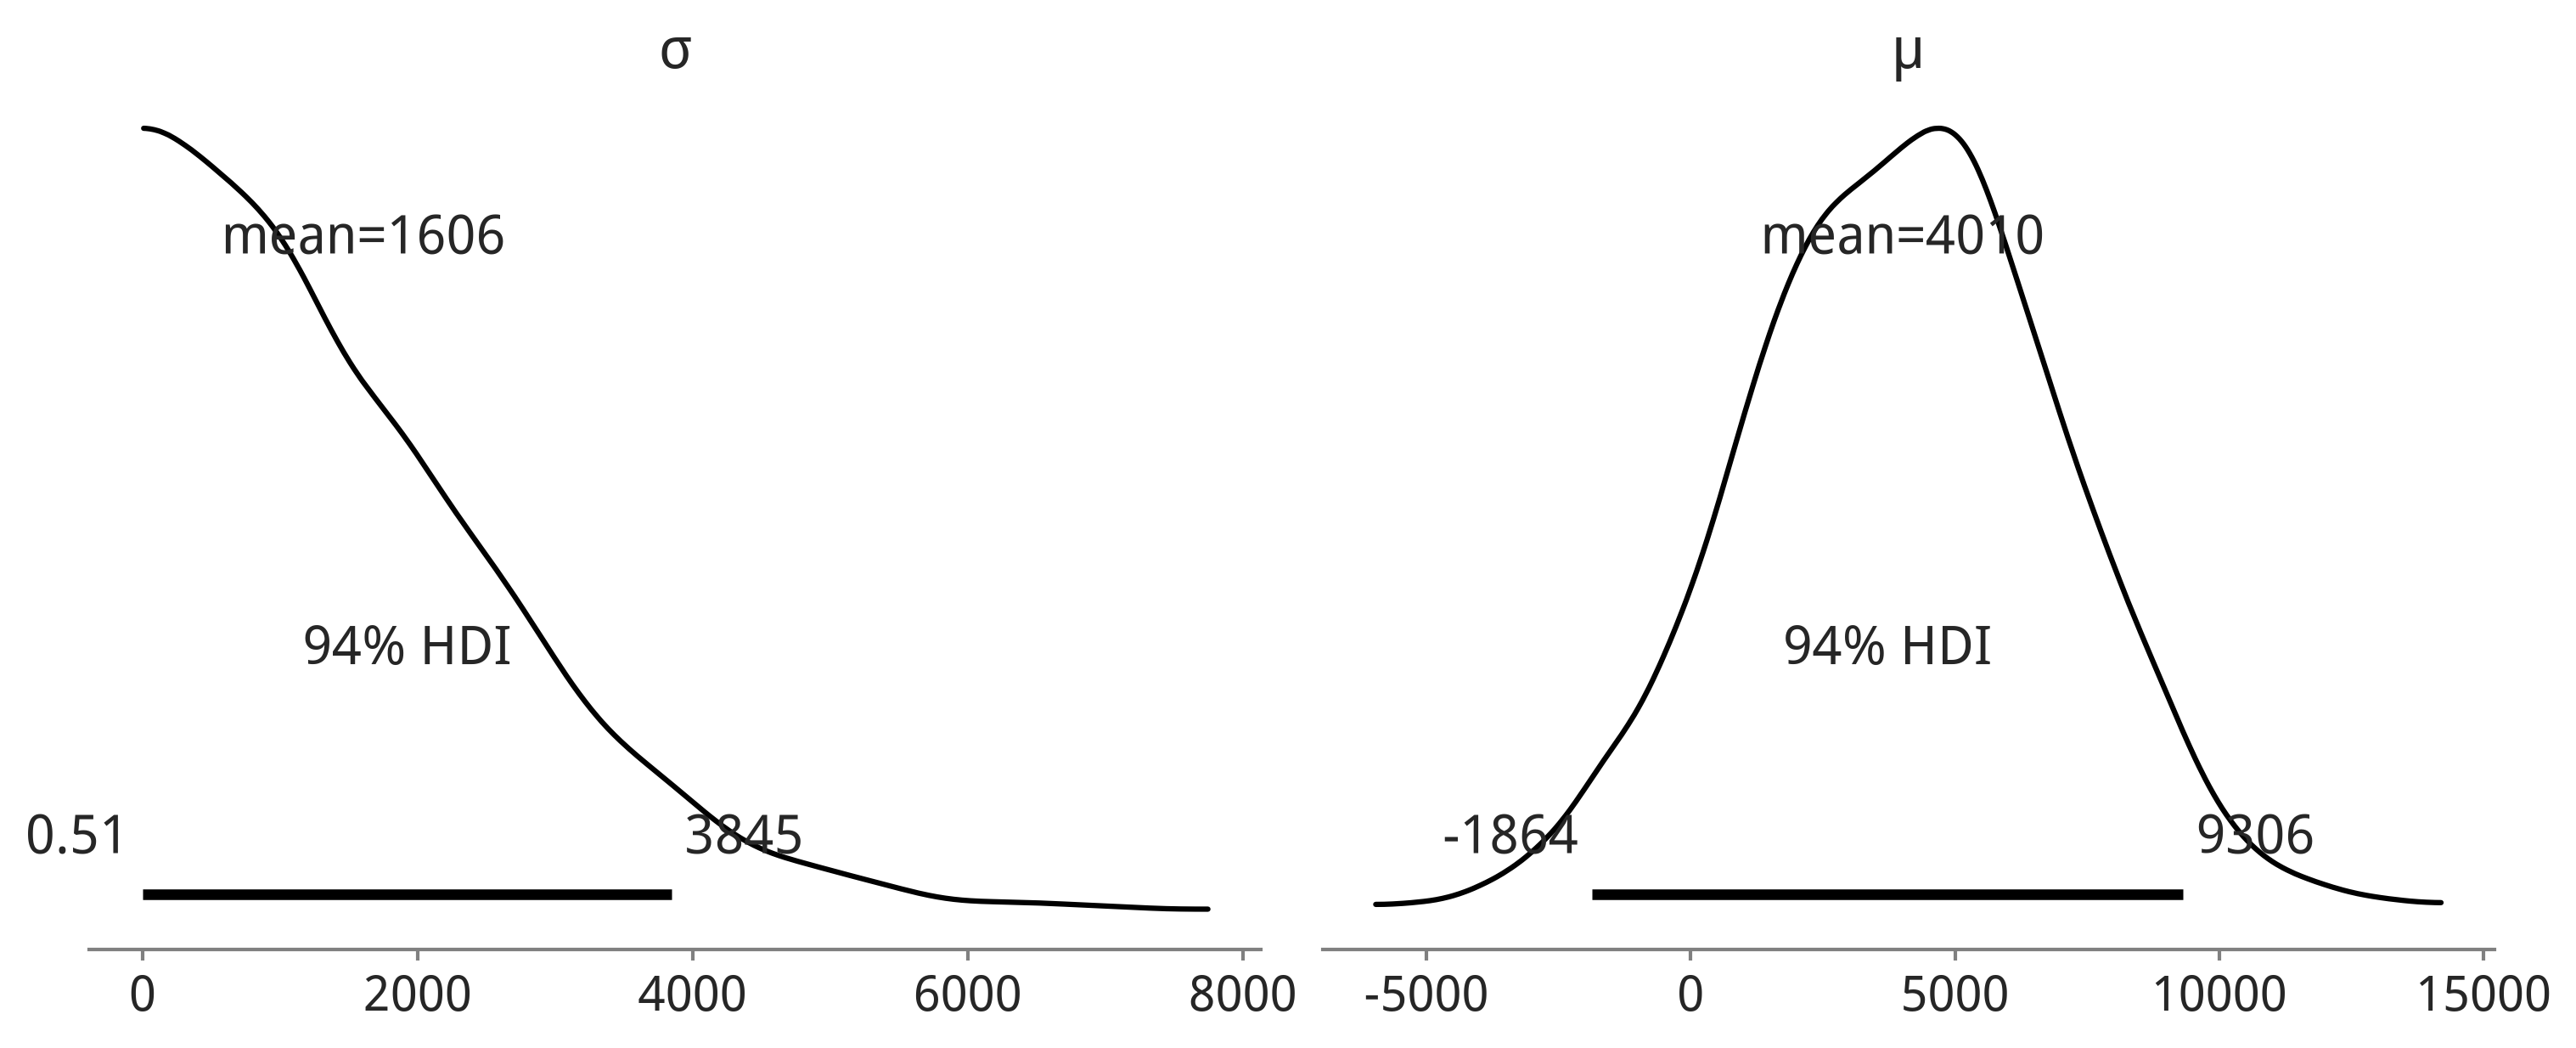

In [7]:
axes = az.plot_posterior(idata_adelie_mass.prior, var_names=["σ", "μ"], figsize=(10, 4))

**图 3.1（锚点 `fig:SingleSpecies_Prior_Predictive`）** 单物种体重模型中 $\mu$ 与 $\sigma$ 的先验样本。两个先验都覆盖很宽的范围,也暴露出负均值等值得进一步检查的取值。

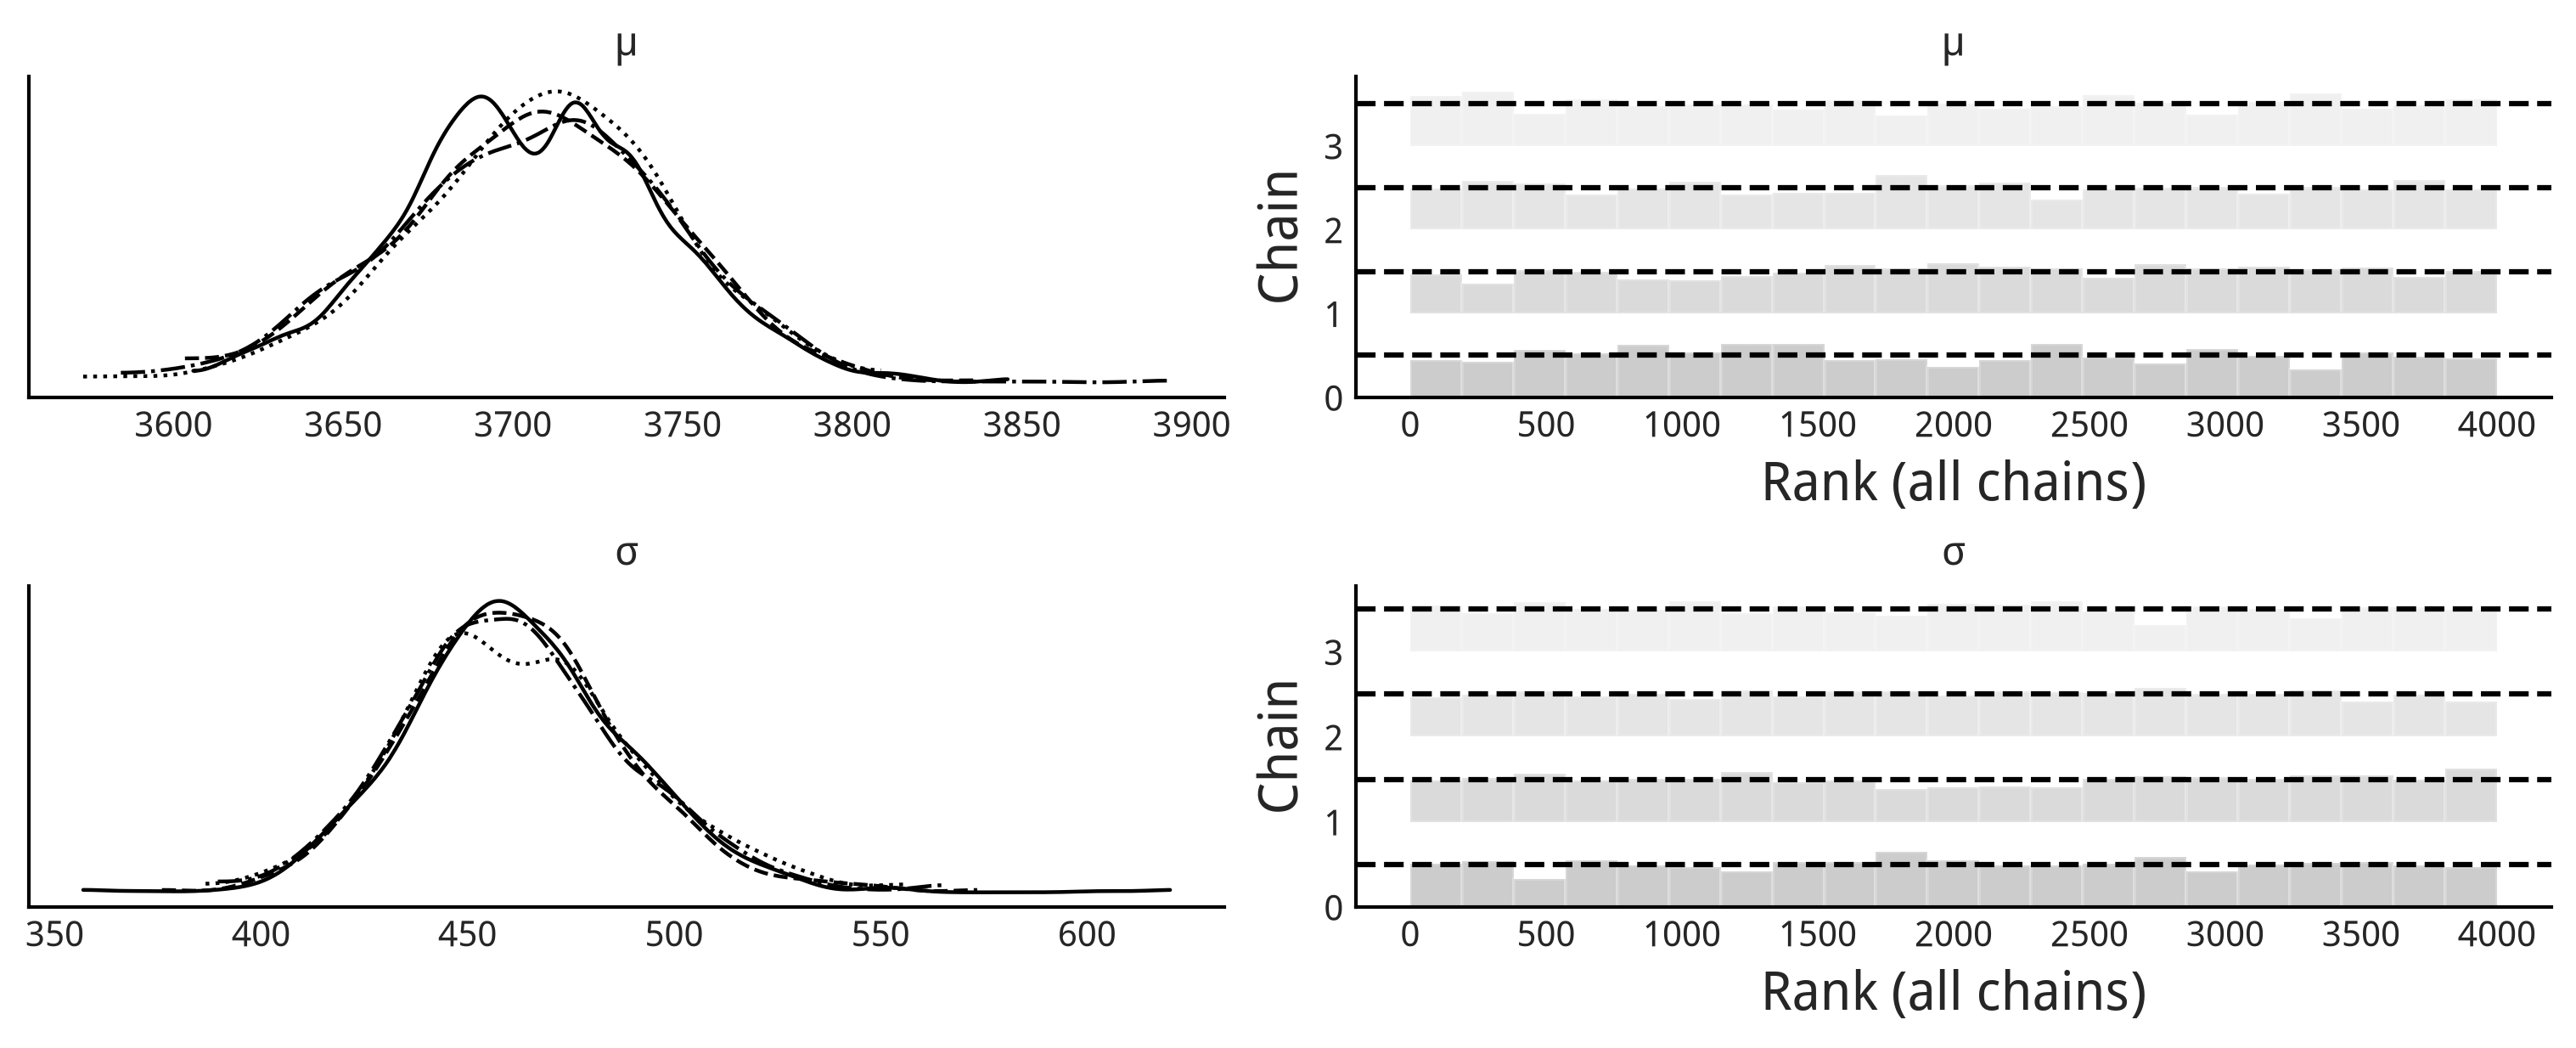

In [8]:
axes = az.plot_trace(idata_adelie_mass, divergences="bottom", kind="rank_bars", figsize=(10, 4))

**图 3.2（锚点 `fig:single_penguins_rank_kde_plot`）** Adelie 体重模型参数的 KDE 与秩图,用于检查多条链的混合与采样稳定性。

In [9]:
az.summary(idata_adelie_mass)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ,3706.977,39.003,3631.936,3777.080,0.615,0.630,4044.0,2776.0,1.0
σ,462.020,27.089,414.919,515.353,0.428,0.529,4105.0,2825.0,1.0


**表 3.2（锚点 `tab:penguin_mass_parameters_bayesian_estimates`）** Adelie 体重模型的贝叶斯参数估计与采样诊断。

拟合结果令人满意后,我们把所有链合并画一张后验图,并与前面的经验均值/标准差点估计对照来看
(下图中的竖直虚线就是经验均值和标准差)。

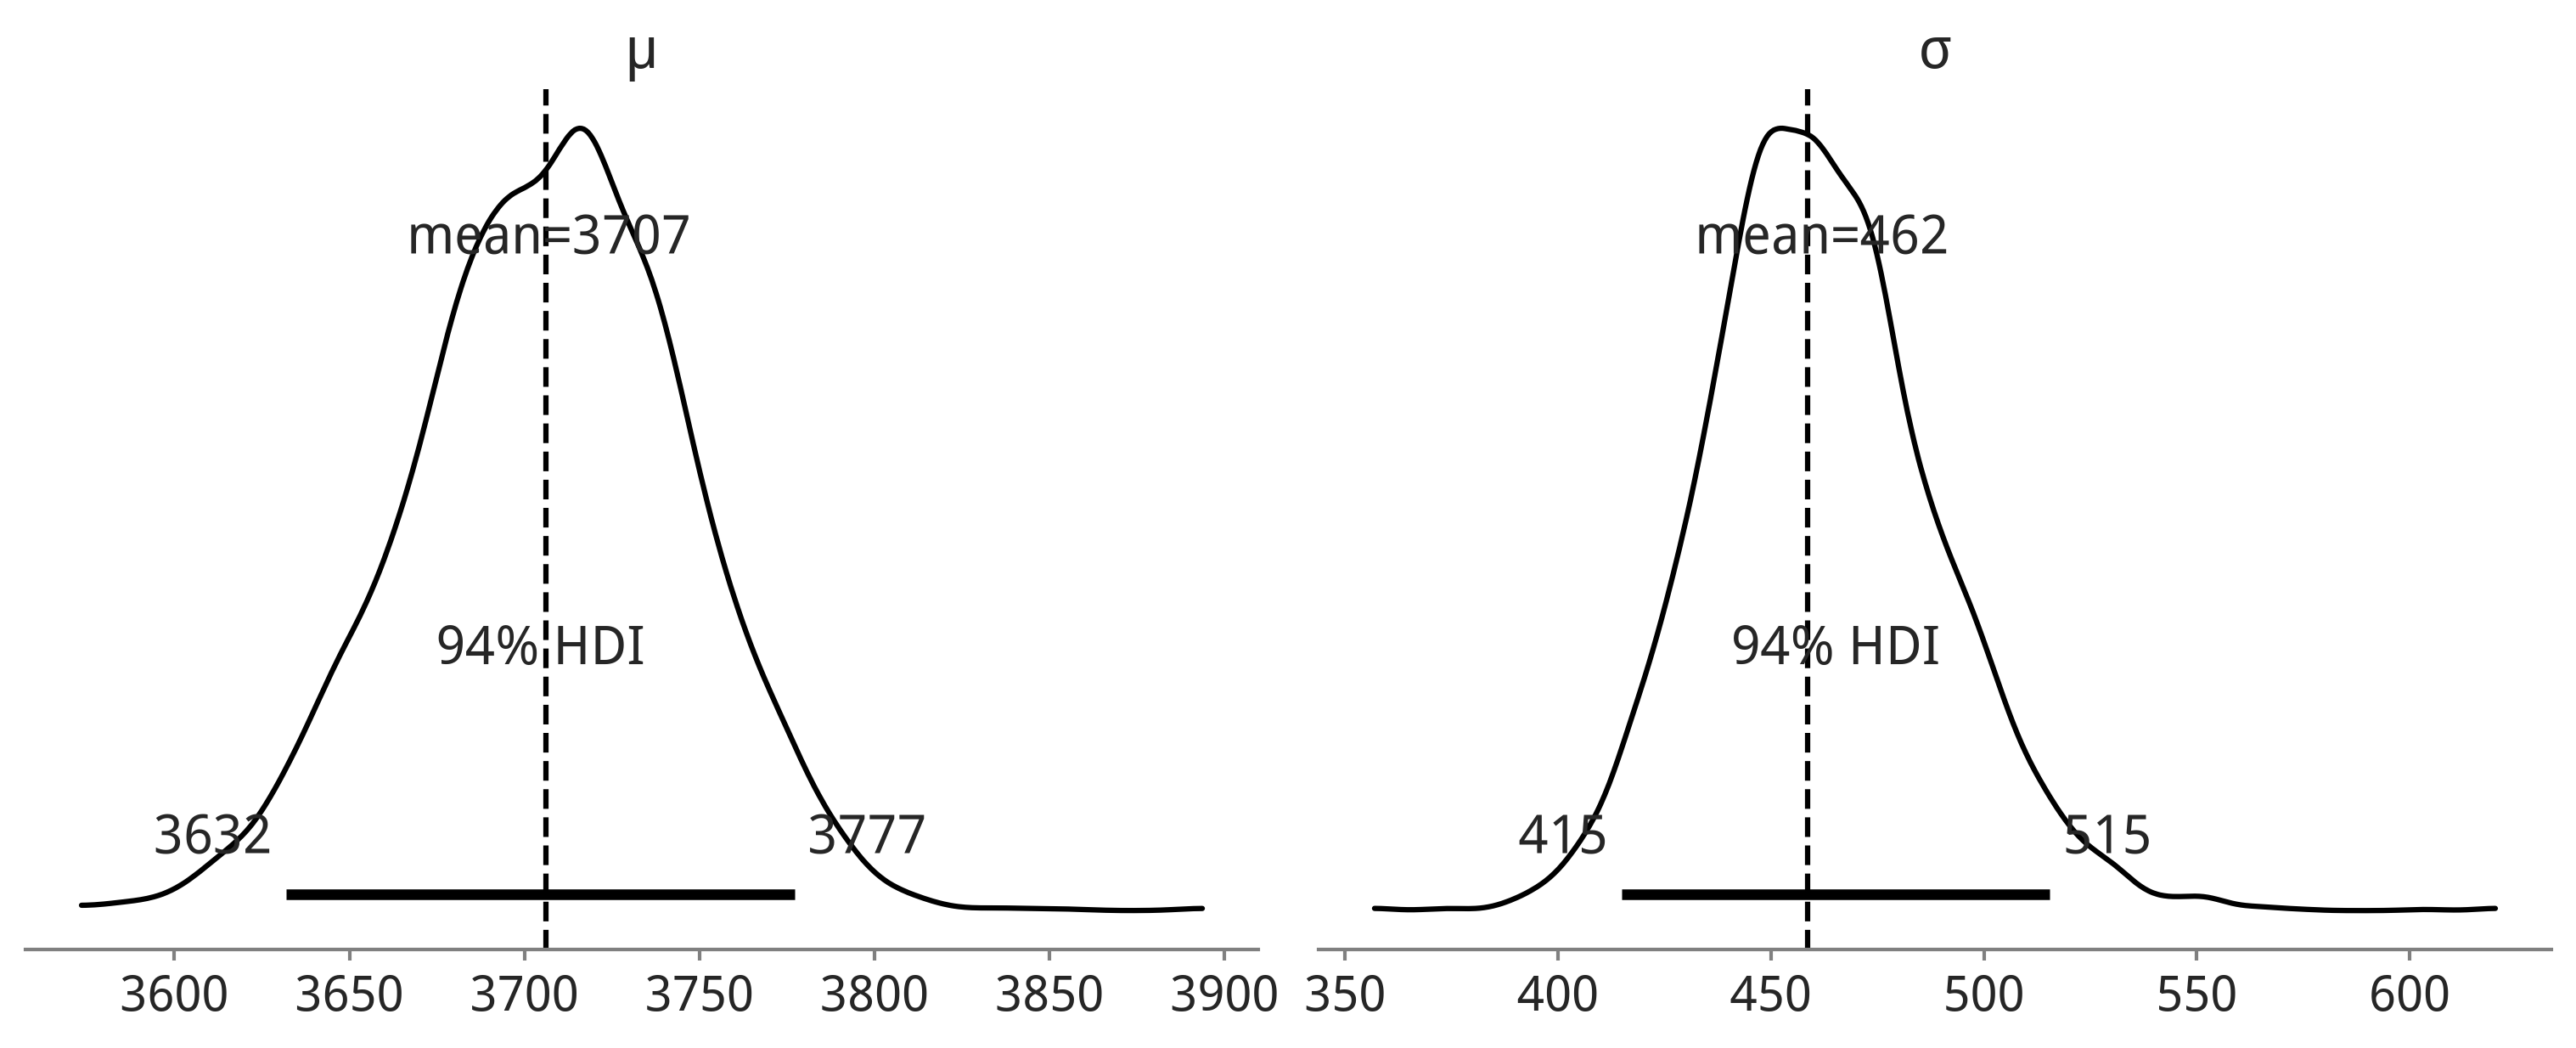

In [10]:
axes = az.plot_posterior(idata_adelie_mass, hdi_prob=.94, figsize=(10, 4));

# 竖线使用数据直接计算的经验统计量,避免写死某次输出。
axes[0].axvline(adelie_mass_obs.mean(), linestyle="--")
axes[1].axvline(adelie_mass_obs.std(ddof=1), linestyle="--")

**图 3.3（锚点 `fig:SingleSpecies_Mass_PosteriorPlot`）** Adelie 体重分布参数的后验;虚线是直接从观测计算的经验均值与样本标准差。

用贝叶斯方法估计,我们得到的不只是一个点,而是一整个“合理参数”的分布。均值与标准差的具体
点估计、MCSE 和 HDI 应从本次 `az.summary` 输出读取;不同随机种子和抽样预算会让末位数字略有
变化,因此正文不固定抄写某一次运行的区间。还要
记住:这个后验分布并不是"某一只企鹅体重"的分布,而是我们假设描述企鹅体重的那个高斯分布,其
参数的可能取值分布。如果想要单只企鹅体重的估计分布,需要生成后验预测分布——在这个例子中,
那会是以 $\mu$、$\sigma$ 的后验为条件的、同一个高斯分布。

搞清楚了 Adelie 企鹅的体重之后,我们可以用同样的方法处理另外两个物种。当然可以再写两个模型,
但更简便的做法是:直接写一个模型,同时处理 3 个分组(每个物种一组)。

In [11]:
# pd.Categorical 能让我们方便地在下面按物种做索引
all_species = pd.Categorical(penguins["species"])
coords = {"species": all_species.categories}

with pm.Model(coords=coords) as model_penguin_mass_all_species:
    # dims 使用 coords 中的语义坐标确定长度,让每个物种都拥有各自独立的 σ、μ。
    # shape=3 也能得到三个参数,但不会保留“species”这一维的名称与标签。
    # 中文版现代化说明：同前，用 lam = 1 / sigma**2 规避
    # pm.HalfStudentT(sigma=...) 在较大 sigma 下的数值错误。
    σ = pm.HalfStudentT("σ", nu=100, lam=1 / 2000**2, dims="species")
    μ = pm.Normal("μ", 4000, 3000, dims="species")
    mass = pm.Normal("mass",
                     mu=μ[all_species.codes],
                     sigma=σ[all_species.codes],
                     observed=penguins["body_mass_g"])

    idata_penguin_mass_all_species = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [σ, μ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 198 seconds.


我们利用了每个参数上可选的 `dims` 参数,并在似然里加上索引,告诉 PyMC 我们希望针对每个物种
分别估计后验。`dims` 并不是简单地“取代 `shape`”:它把数组轴连接到具名坐标,使后验结果保留
`species` 维及其类别标签;`shape` 只规定数组大小。在编程语言设计中,这种让表达想法更顺手的小技巧
被称为**语法糖(syntactic sugar)**,概率编程语言的开发者们同样也提供了不少这样的语法糖——
概率编程语言致力于让表达模型更轻松、更不容易出错。

拟合之后我们再检查一下 KDE 和秩图。和只有 Adelie 一个物种时的图相比,现在多出了 4 个子图
(对应新增的两组参数)。可以花点时间,把每个物种的均值估计与前面各物种的经验均值对照一下。
为了更方便比较各物种之间分布的差异,我们再用森林图(forest plot)把后验画一遍,可以更清楚
地看出巴布亚(Gentoo)企鹅的体重似乎比阿德利(Adelie)或帽带(Chinstrap)企鹅更重。

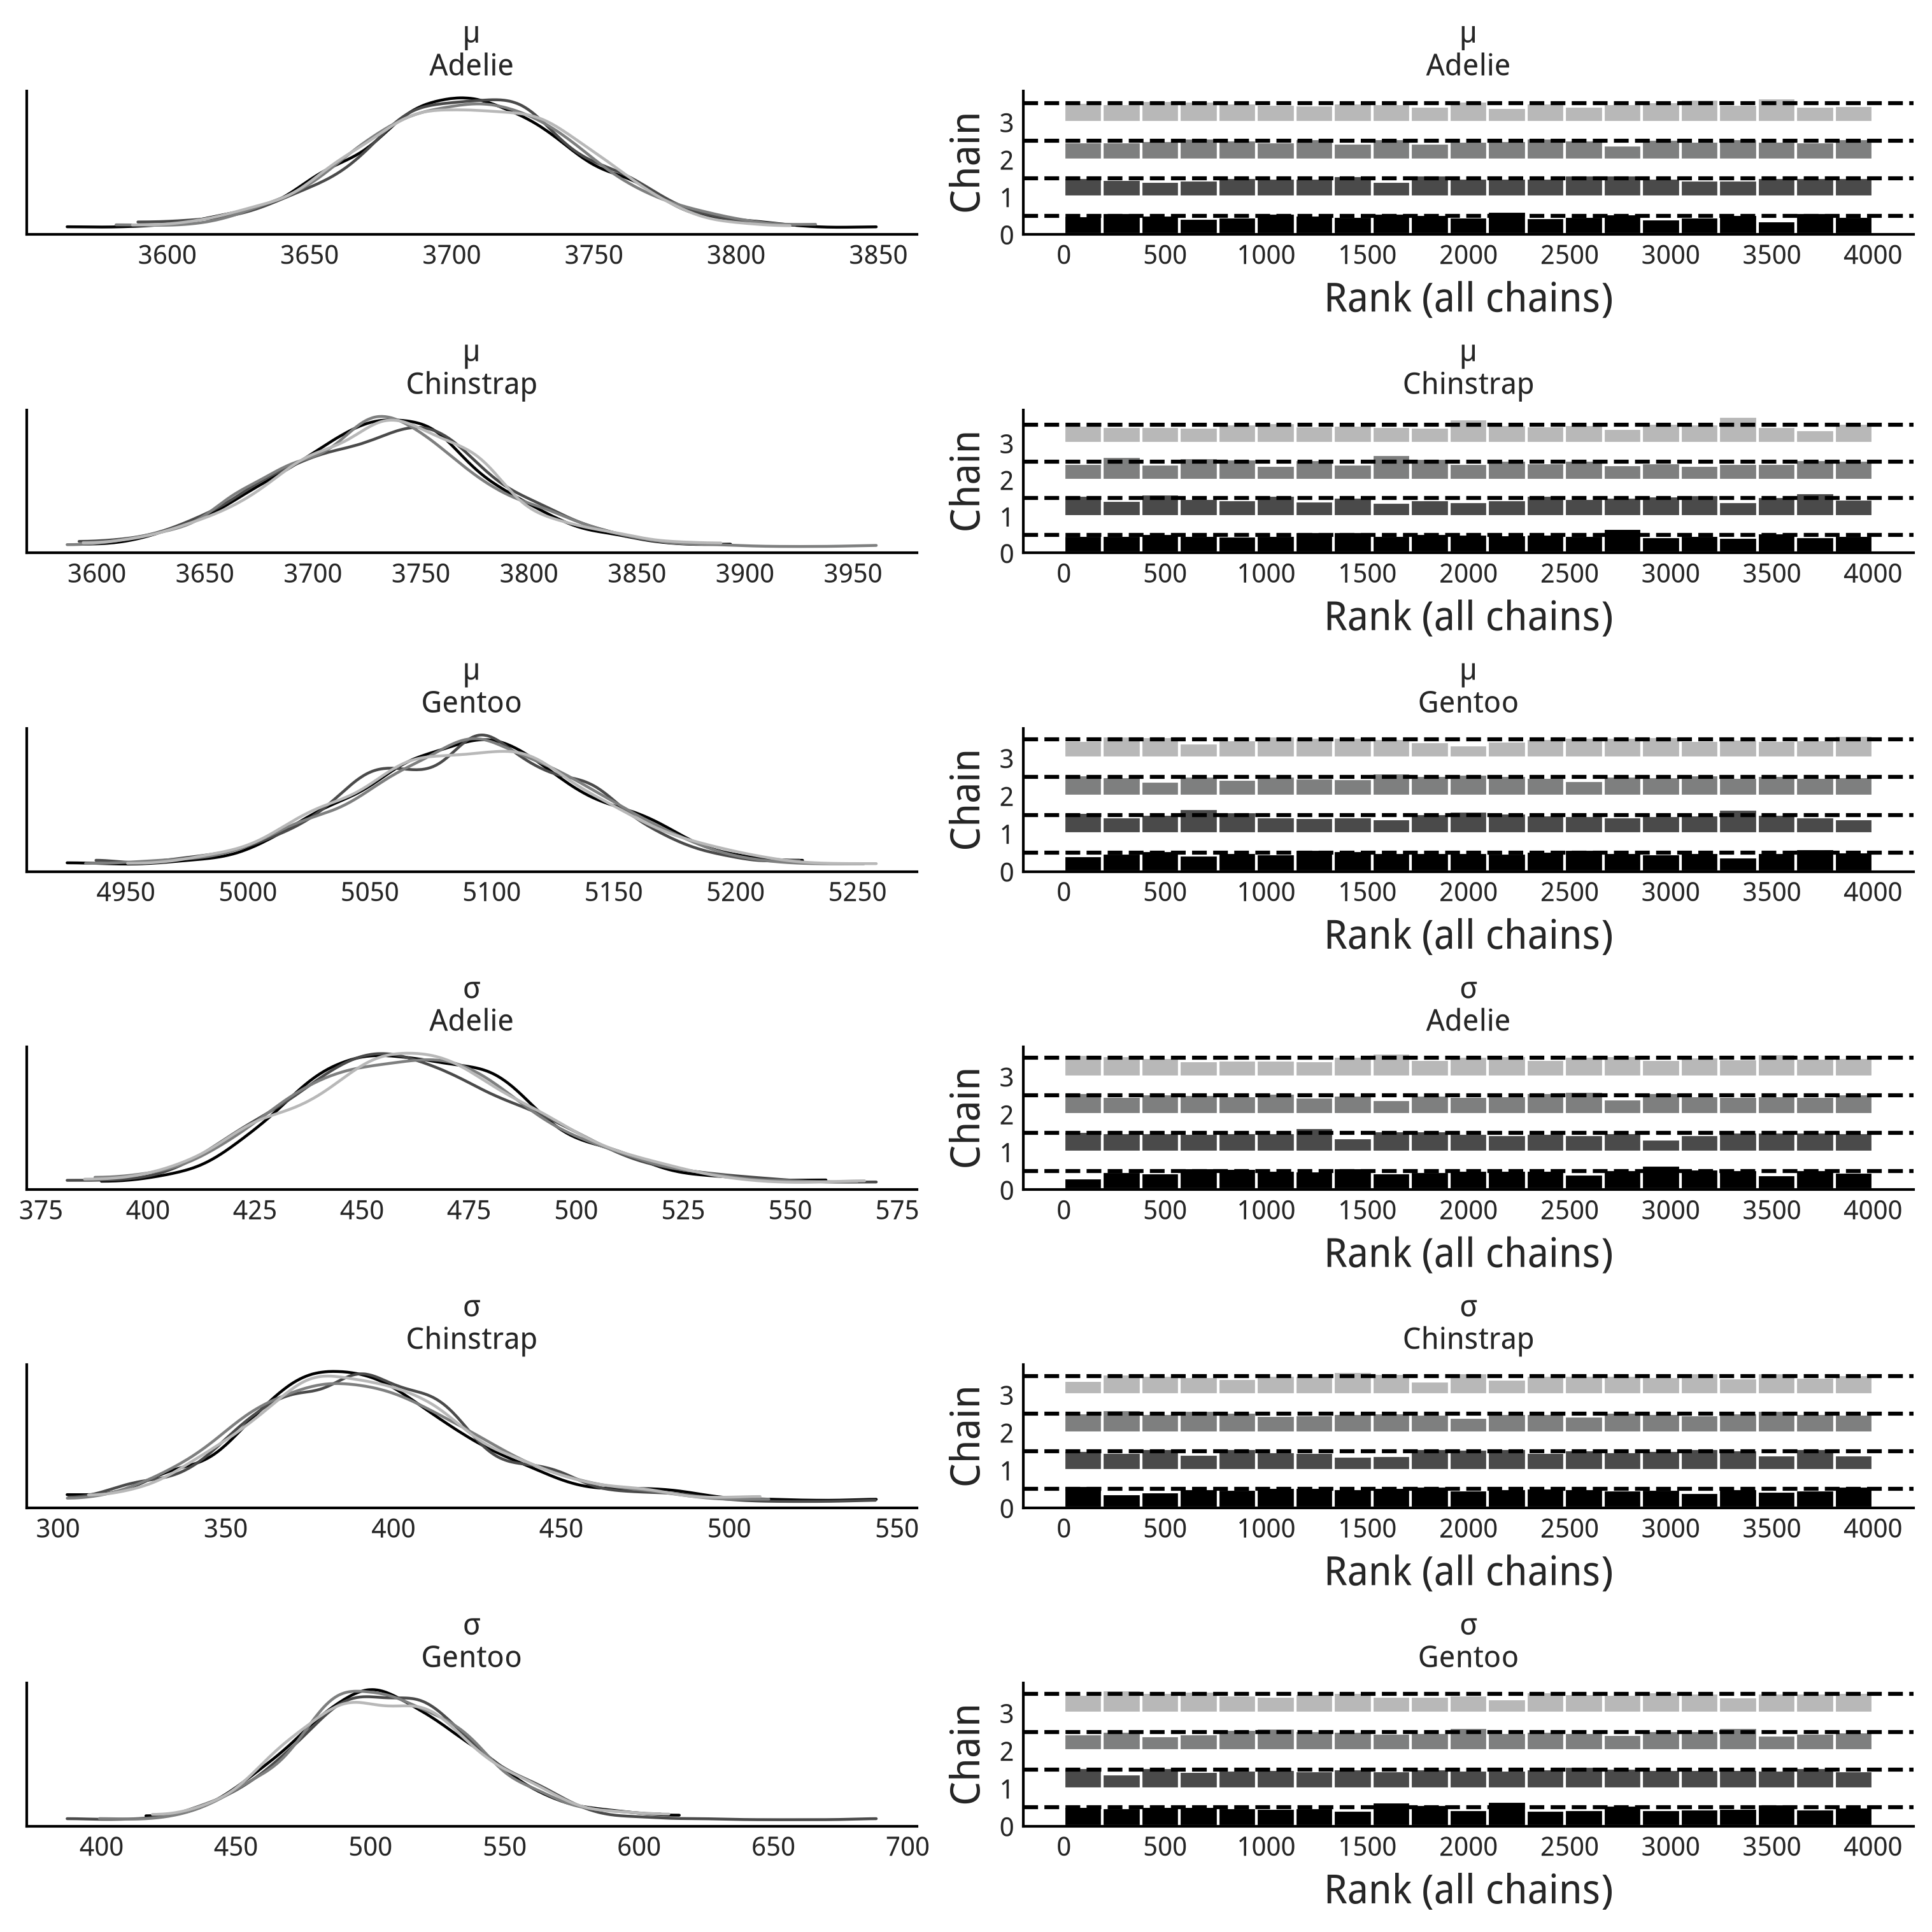

In [12]:
axes = az.plot_trace(idata_penguin_mass_all_species, compact=False,
                     divergences="bottom", kind="rank_bars", figsize=(10, 10));

**图 3.4（锚点 `fig:all_penguins_rank_kde_plot`）** 三个企鹅物种各自体重参数的 KDE 与秩图;每个物种都有独立的 $\mu$ 与 $\sigma$。

Text(0.5, 1.0, '各物种平均体重 μ：94% HDI')

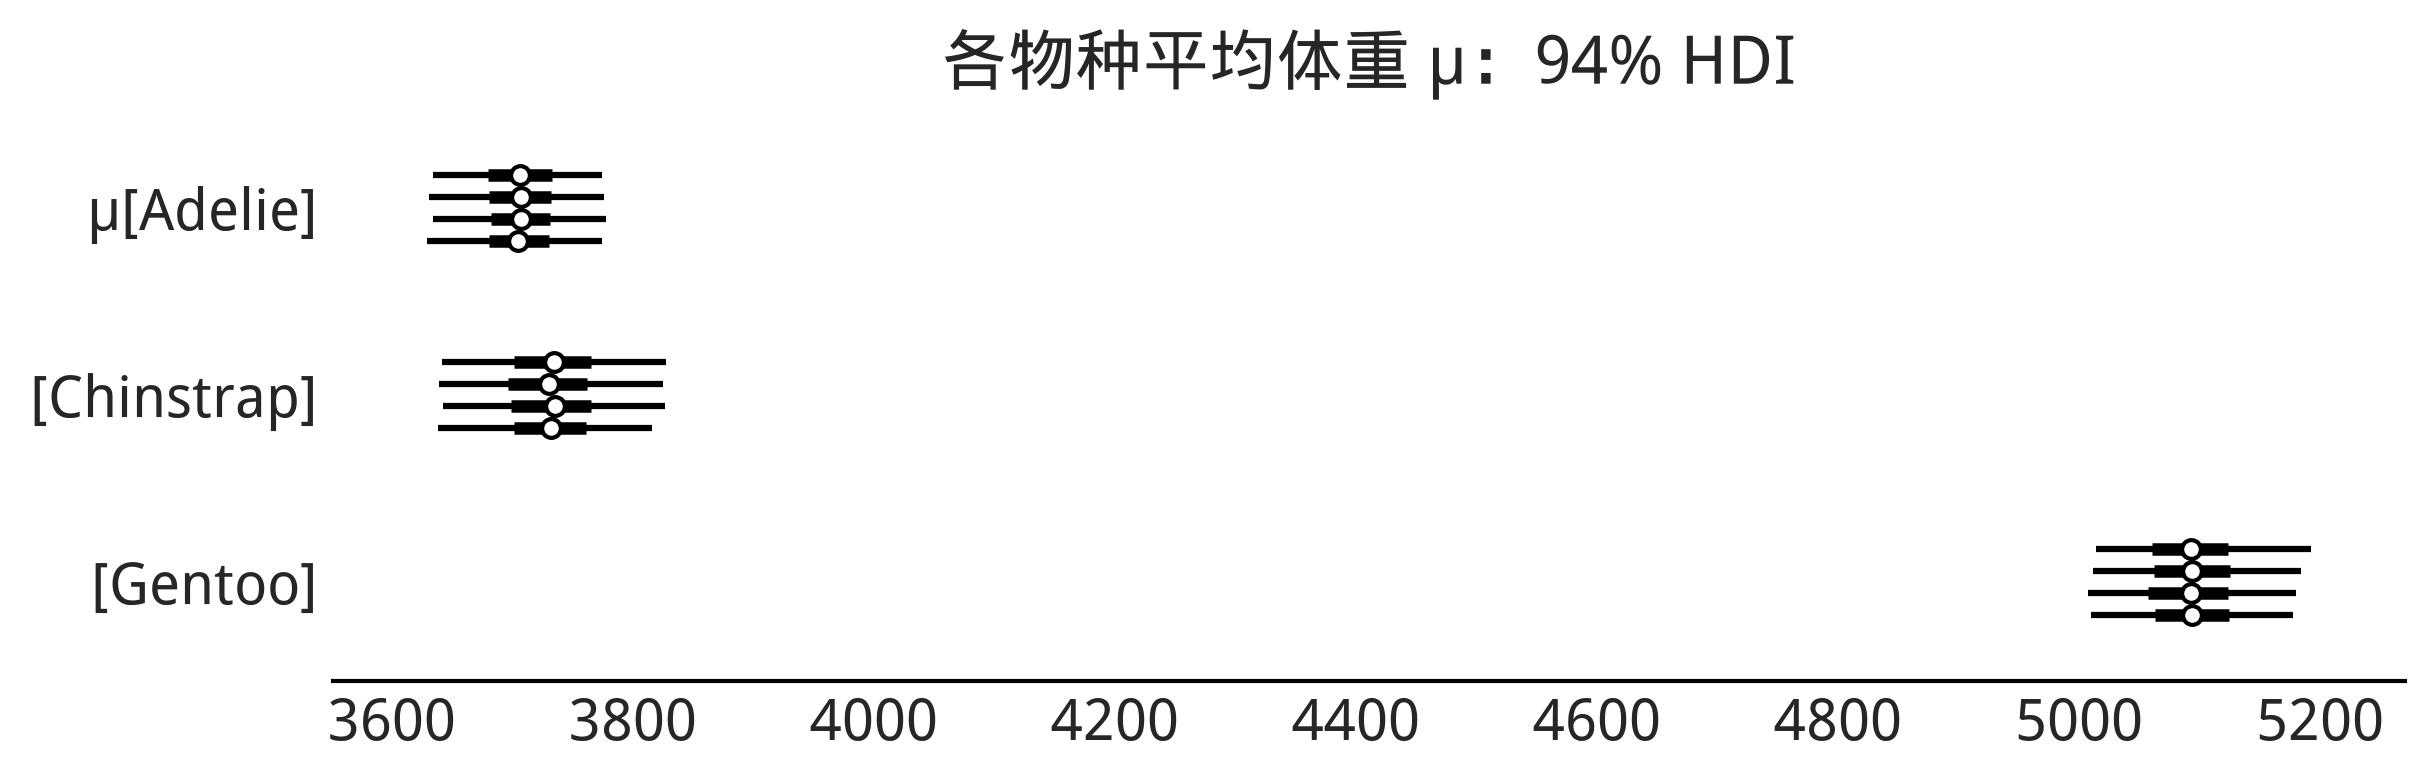

In [13]:
axes = az.plot_forest(idata_penguin_mass_all_species, var_names=["μ"], figsize=(8, 2.5))
axes[0].set_title("各物种平均体重 μ：94% HDI")

**图 3.5（锚点 `fig:forest_plot_means`）** 三个物种平均体重 $\mu$ 的森林图,展示后验中心与 94% HDI。

再来看看标准差的森林图。后验的 94% 最高密度区间显示,不确定性大致在 100 克这个量级。

Text(0.5, 1.0, '各物种体重标准差 σ：94% HDI')

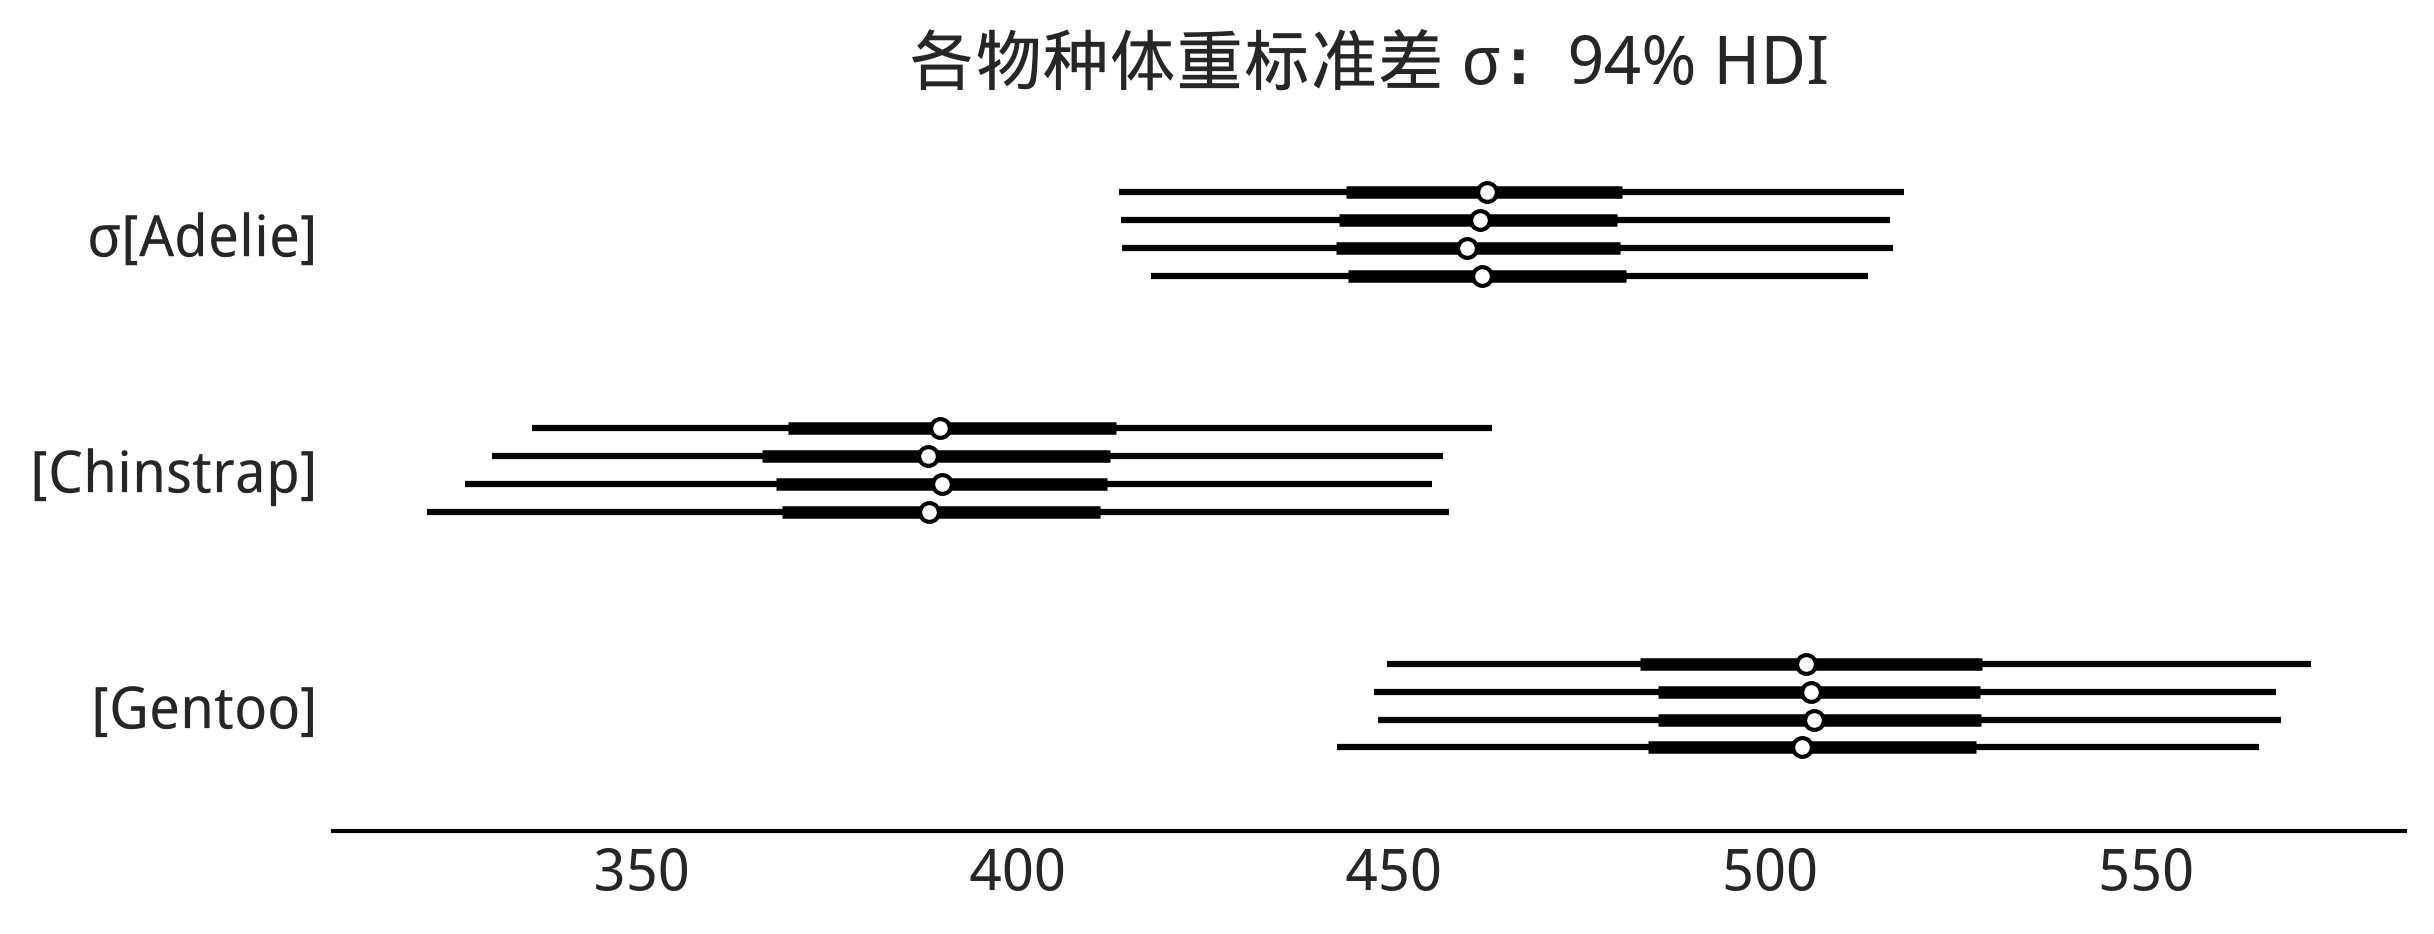

In [14]:
axes = az.plot_forest(idata_penguin_mass_all_species, var_names=["σ"], figsize=(8, 3));
axes[0].set_title("各物种体重标准差 σ：94% HDI")

**图 3.6（锚点 `fig:forest_plot_sigma`）** 三个物种体重标准差 $\sigma$ 的森林图,用于比较组内离散程度。

### 比较两种 PPL

在继续深入统计与建模思想之前,我们先花点时间聊聊概率编程语言本身,并介绍本书会用到的另一种
PPL——TensorFlow Probability(TFP)。我们会把上面刚写好的、只有截距的 PyMC 模型,翻译成
TFP 版本。

你可能会觉得"没必要学好几种 PPL 吧",但本书选择用两种(而不是一种)PPL,是有具体原因的。
用不同 PPL 实现同一套工作流,能让你对计算贝叶斯建模的理解更全面,帮助你把"计算细节"和
"统计思想"区分开来,让你成为更强的建模者。此外,不同 PPL 各有侧重和优势:PyMC 是更高层的
PPL,用更少的代码就能表达模型;而 TFP 提供的是更底层、可组合的建模与推断原语。还有一点是,
并非所有 PPL 都能同样轻松地表达所有模型——比如时间序列模型(第 6 章)用 TFP 表达更顺手,而
贝叶斯加法回归树(第 7 章)用 PyMC 表达更顺手。通过接触多种语言,你会对贝叶斯建模的基本要素
及其计算实现都有更扎实的理解。

概率编程语言(重点是"语言"二字)由一系列**原语(primitives)**组成。编程语言中的原语,是
用来构建更复杂程序的最基本元素——可以把原语类比成自然语言里的单词,能组合成更复杂的结构
(比如句子)。就像不同的自然语言用不同的单词一样,不同的 PPL 也使用不同的原语,主要用来表达
模型、执行推断,或完成工作流的其他部分。在 PyMC 中,与建模相关的原语都在 `pm.` 命名空间下,
比如上面模型里的 `pm.HalfStudentT(.)`、`pm.Normal(.)`,它们代表随机变量。`with pm.Model()
as .` 语句会启用一个 Python 上下文管理器,PyMC 借助它收集上下文管理器内部的随机变量,构建出
模型。随后我们分别用 `pm.sample_prior_predictive(.)` 和 `pm.sample(.)`,从先验预测分布和
后验分布中获得样本。

类似地,TFP 也在 `tfp.distributions` 中提供了指定分布和模型的原语,在 `tfp.mcmc` 中提供了
运行 MCMC 的原语,等等。比如,要搭建一个贝叶斯模型,TensorFlow 在 `tfd.JointDistribution`
这一 API 下提供了多种原语 {cite:p}`piponi2020joint`。本章及全书后续大多使用
`tfd.JointDistributionCoroutine`,不过
`tfd.JointDistribution` 还有其他变体,可能更适合你的具体场景 [^1]。由于基础的数据加载和
汇总统计和前面完全一样,我们可以把注意力集中在建模和推断本身。下面是用 TFP 表达的、和前面
`model_penguin_mass_all_species` 完全等价的模型:

In [15]:
import tensorflow as tf
import tensorflow_probability as tfp

tfd = tfp.distributions
root = tfd.JointDistributionCoroutine.Root

species_idx = tf.constant(all_species.codes, tf.int32)
body_mass_g = tf.constant(penguins["body_mass_g"], tf.float32)

@tfd.JointDistributionCoroutine
def jd_penguin_mass_all_species():
    σ = yield root(tfd.Sample(
            tfd.HalfStudentT(df=100, loc=0, scale=2000),
            sample_shape=3,
            name="sigma"))
    μ = yield root(tfd.Sample(
            tfd.Normal(loc=4000, scale=3000),
            sample_shape=3,
            name="mu"))
    mass = yield tfd.Independent(
        tfd.Normal(loc=tf.gather(μ, species_idx, axis=-1),
                   scale=tf.gather(σ, species_idx, axis=-1)),
        reinterpreted_batch_ndims=1,
        name="mass")

I0000 00:00:1787474534.504684 2624812 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787474538.750631 2624812 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787474546.338263 2624812 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1787474549.160688 2624812 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


既然这是我们第一次接触用 TFP 写的贝叶斯模型,不妨多花几段篇幅讲讲这套 API。TFP 的原语是
`tfp.distributions` 里的分布类,我们给它取了个更短的别名 `tfd = tfp.distributions`。`tfd`
包含了常用分布,比如 `tfd.Normal(.)`。我们还用到了 `tfd.Sample`,它会返回基础分布的多个
独立副本(概念上类似于 PyMC 里 `shape=(.)` 这个语法糖起到的作用)。`tfd.Independent` 用来
表明:这个分布包含多个副本,我们希望在计算对数似然时对某个轴求和,具体是哪个轴由
`reinterpreted_batch_ndims` 参数指定。通常我们会用 `tfd.Independent` 包裹与观测值相关的
分布 [^2]。

`tfd.JointDistributionCoroutine` 模型有一个有意思的特征——顾名思义,就是用到了 Python 里的
协程(coroutine)。不深入讲生成器和协程的细节,这里你只需要知道:对一个分布使用 `yield`
语句,会在模型函数内部给你一个随机变量。可以把 `y = yield Normal(.)` 理解为在表达
$y \sim \text{Normal(.)}$。此外,我们需要用 `tfd.JointDistributionCoroutine.Root` 把没有
依赖关系的随机变量包裹起来,标记为"根节点"。整个模型被写成一个不接受输入参数、也没有返回值
的 Python 函数。最后,把 `@tfd.JointDistributionCoroutine` 作为装饰器加在函数上面,就能
直接得到模型对象(也就是一个 `tfd.JointDistribution`)。

得到的 `jd_penguin_mass_all_species`,就是前面那个"只有截距"回归模型的 TFP 版本。它和其他
`tfd.Distribution` 一样拥有类似的方法,可以在贝叶斯工作流中使用。比如要抽取先验和先验预测
样本,可以调用 `.sample(.)` 方法,它会返回一个类似 `namedtuple` 的自定义嵌套 Python 结构。
下面这行代码按当前执行配置抽取 `PRIOR_SAMPLES` 个先验及先验预测样本:smoke 配置用于快速
验证,release 配置使用更充分的预算。

In [16]:
prior_predictive_samples = jd_penguin_mass_all_species.sample(PRIOR_SAMPLES, seed=RANDOM_SEED)

`tfd.JointDistribution` 的 `.sample(.)` 方法也可以抽取条件样本,这正是我们后面用来抽取后验
预测样本的机制。你可以运行下面这段代码,观察当我们把模型中某些随机变量条件化为特定值时,随机
样本会如何变化。总的来说,调用 `.sample(.)` 时,我们启动的是模型的*正向*生成过程。

In [17]:
jd_penguin_mass_all_species.sample(
    sigma=tf.constant([.1, .2, .3]),
    seed=tf.constant([RANDOM_SEED, 10], tf.int32),
)
jd_penguin_mass_all_species.sample(
    mu=tf.constant([.1, .2, .3]),
    seed=tf.constant([RANDOM_SEED, 11], tf.int32),
);

一旦我们把生成模型 `jd_penguin_mass_all_species` 条件化到观测到的企鹅体重上,就能得到后验
分布。从计算的角度看,我们希望构造一个函数,在给定输入时返回后验对数概率(不计常数项)。这
可以通过创建一个 Python 函数闭包,或者使用 `.experimental_pin` 方法来实现:

In [18]:
target_density_function = lambda *x: jd_penguin_mass_all_species.log_prob(*x, mass=body_mass_g)

jd_penguin_mass_observed = jd_penguin_mass_all_species.experimental_pin(mass=body_mass_g)
target_density_function = jd_penguin_mass_observed.unnormalized_log_prob

有了 `target_density_function`,就可以进行推断了——比如可以求这个函数的最大值,得到**最大
后验概率(MAP)估计**;也可以用 `tfp.mcmc` 里的方法从后验中采样 {cite:p}`lao2020tfpmcmc`。
或者更方便地,使用一套和 PyMC 里类似的标准采样流程 [^3],如下所示:

In [19]:
# `jit_compile=True` 会为不同形状的联合分布分别缓存大型 XLA 图;在同一章连续
# 拟合多个模型时可能造成不必要的内存峰值甚至杀死内核。这里使用普通 TensorFlow 图,
# 仍保留 `tf.function` 的追踪加速,但避免依赖 GPU/XLA。
run_mcmc = tf.function(
    tfp.experimental.mcmc.windowed_adaptive_nuts,
    autograph=False, jit_compile=False, reduce_retracing=True)
mcmc_samples, sampler_stats = run_mcmc(
    TFP_DRAWS,
    jd_penguin_mass_all_species,
    n_chains=CHAINS,
    num_adaptation_steps=TFP_ADAPT,
    seed=tf.constant([RANDOM_SEED, 1], tf.int32),
    mass=body_mass_g,
)

idata_penguin_mass_all_species2 = az.from_dict(
    posterior={
        # TFP 的 mcmc 结果形状是 (num_samples, num_chains, ...),
        # 我们交换第一、第二个轴,让形状符合 ArviZ 的预期
        k:np.swapaxes(v, 1, 0)
        for k, v in mcmc_samples._asdict().items()},
    sample_stats={
        k:np.swapaxes(sampler_stats[k], 1, 0)
        for k in ["target_log_prob", "diverging", "accept_ratio", "n_steps"]}
)

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


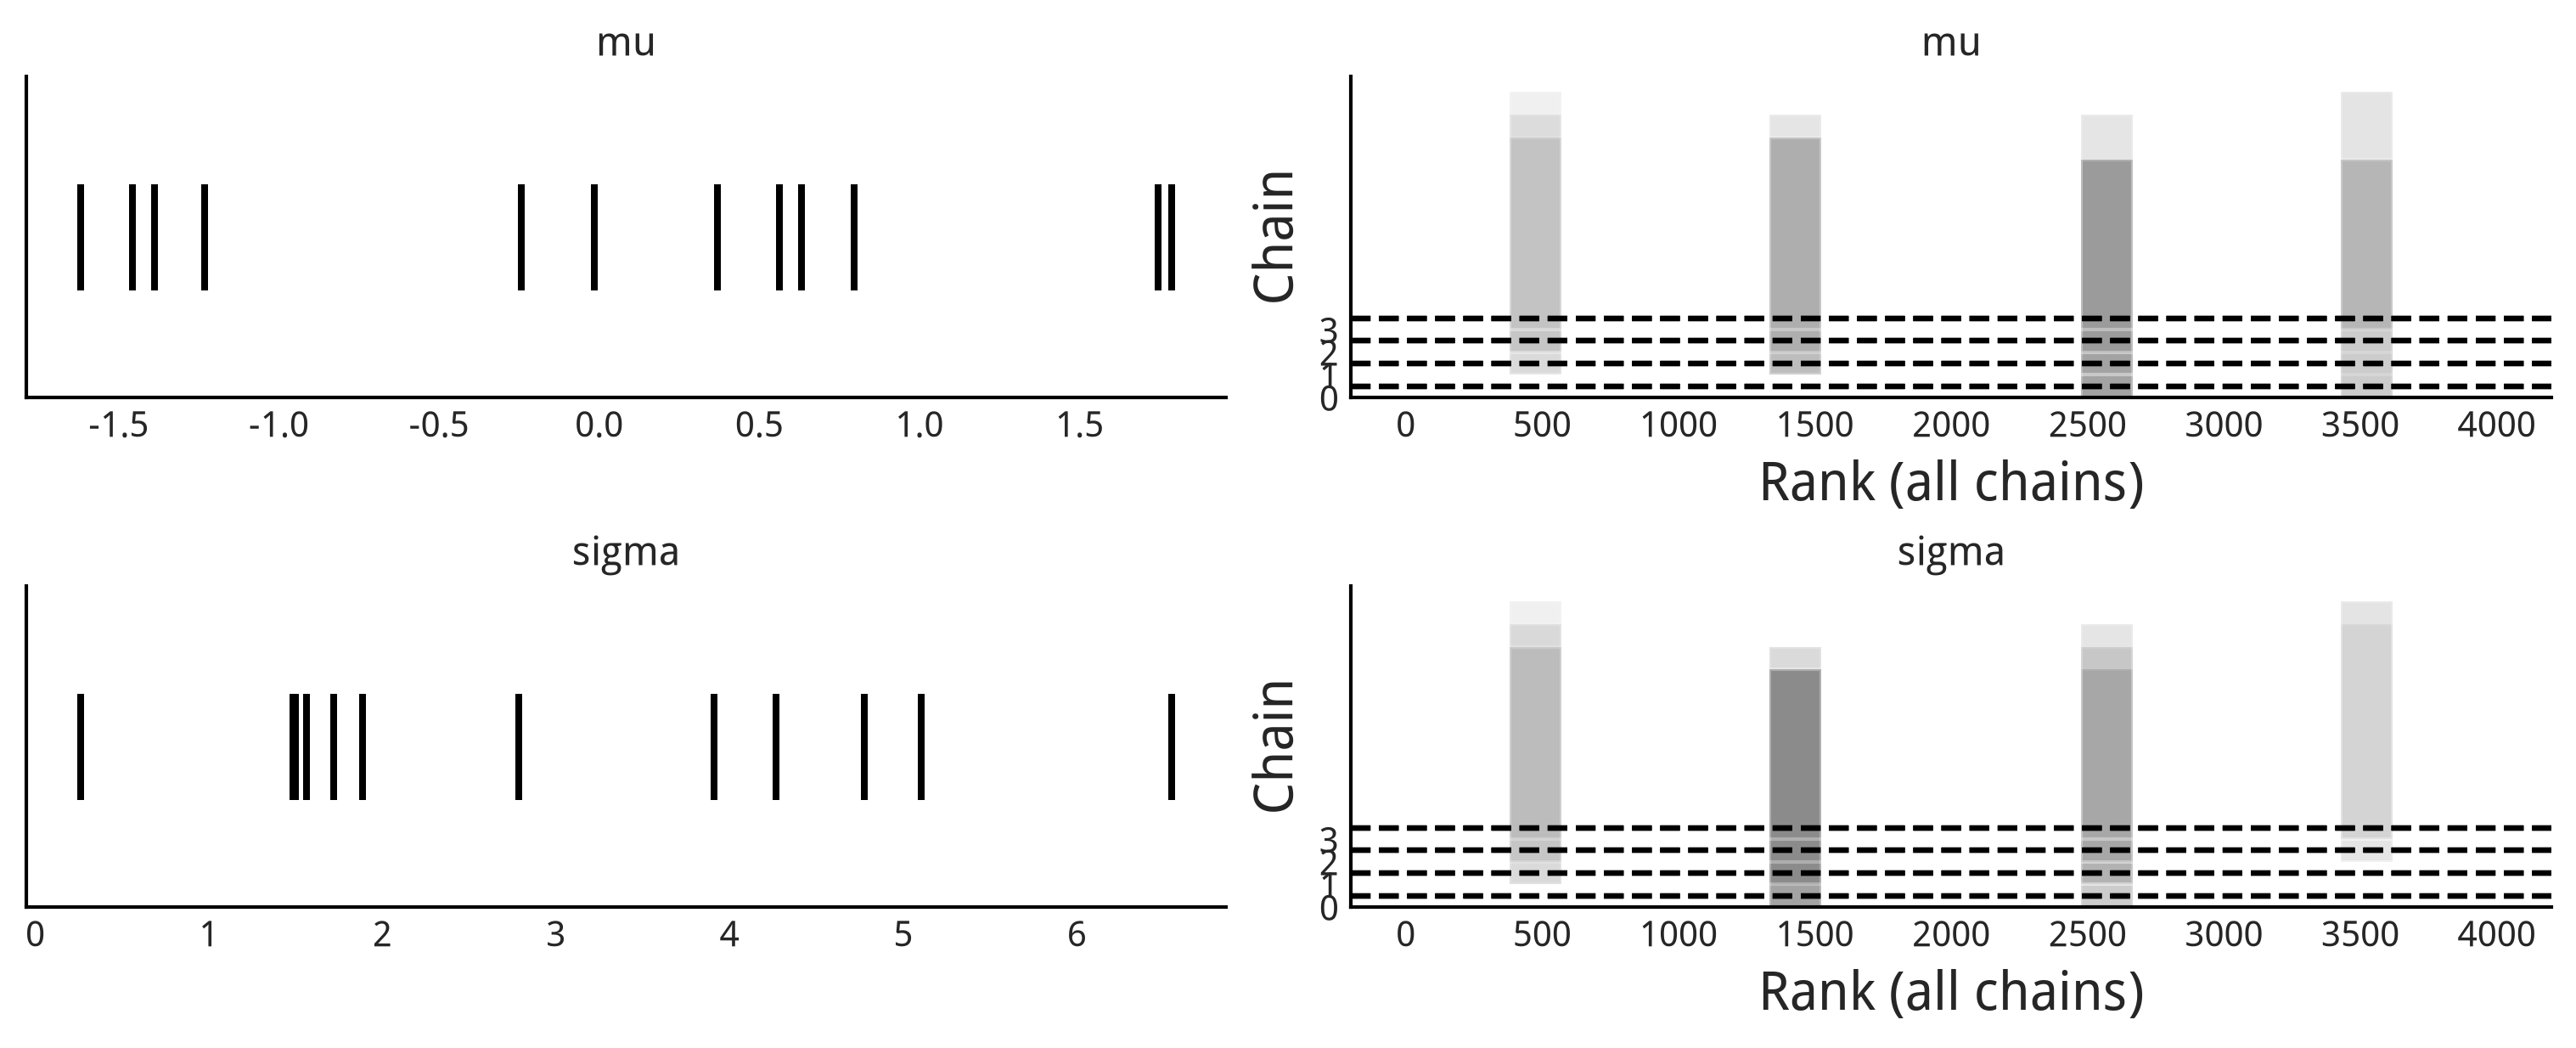

In [20]:
az.plot_trace(idata_penguin_mass_all_species2, divergences="bottom", kind="rank_bars", figsize=(10,4));

上面这段代码按当前配置运行 `CHAINS` 条 MCMC 链,每条链在 `TFP_ADAPT` 步适应
(adaptation)之后采集 `TFP_DRAWS` 个后验样本。smoke 配置仅用于检查代码路径,不能替代正式的
收敛诊断;release 配置才使用本章的完整预算。内部实现是通过 `experimental_pin` 方法,把观测值
(以关键字参数 `mass=body_mass_g` 的
形式)条件化进模型。随后代码把采样结果解析成 ArviZ 的 `InferenceData`,这样我们就可以用
ArviZ 来做诊断和探索性分析了。我们还可以进一步、以同样透明的方式,把先验样本、后验预测样本
和数据对数似然添加进 `idata_penguin_mass_all_species2`。注意这里用到了
`tfd.JointDistribution` 的 `sample_distributions` 方法,它既能抽样,又能生成一个以后验样本
为条件的分布对象。

In [21]:
prior_predictive_samples = jd_penguin_mass_all_species.sample(
    [1, PRIOR_SAMPLES], seed=RANDOM_SEED)
dist, samples = jd_penguin_mass_all_species.sample_distributions(
    value=mcmc_samples)
ppc_samples = samples[-1]
ppc_distribution = dist[-1].distribution
data_log_likelihood = ppc_distribution.log_prob(body_mass_g)

# 注意不要在同一个 REPL 会话里重复运行这段代码(add_groups 不能重复添加同名的组)
idata_penguin_mass_all_species2.add_groups(
    prior=prior_predictive_samples[:-1]._asdict(),
    prior_predictive={"mass": prior_predictive_samples[-1]},
    posterior_predictive={"mass": np.swapaxes(ppc_samples, 1, 0)},
    log_likelihood={"mass": np.swapaxes(data_log_likelihood, 1, 0)},
    observed_data={"mass": body_mass_g}
)

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1589: UserWarning: the default dims 'chain' and 'draw' will be added automatically
  warnings.warn(


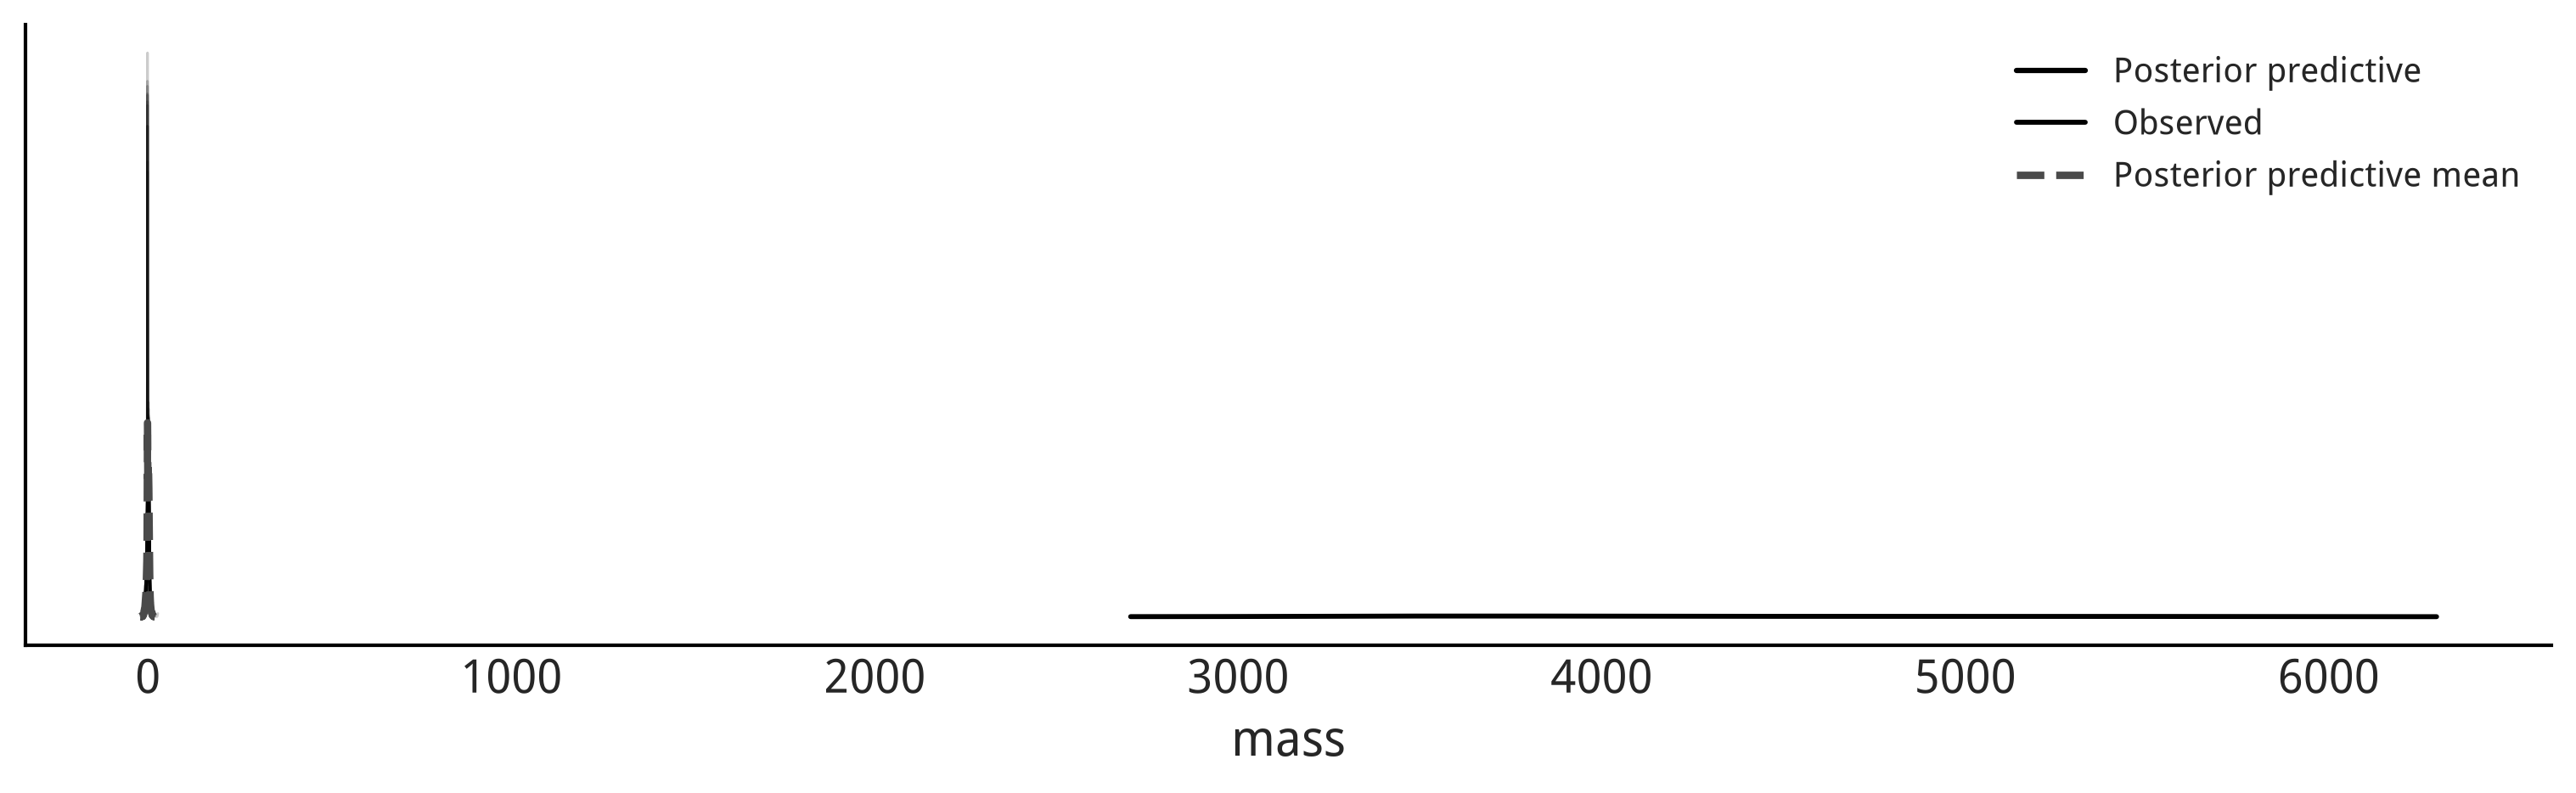

In [22]:
az.plot_ppc(idata_penguin_mass_all_species2, num_pp_samples=50, figsize=(10, 3));

In [23]:
az.loo(idata_penguin_mass_all_species2)

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 333 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -23580261424.38  1708426660.67
p_loo    23464516392.87        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)        0    0.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)  333  100.0%

`az.loo` 的结果只有在后验采样本身可靠时才值得解读。请先检查发散、$\hat R$ 和 ESS,再查看
LOO 输出中的 Pareto $k$ 诊断;若存在较大的 $k$ 值,重要性采样近似可能不稳定,应进一步检查对应
观测、改进模型,或使用更稳健的交叉验证方案。smoke 配置的短链只验证代码能运行,不能用于正式
模型比较。

到这里,我们就快速游览完了 TensorFlow Probability。和学习任何语言一样,第一次接触不太可能
立刻精通。但通过对比这两个模型,你现在应该已经对"哪些概念是贝叶斯建模本身的核心",哪些概念
"只是某个 PPL 特有的表达方式"有了更清晰的认识。本章剩余部分以及下一章,我们会在 PyMC 和 TFP
之间切换,继续帮助你辨析这种区别,并展示更多实战例子。我们也准备了一些练习,让你把某个语言
写的示例代码翻译成另一种语言,帮助你在成为"PPL 多语者"的路上继续练习。

## 线性回归

前面一节,我们通过对高斯分布的均值和标准差设置先验,为企鹅体重的分布建模,并且假设体重不随
数据中的其他特征而变化。但直觉上,其他观测到的数据点应该能为企鹅体重提供信息:如果我们看到
两只企鹅,一只鳍肢很长,一只鳍肢很短,我们会预期鳍肢更长的那只体重更大——即便手头没有秤,也
能这样推测。要估计"观测到的鳍肢长度"与"体重估计值"之间的这种关系,最简单的方法之一,就是
拟合一个线性回归模型:把均值*条件性地*建模为其他变量的线性组合:

$$
\begin{split}
    \mu =& \beta_0 + \beta_1 X_1 + \dots + \beta_m X_m \\
Y \sim& \mathcal{N}(\mu, \sigma)
\end{split}
$$

**式 (3.2)（锚点 `eq:expanded_regression`）**

其中系数(也叫参数)用 $\beta_i$ 表示,比如 $\beta_0$ 是线性模型的截距。$X_i$ 通常被称为
预测变量或自变量,$Y$ 通常被称为目标、输出、响应或因变量。需要注意的是,$\boldsymbol{X}$
和 $Y$ 都是观测数据,而且是成对出现的 $\{y_j, x_j\}$——也就是说,如果只打乱 $Y$ 的顺序而不
同步打乱 $X$,就会破坏数据中的部分信息。

我们之所以称之为"线性"回归,是因为参数(而不是协变量本身)以线性方式进入模型。对只有一个
协变量的模型,可以把它想成是给 $(X, y)$ 数据拟合一条直线;维度更高时则是一个平面,或者更
一般地说是一个超平面。

我们也可以用矩阵记号改写上式:

$$
\mu = \mathbf{X}\boldsymbol{\beta}
$$

**式 (3.3)（锚点 `eq:linear_model_matrix`）**

这里是系数列向量 $\beta$ 与协变量矩阵 $\mathbf{X}$ 的矩阵-向量乘积。

另一种你可能在(非贝叶斯)场合见过的写法,是把线性回归写成对某个线性预测的"带噪声观测":

$$
Y = \mathbf{X}\boldsymbol{\beta} + \epsilon,\; \epsilon \sim \mathcal{N}(0, \sigma)
$$

**式 (3.4)（锚点 `eq:linear_model_enginner`）**

这种写法把线性回归的确定性部分(线性预测)和随机部分(噪声)分开了。不过我们更偏好前一种
写法,因为它能更清楚地展示生成过程。

> **设计矩阵(Design Matrix)**:矩阵 $\mathbf{X}$ 被称为设计矩阵,它是一组给定对象的解释
> 变量取值矩阵,再加上一列全为 1 的向量来表示截距。每一行代表一个独立的观测(比如一只企鹅),
> 后续每一列对应一个变量(比如鳍肢长度)在该对象上的具体取值。
>
> 设计矩阵不仅限于连续协变量。对于表示类别预测变量的离散协变量(即只有少数几个类别),一种
> 常见的转换成设计矩阵的方法叫做**哑变量编码(dummy coding)**或**独热编码(one-hot
> coding)**。比如在前面"每个物种一个截距"的模型里,除了用 `mu = μ[species.codes]`,我们
> 也可以用 `pandas.get_dummies` 把类别信息解析成设计矩阵,写成
> `mu = pd.get_dummies(penguins["species"]) @ μ`(`@` 是 Python 里做矩阵乘法的运算符)。
> Python 里还有其他做独热编码的工具,比如 `sklearn.preprocessing.OneHotEncoder`,毕竟这是
> 一种非常常见的数据处理技巧。
>
> 类别型预测变量也可以用另一种编码方式,让生成的列及其系数代表"线性对比"。比如在 ANOVA 的
> 零假设检验场景下,两个类别预测变量的不同设计矩阵编码方式,分别对应 I、II、III 型平方和。

如果把上面的公式画成"三维"图像,就会得到下图——它展示了似然分布的估计参数,是如何随着其他
观测数据 $x$ 变化的。虽然在本图以及本章中,我们都用线性关系来建模 $x$ 与 $Y$ 之间的关系、
并用高斯分布作为似然,但在其他模型架构里,我们也可能选用不同的方式,第 4 章会看到这一点。

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)


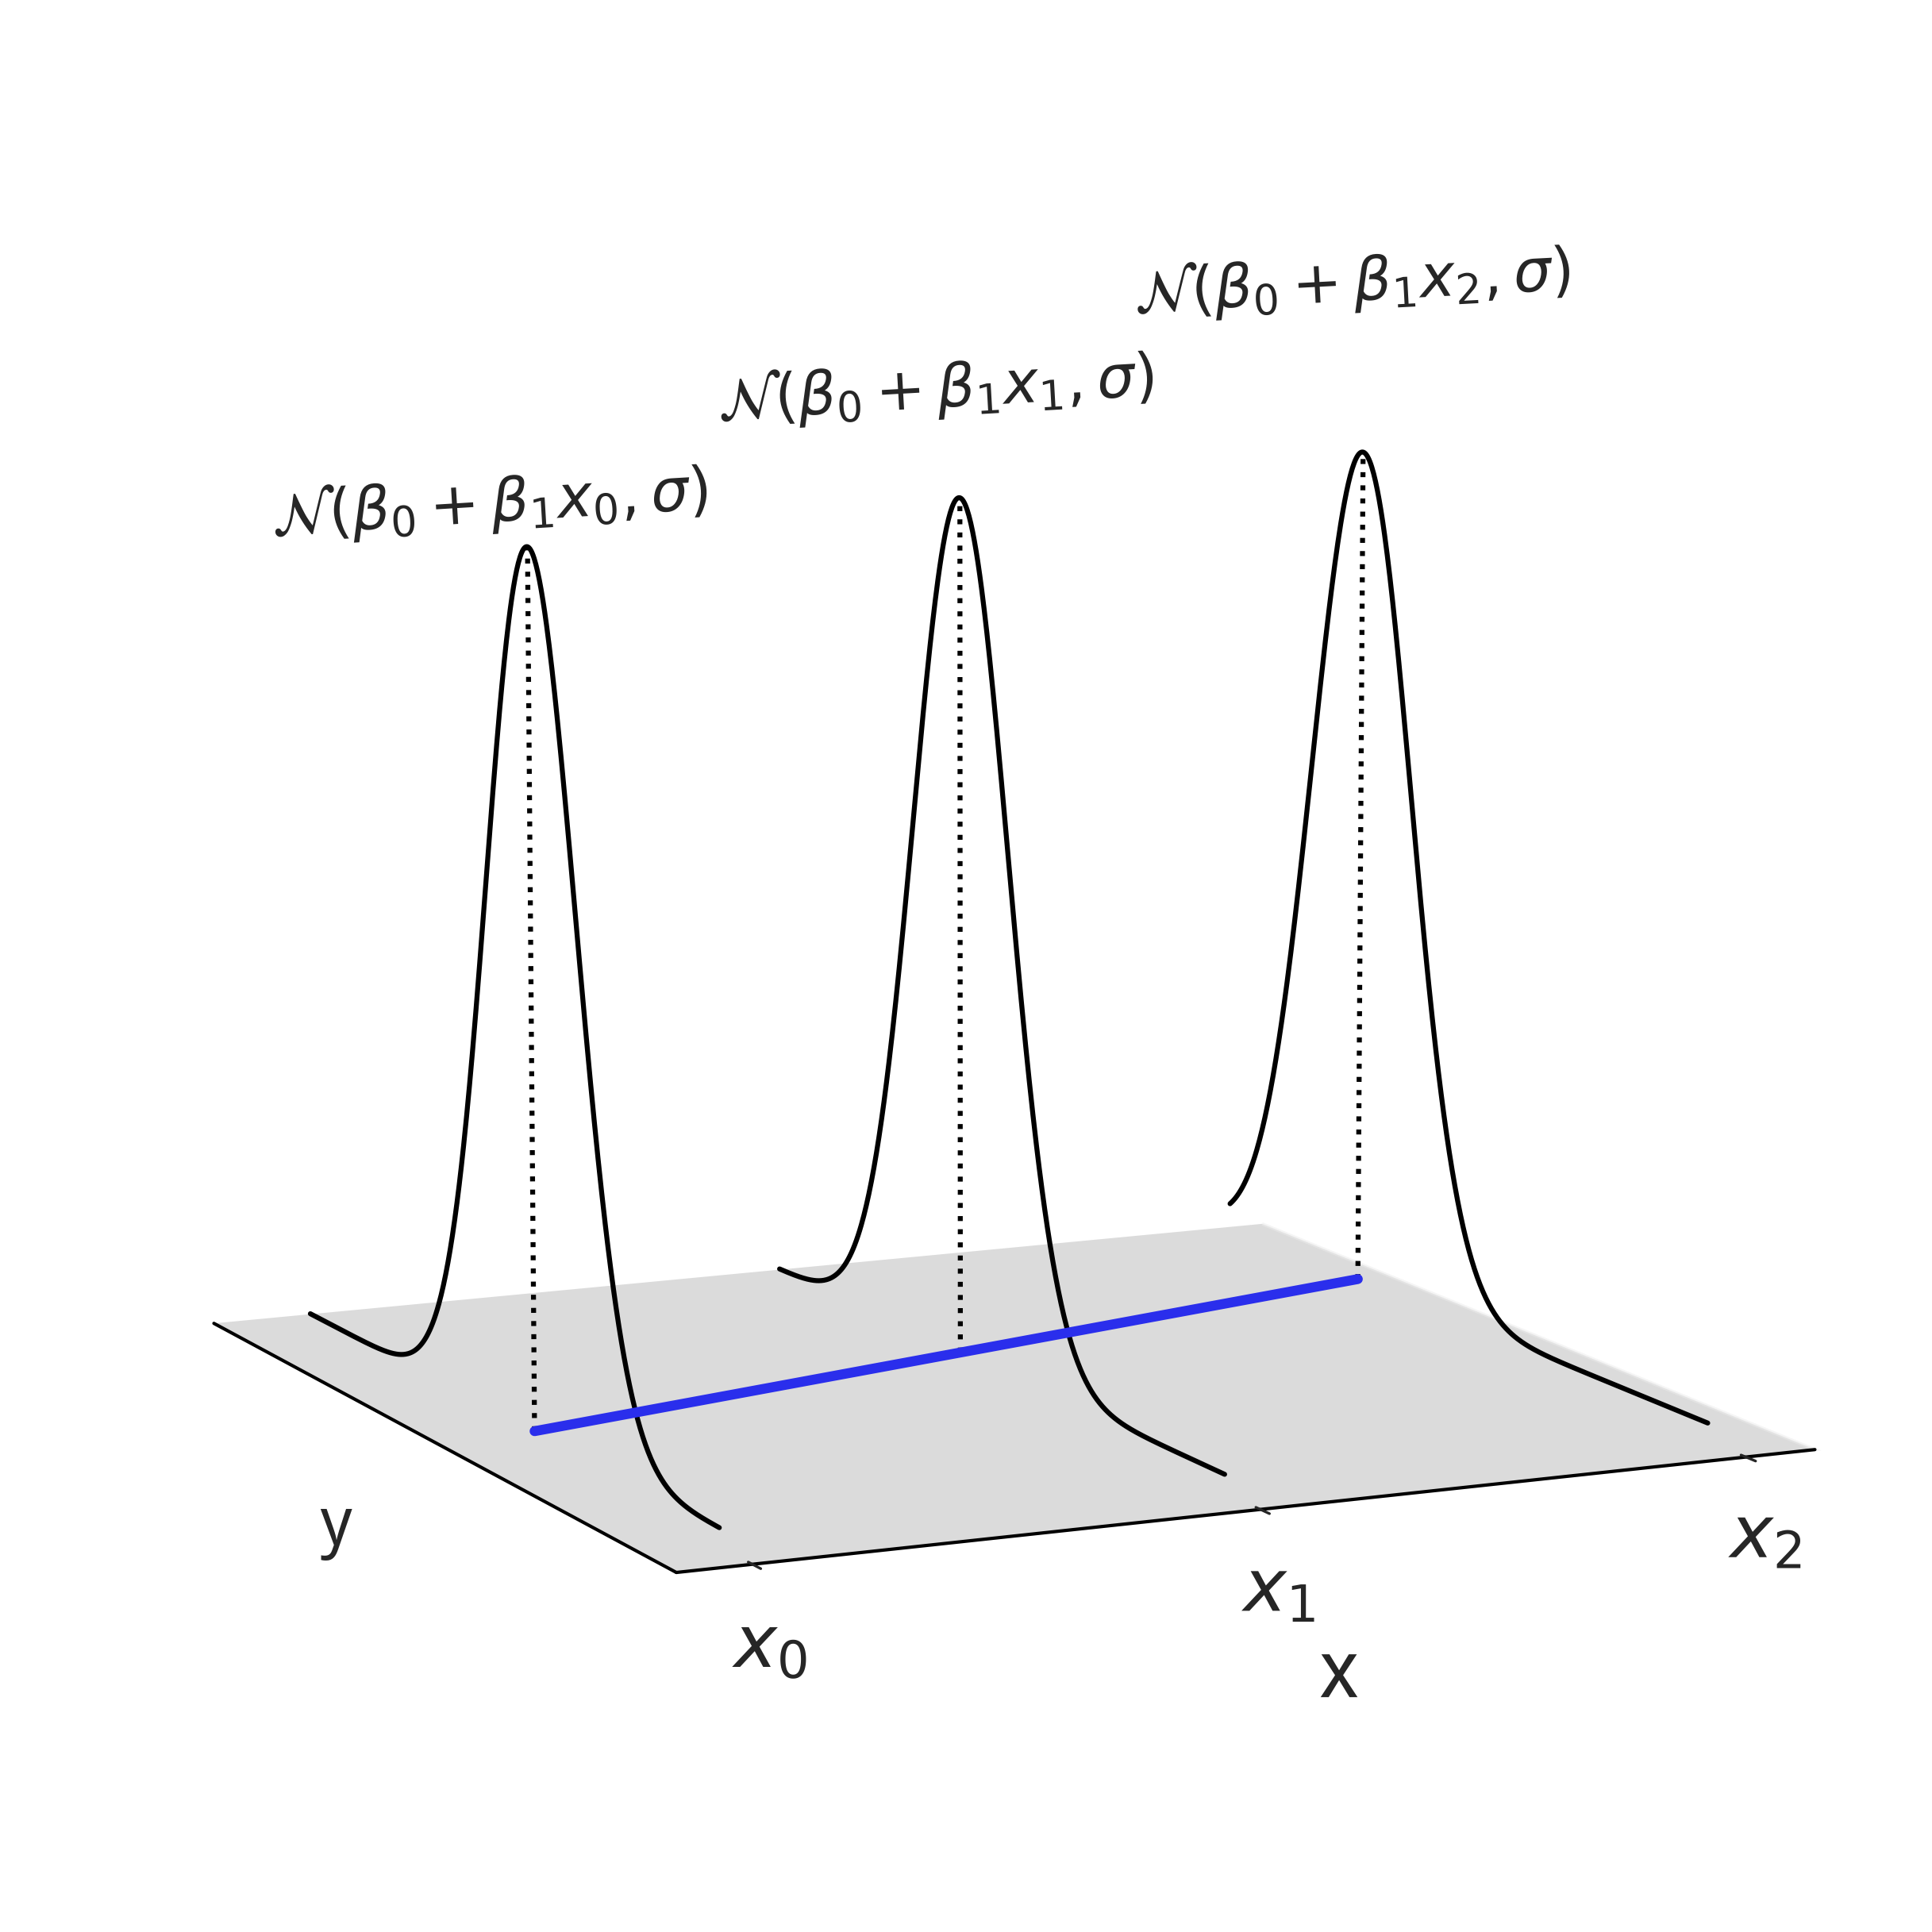

In [24]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

x = np.linspace(-16, 12, 500)
z = np.array([0, 4, 8])

for i, zi in enumerate(z):
    dens = stats.norm(-zi, 3).pdf(x)
    ax.plot(x, dens, zs=zi + 1, zdir="y", c="k")
    ax.plot([-zi, -zi], [0, max(dens)], zs=zi + 1, c="k", ls=":", zdir="y")
    ax.text(
        -zi,
        zi - 1,
        max(dens) * 1.03 + i / 100,
        f"$\\mathcal{{N}}(\\beta_0 + \\beta_1 x_{i}, \\sigma)$",
        zdir="y",
        fontsize=18,
    )

ax.plot(-z, z + 1, "C4-", lw=3)


ax.set_xlabel("y", fontsize=20)
ax.set_ylabel("x", fontsize=24, labelpad=20)

ax.set_yticks([zi + 1 for zi in z])
ax.set_yticklabels([f"$x_{i}$" for i in range(len(z))], fontsize=22)
ax.grid(False)
ax.set_xticks([])
ax.set_zticks([])
ax.yaxis.pane.fill = False
ax.xaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("None")
ax.yaxis.pane.set_edgecolor("None")
ax.zaxis.pane.set_facecolor("C3")
ax.zaxis.line.set_linewidth(0)
ax.view_init(elev=10, azim=-25)

**图 3.7（锚点 `fig:3d_linear_regression`）** 在三个 $x$ 取值处评价高斯似然的线性回归示意图;拟合贝叶斯模型后,每个位置的分布参数本身也具有后验不确定性。

### 线性回归里的企鹅

回到企鹅的例子,我们想用额外的数据来更好地估计一组企鹅的平均体重。用线性回归写出的模型如下,
包含两个新参数 $\beta_0$、$\beta_1$,通常分别称为截距和斜率。这里我们仍然设置宽泛的先验
$\mathcal{N}(0, 4000)$,把重点放在模型本身(这也等于说我们假设自己没有相关领域知识)。运行
采样器之后,我们现在估计了 $\sigma$、$\beta_1$、$\beta_0$ 三个参数。

In [25]:
adelie_flipper_length_obs = penguins.loc[
    adelie_mask, "flipper_length_mm"
].to_numpy()
adelie_obs_id = np.arange(adelie_flipper_length_obs.size)

with pm.Model(coords={"adelie_obs": adelie_obs_id}) as model_adelie_flipper_regression:
    # pm.Data 能让我们在后面的代码块里改变预测变量及其坐标长度。
    # PyMC 5.x 起 pm.MutableData 已合并进 pm.Data(默认就是可变的)。
    adelie_flipper_length = pm.Data(
        "adelie_flipper_length",
        adelie_flipper_length_obs,
        dims="adelie_obs",
    )
    # 中文版现代化说明：同前，用 lam = 1 / sigma**2 规避
    # pm.HalfStudentT(sigma=...) 在较大 sigma 下的数值错误。
    σ = pm.HalfStudentT("σ", nu=100, lam=1 / 2000**2)
    β_0 = pm.Normal("β_0", 0, 4000)
    β_1 = pm.Normal("β_1", 0, 4000)
    μ = pm.Deterministic(
        "μ", β_0 + β_1 * adelie_flipper_length, dims="adelie_obs"
    )

    mass = pm.Normal(
        "mass", mu=μ, sigma=σ, observed=adelie_mass_obs, dims="adelie_obs"
    )

    idata_adelie_flipper_regression = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [σ, β_0, β_1]


Output()

为了节省篇幅,后面我们不会每次都展示诊断结果,但你不应该盲目信任我们(或你自己的采样器)——
请务必自己运行诊断,验证你得到的后验近似是可靠的。

采样完成后,我们画出下图,用来检视 $\beta_0$ 和 $\beta_1$ 的完整后验分布。系数 $\beta_1$
告诉我们:Adelie 企鹅鳍肢长度每变化 1 毫米,条件均值会变化多少克。具体点估计和 HDI 应从你
实际运行得到的 `az.summary` 或后验图读取,而不要把某次随机运行的数字写死。若斜率的 94% HDI
不跨越 0,数据就支持体重与鳍肢长度之间存在统计关联。但我们也要小心,不要过度解读系数,或者
误以为线性模型必然意味着因果关系。比如,如果给一只企鹅做"延长鳍肢手术",并不必然会让它体重
增加——实际上由于应激或者觅食受阻,体重可能反而下降。反过来同样不一定成立:给企鹅提供更多
食物,可能帮助它长出更长的鳍肢,但也可能只是让它变得更肥胖。再看 $\beta_0$,它代表什么?它是
模型对鳍肢长度为 0 毫米的 Adelie 企鹅所给出的条件均值;这个取值远离观测范围,后验往往会落在
不合理的负体重区域。按照模型来说这种外推是"成立"的,但负数体重显然没有意义。这倒不一定
是个问题——并没有规定说模型里每个参数都必须可解释,也没有规定模型在每个参数取值处都要给出
合理的预测。就我们目前的目标而言,这个特定模型的目的是估计鳍肢长度和企鹅体重之间的关系,而
从后验估计来看,我们已经达成了这个目标。

> **模型:数学与现实之间的平衡**:在企鹅例子里,即便模型允许体重取值低于 0(甚至接近 0),
> 这样的取值也没有实际意义。因为我们是用远离 0 的体重值来拟合模型的,所以如果想把结论外推到
> 接近 0 或低于 0 的取值,模型失效也不足为奇。一个模型不一定需要对所有可能取值都给出合理的
> 预测,它只需要在我们搭建它的目的范围内,给出合理的预测就够了。

本节一开始我们猜测,加入协变量应该能让企鹅体重的预测更准确。我们可以通过比较"固定均值模型"
与"线性变化均值模型"给出的 $\sigma$ 后验估计来验证这一点(见下图):若加入鳍肢长度后
$\sigma$ 的后验整体下移,就说明协变量解释了一部分原先留在残差中的变异。具体数值以本次运行的
森林图和汇总表为准。

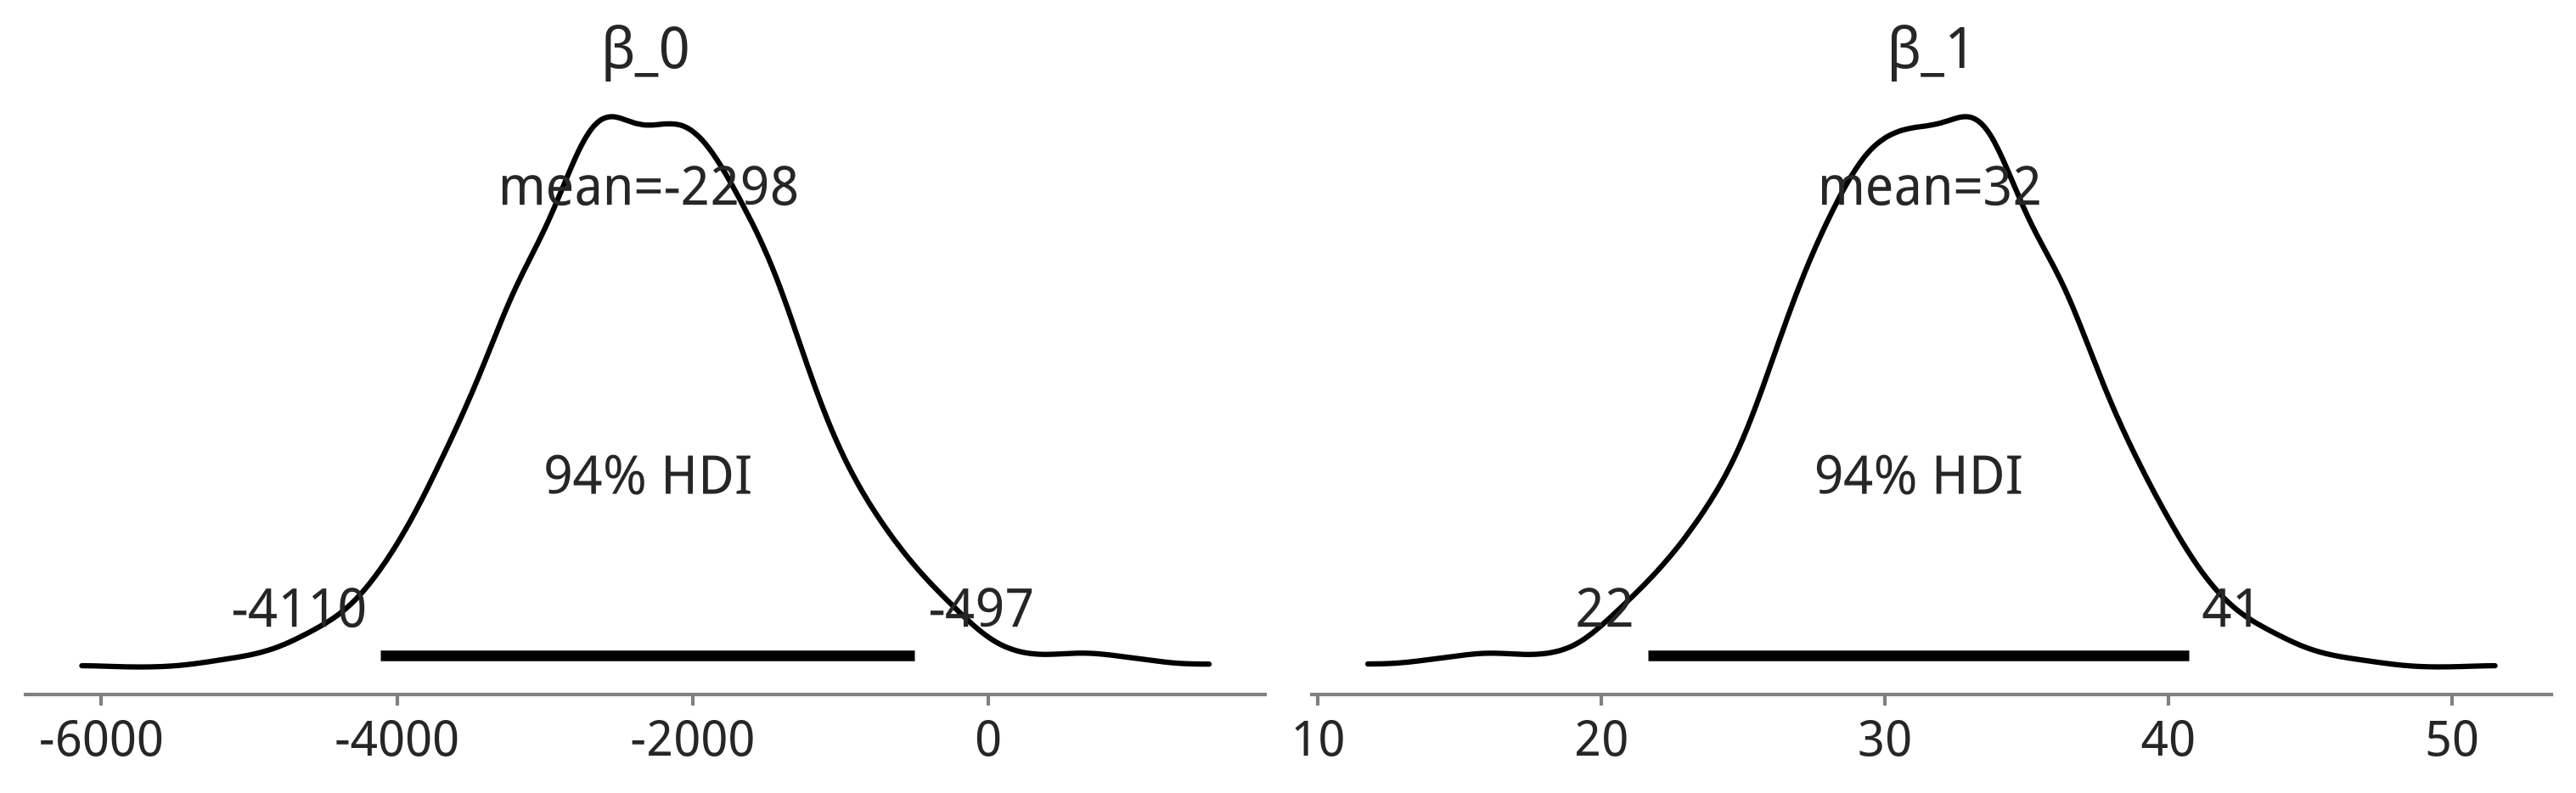

In [26]:
axes = az.plot_posterior(idata_adelie_flipper_regression, var_names = ["β_0", "β_1"], figsize=(10, 3));

**图 3.8（锚点 `fig:adelie_coefficient_posterior_plots`）** 非中心化鳍肢长度回归中截距与斜率系数的后验分布。

Text(0.5, 1.0, '模型间 σ 比较：94% HDI')

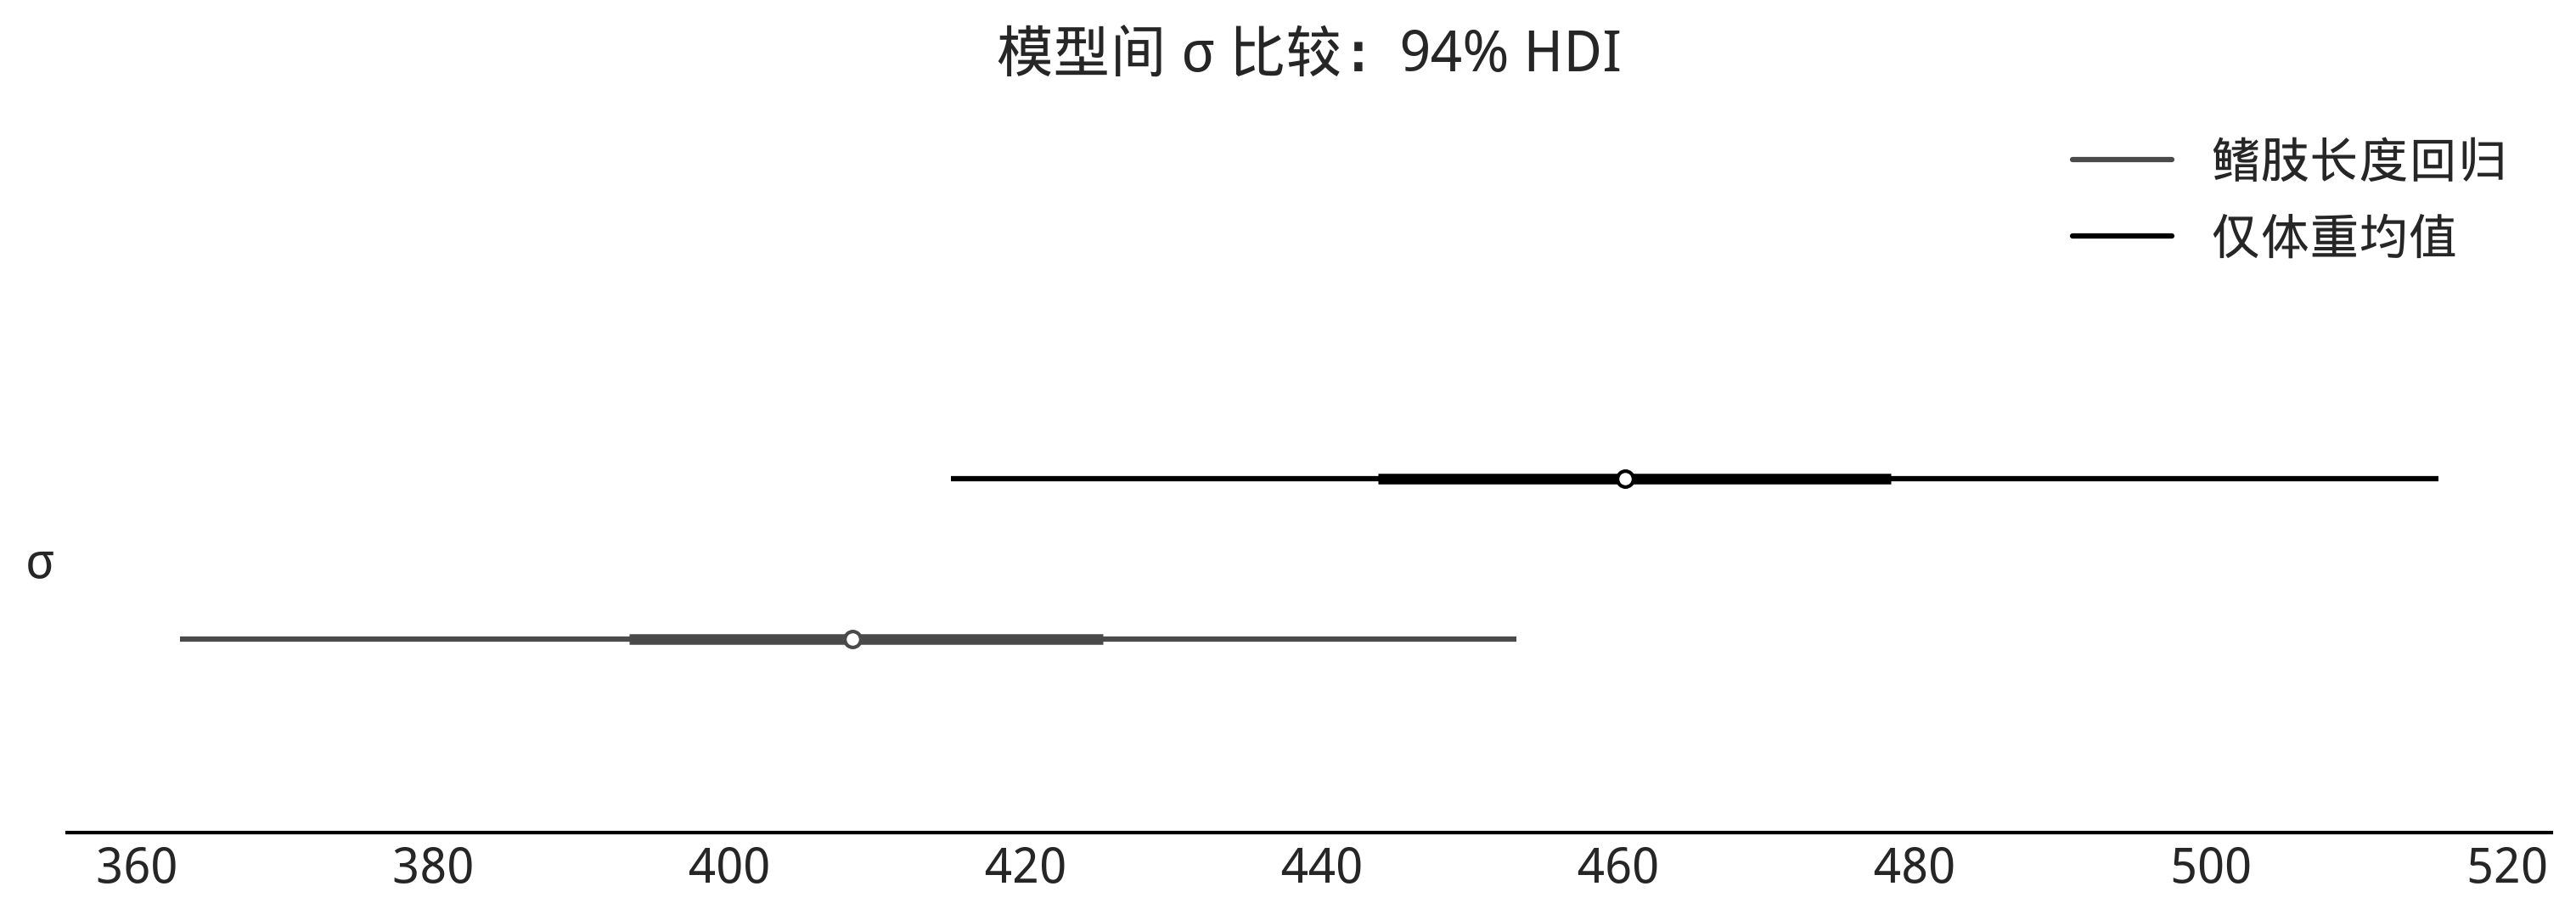

In [27]:
axes = az.plot_forest(
    [idata_adelie_mass, idata_adelie_flipper_regression],
    model_names=["仅体重均值", "鳍肢长度回归"],
    var_names=["σ"], combined=True, figsize=(10, 3.5))

axes[0].set_title("模型间 σ 比较：94% HDI")

**图 3.9（锚点 `fig:SingleSpecies_SingleRegression_Forest_Sigma_Comparison`）** 加入鳍肢长度前后残差尺度 $\sigma$ 的后验比较;整体下移表示协变量解释了部分体重变异。

In [28]:
idata_adelie_flipper_regression.posterior["β_0"].mean().item()

-2297.5212361082667

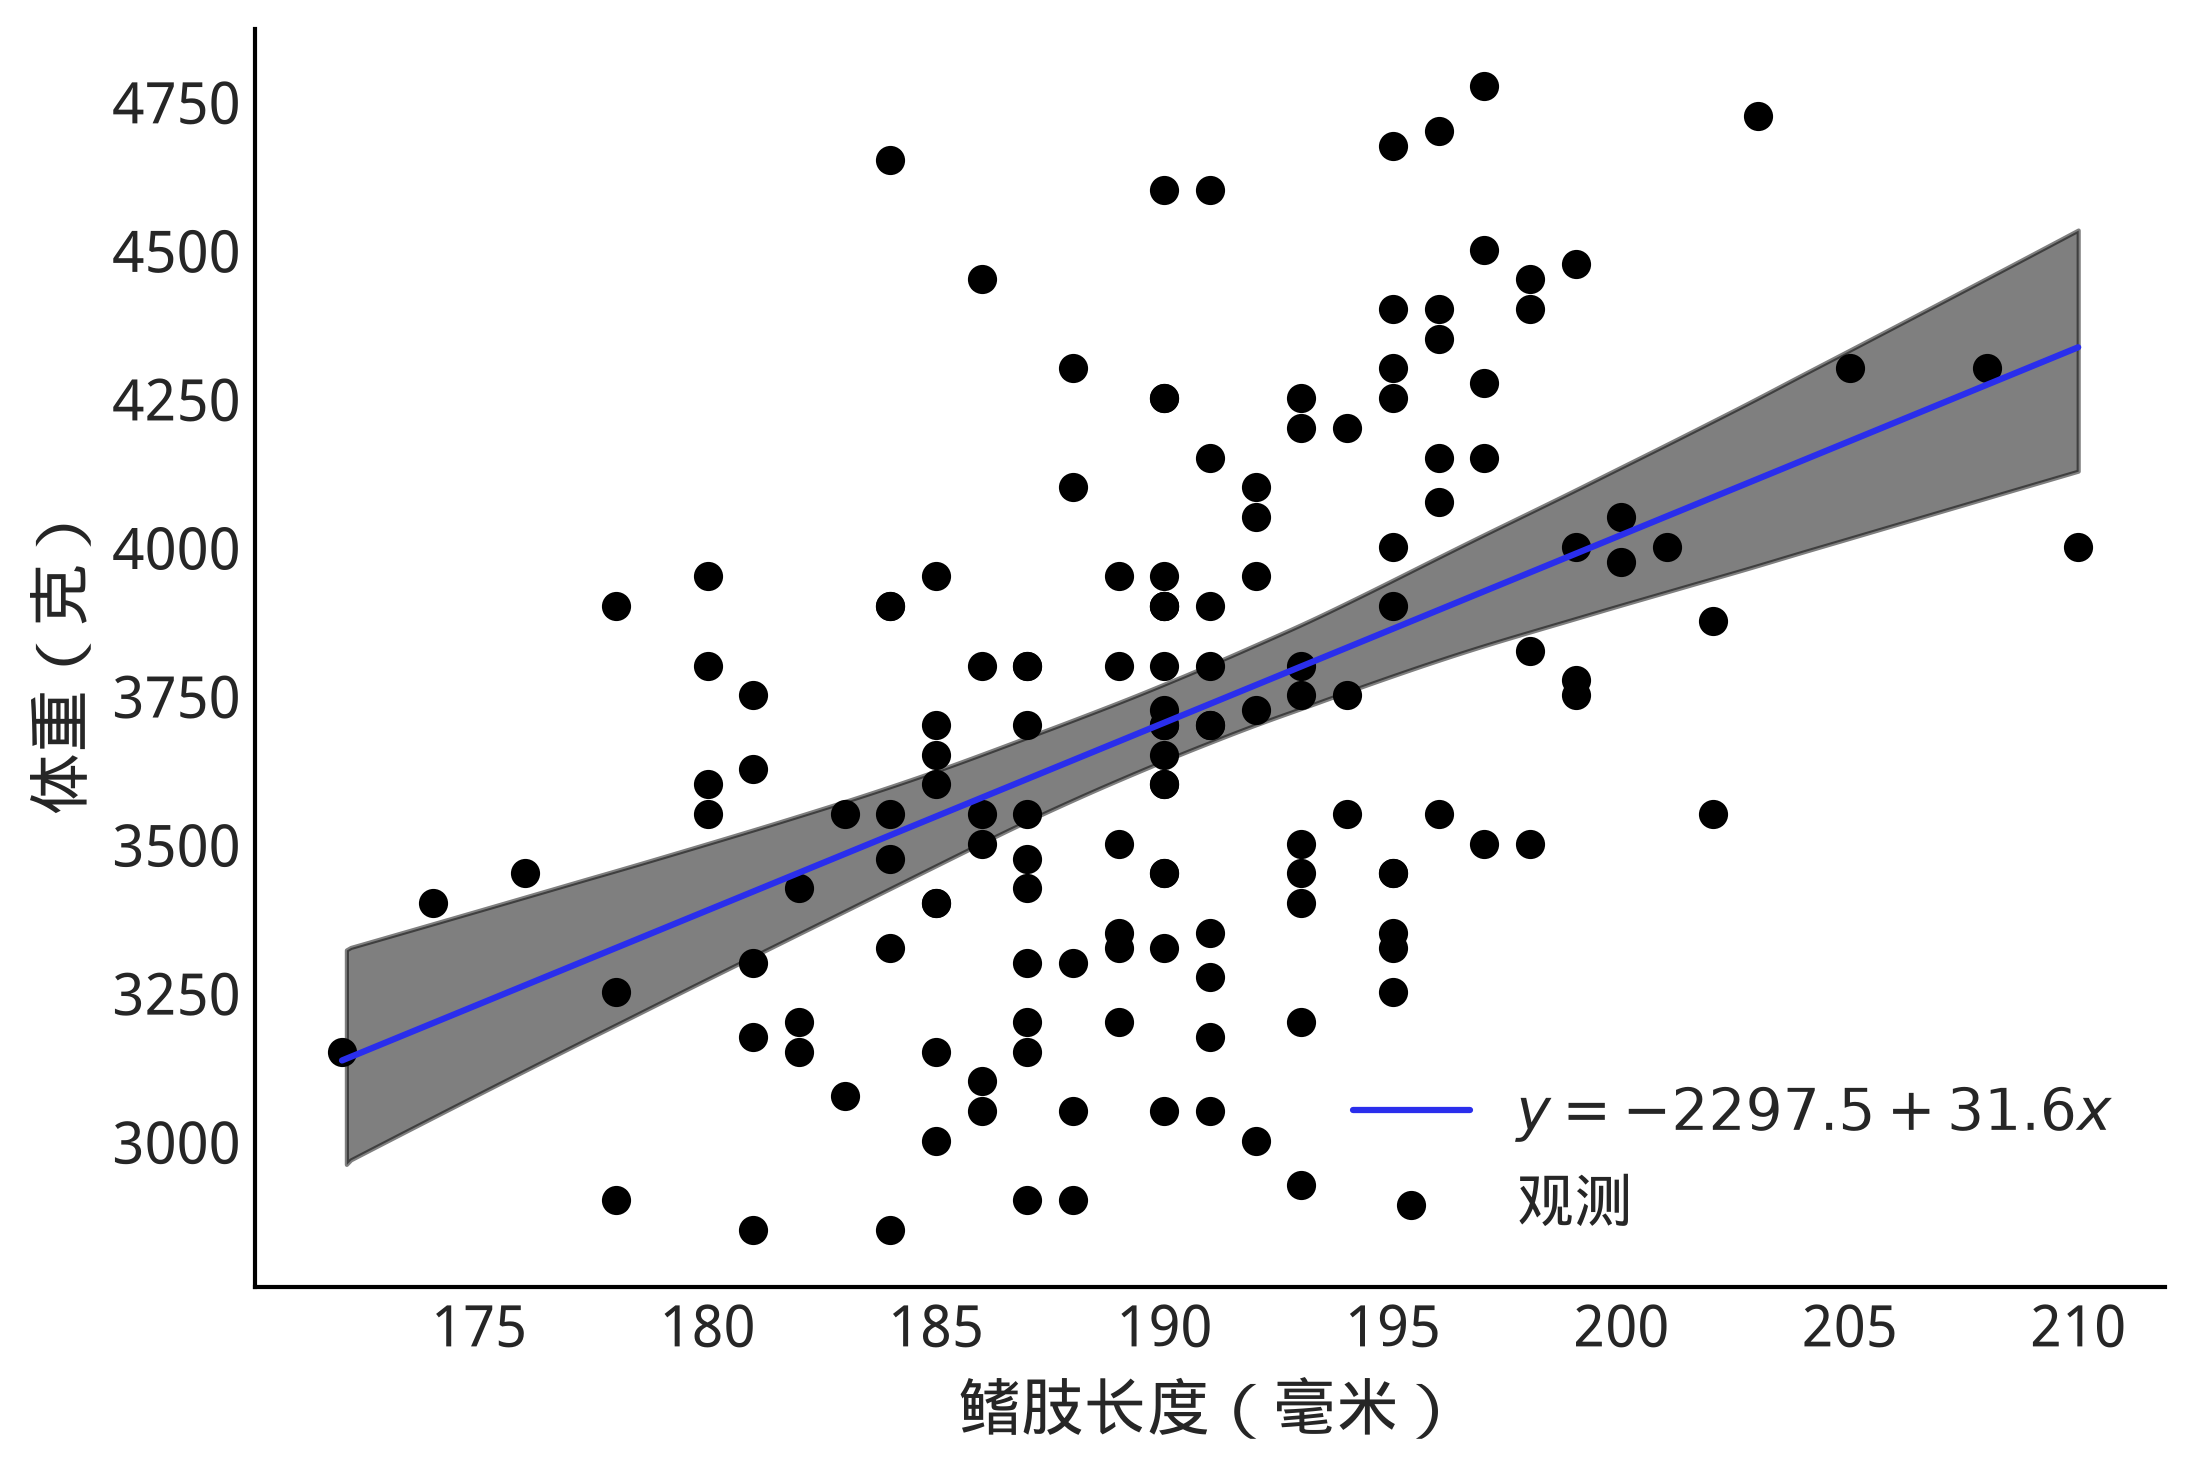

In [29]:
fig, ax = plt.subplots()
alpha_m = idata_adelie_flipper_regression.posterior["β_0"].mean().item()
beta_m = idata_adelie_flipper_regression.posterior["β_1"].mean().item()

flipper_length = np.linspace(adelie_flipper_length_obs.min(), adelie_flipper_length_obs.max(), 100)

flipper_length_mean = alpha_m + beta_m * flipper_length
ax.plot(
    flipper_length,
    flipper_length_mean,
    c="C4",
    label=rf"$y={alpha_m:.1f}+{beta_m:.1f}x$",
)

ax.scatter(adelie_flipper_length_obs, adelie_mass_obs, label="观测")

az.plot_hdi(
    adelie_flipper_length_obs,
    idata_adelie_flipper_regression.posterior["μ"],
    hdi_prob=0.94,
    color="k",
    ax=ax,
)

ax.set_xlabel("鳍肢长度（毫米）")
ax.set_ylabel("体重（克）")
ax.legend()

**图 3.10（锚点 `fig:Flipper_length_mass_regression`）** Adelie 鳍肢长度与体重观测、后验平均回归线及条件均值的 94% HDI。

### 预测

前面我们估计出了鳍肢长度与体重之间的线性关系。回归的另一个用途,就是利用这种关系来做预测:
给定一只企鹅的鳍肢长度,能否预测它的体重?当然可以。我们会用 `model_adelie_flipper_regression`
的结果来做这件事。因为在贝叶斯统计中我们处理的是分布,所以最终得到的不是单一的预测值,而是
一整个可能取值的分布——也就是前面定义过的后验预测分布。实践中,我们通常不会用解析方法计算
预测,而是用 PPL、基于后验样本来估计。比如,如果有一只鳍肢长度恰好是平均值的企鹅,想用 PyMC
预测它可能的体重,可以这样写:

In [30]:
mean_flipper_length = float(adelie_flipper_length_obs.mean())

with model_adelie_flipper_regression:
    # 同时更新 pm.Data 与具名坐标,让预测维从训练样本数变为 1。
    pm.set_data(
        {"adelie_flipper_length": np.array([mean_flipper_length])},
        coords={"adelie_obs": ["mean_flipper_length"]},
    )
    posterior_predictions = pm.sample_posterior_predictive(
        idata_adelie_flipper_regression,
        var_names=["mass", "μ"],
        predictions=True,
        random_seed=RANDOM_SEED,
    )

    # 恢复训练数据,避免模型对象在后续交互式重用时仍停留在单点预测状态。
    pm.set_data(
        {"adelie_flipper_length": adelie_flipper_length_obs},
        coords={"adelie_obs": adelie_obs_id},
    )

Sampling: [mass]


Output()

代码先用 `pm.set_data` 把鳍肢长度和具名坐标改成一个新预测点,再用
`pm.sample_posterior_predictive(..., predictions=True)` 生成样本。`predictions=True` 会把结果放进
`InferenceData.predictions` 组,明确表示这些是样本外预测,而不是对训练观测的复制。最后恢复训练
数据,方便交互式重用模型。下图画出了"平均鳍肢长度企鹅"体重的预测分布,以及条件均值本身的后验。

[]

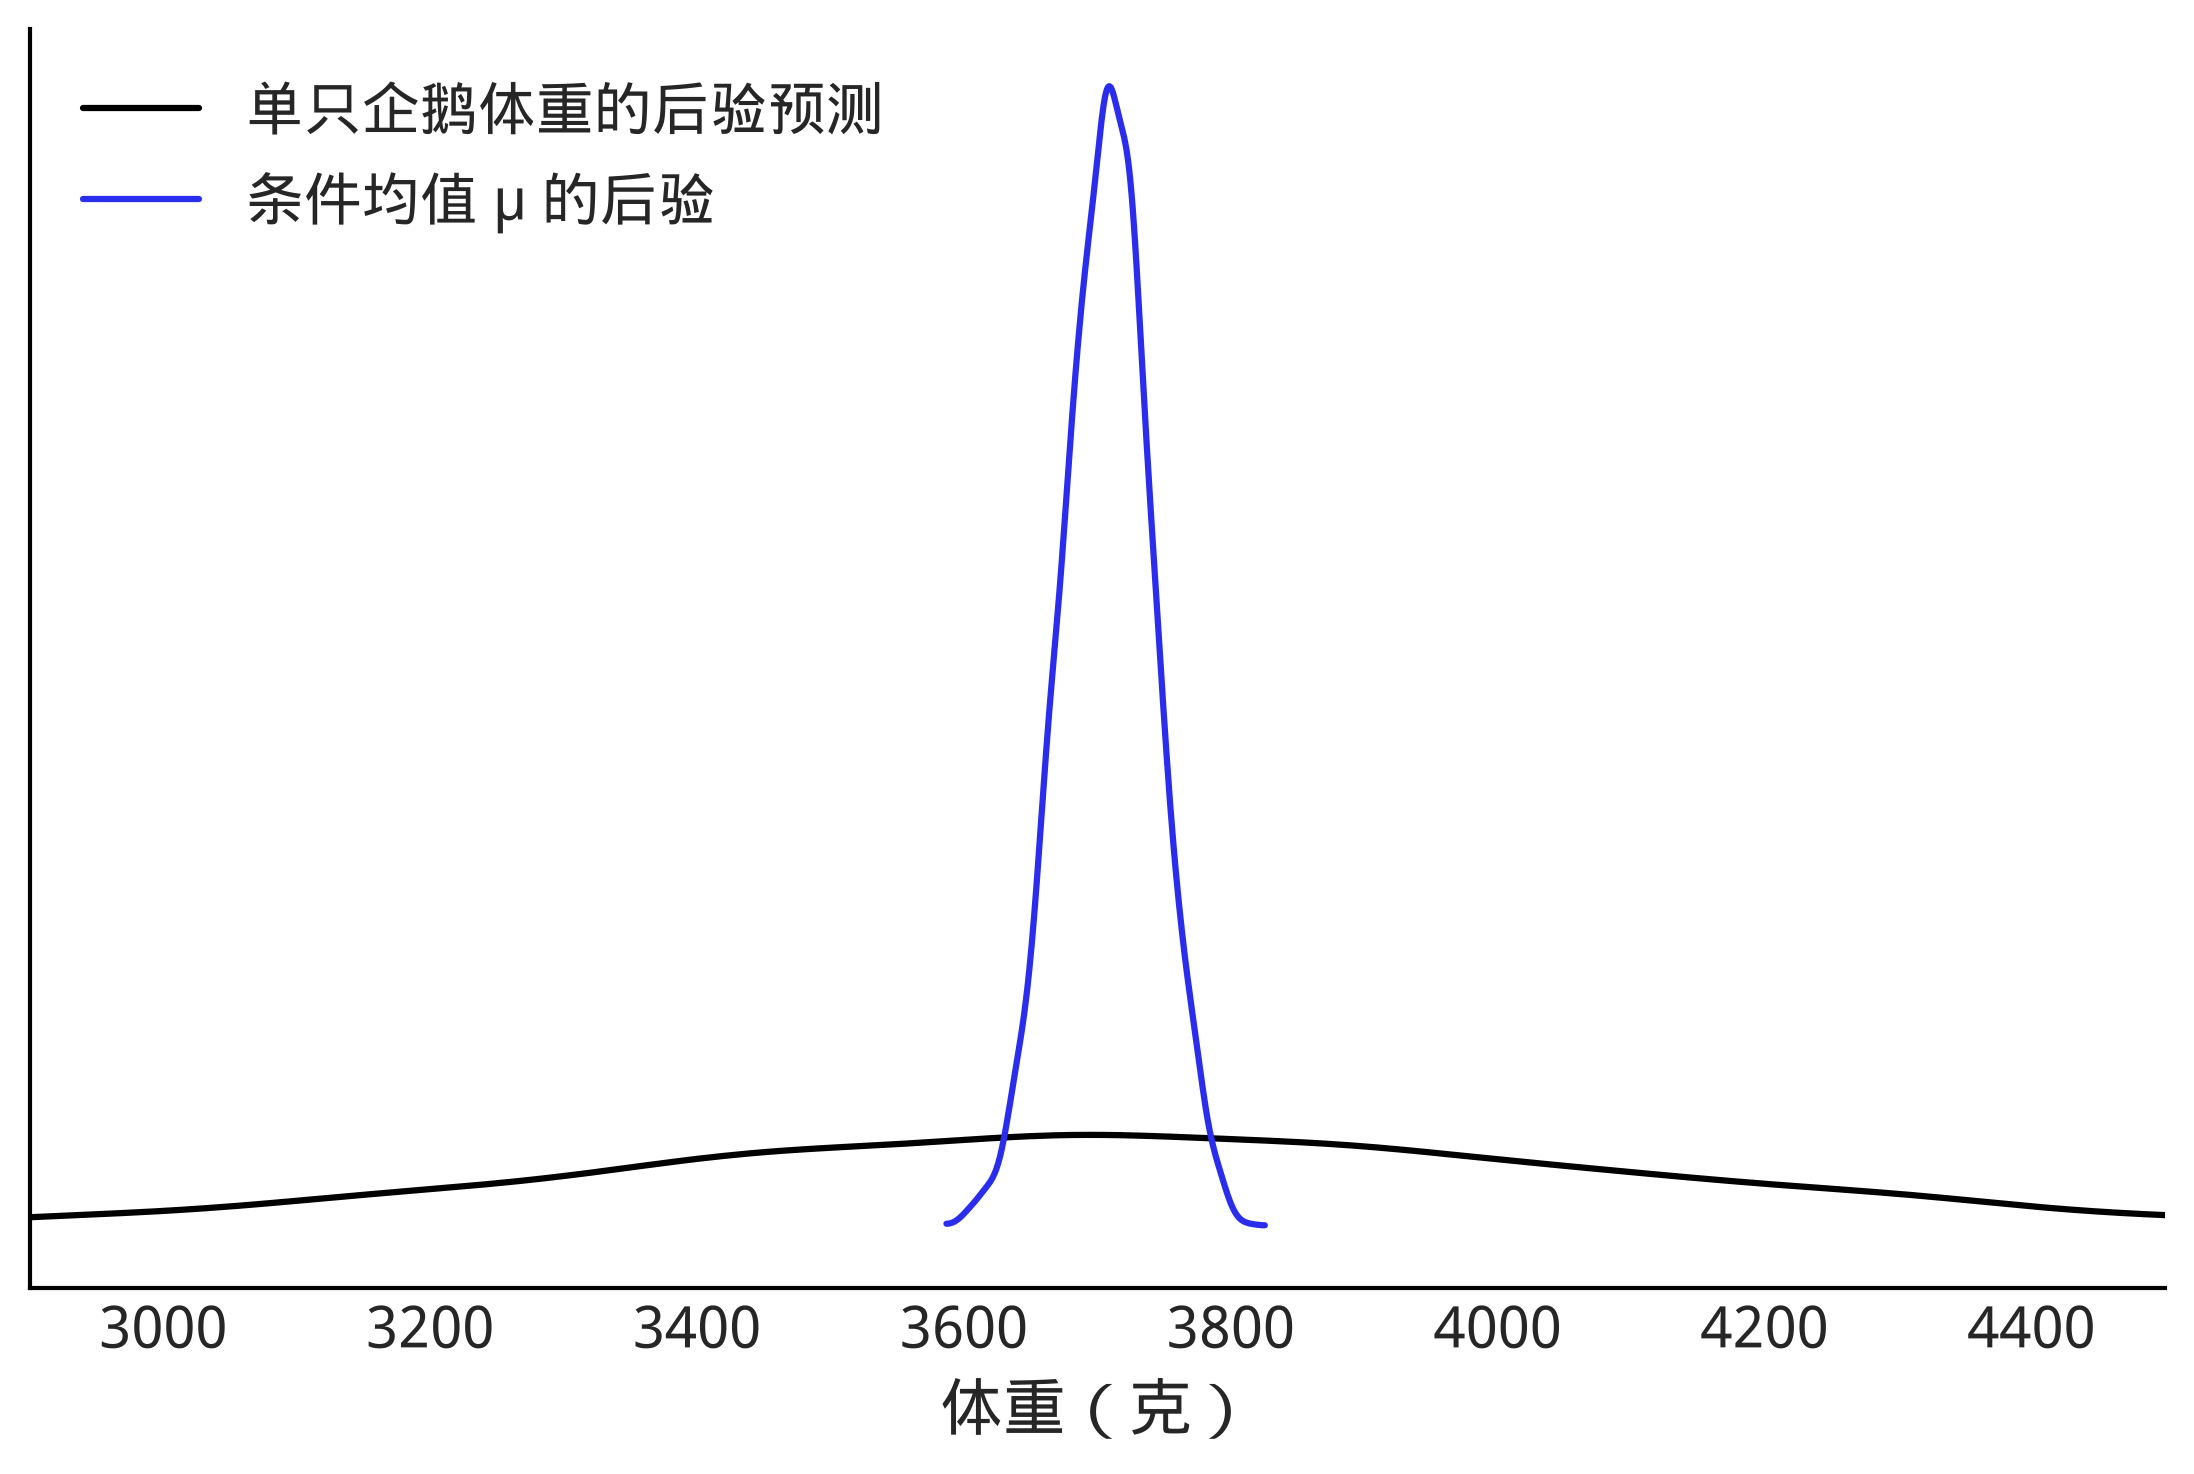

In [31]:
fig, ax = plt.subplots()
az.plot_dist(
    posterior_predictions.predictions["mass"],
    label="单只企鹅体重的后验预测",
    ax=ax,
)
az.plot_dist(
    posterior_predictions.predictions["μ"],
    label="条件均值 μ 的后验",
    color="C4",
    ax=ax,
)
ax.set_xlim(2900, 4500)
ax.legend(loc=2)
ax.set_xlabel("体重（克）")
ax.set_yticks([])

**图 3.11（锚点 `fig:Flipper_length_mass_posterior_predictive`）** 平均鳍肢长度处的条件均值后验与单只企鹅体重预测;后者还包含观测噪声,因而更宽。

简而言之,我们不仅能用前面的模型估计鳍肢长度和体重的关系,还能得到任意给定鳍肢长度下的体重
估计——换句话说,可以用估计出的 $\beta_0$、$\beta_1$ 系数,借助后验预测分布,为任意鳍肢长度
的"未见过的企鹅"做出体重预测。

因此,后验预测分布在贝叶斯语境下是一个特别强大的工具:它不仅能给出最可能的取值,还能给出一整
个纳入了估计不确定性的合理取值分布。

### 中心化(Centering)

前面的模型很好地估计出了鳍肢长度与企鹅体重之间的相关性,也能在给定鳍肢长度时预测体重。可惜
的是,按照当前的数据和模型,我们对 $\beta_0$ 的估计并不是特别有用。不过我们可以通过变换让
$\beta_0$ 变得更好解释——这里我们选用**中心化(centering)**变换,把一组数值的均值平移到零:

In [32]:
adelie_flipper_length_obs = penguins.loc[adelie_mask, "flipper_length_mm"].values
adelie_flipper_length_c = adelie_flipper_length_obs - adelie_flipper_length_obs.mean()

为便于对照,我们先用 PyMC 拟合中心化后的模型:

In [33]:
with pm.Model() as model_adelie_flipper_regression_centered:
    # 中文版现代化说明：同前，用 lam = 1 / sigma**2 规避
    # pm.HalfStudentT(sigma=...) 在较大 sigma 下的数值错误。
    σ = pm.HalfStudentT("σ", nu=100, lam=1 / 2000**2)
    β_1 = pm.Normal("β_1", 0, 4000)
    β_0 = pm.Normal("β_0", 0, 4000)
    μ = pm.Deterministic("μ", β_0 + β_1 * adelie_flipper_length_c)

    mass = pm.Normal("mass", mu=μ, sigma=σ, observed=adelie_mass_obs)

    idata_adelie_flipper_length_centered_pymc = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [σ, β_1, β_0]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 198 seconds.


array([<Axes: title={'center': 'β_0'}>, <Axes: title={'center': 'β_1'}>],
      dtype=object)

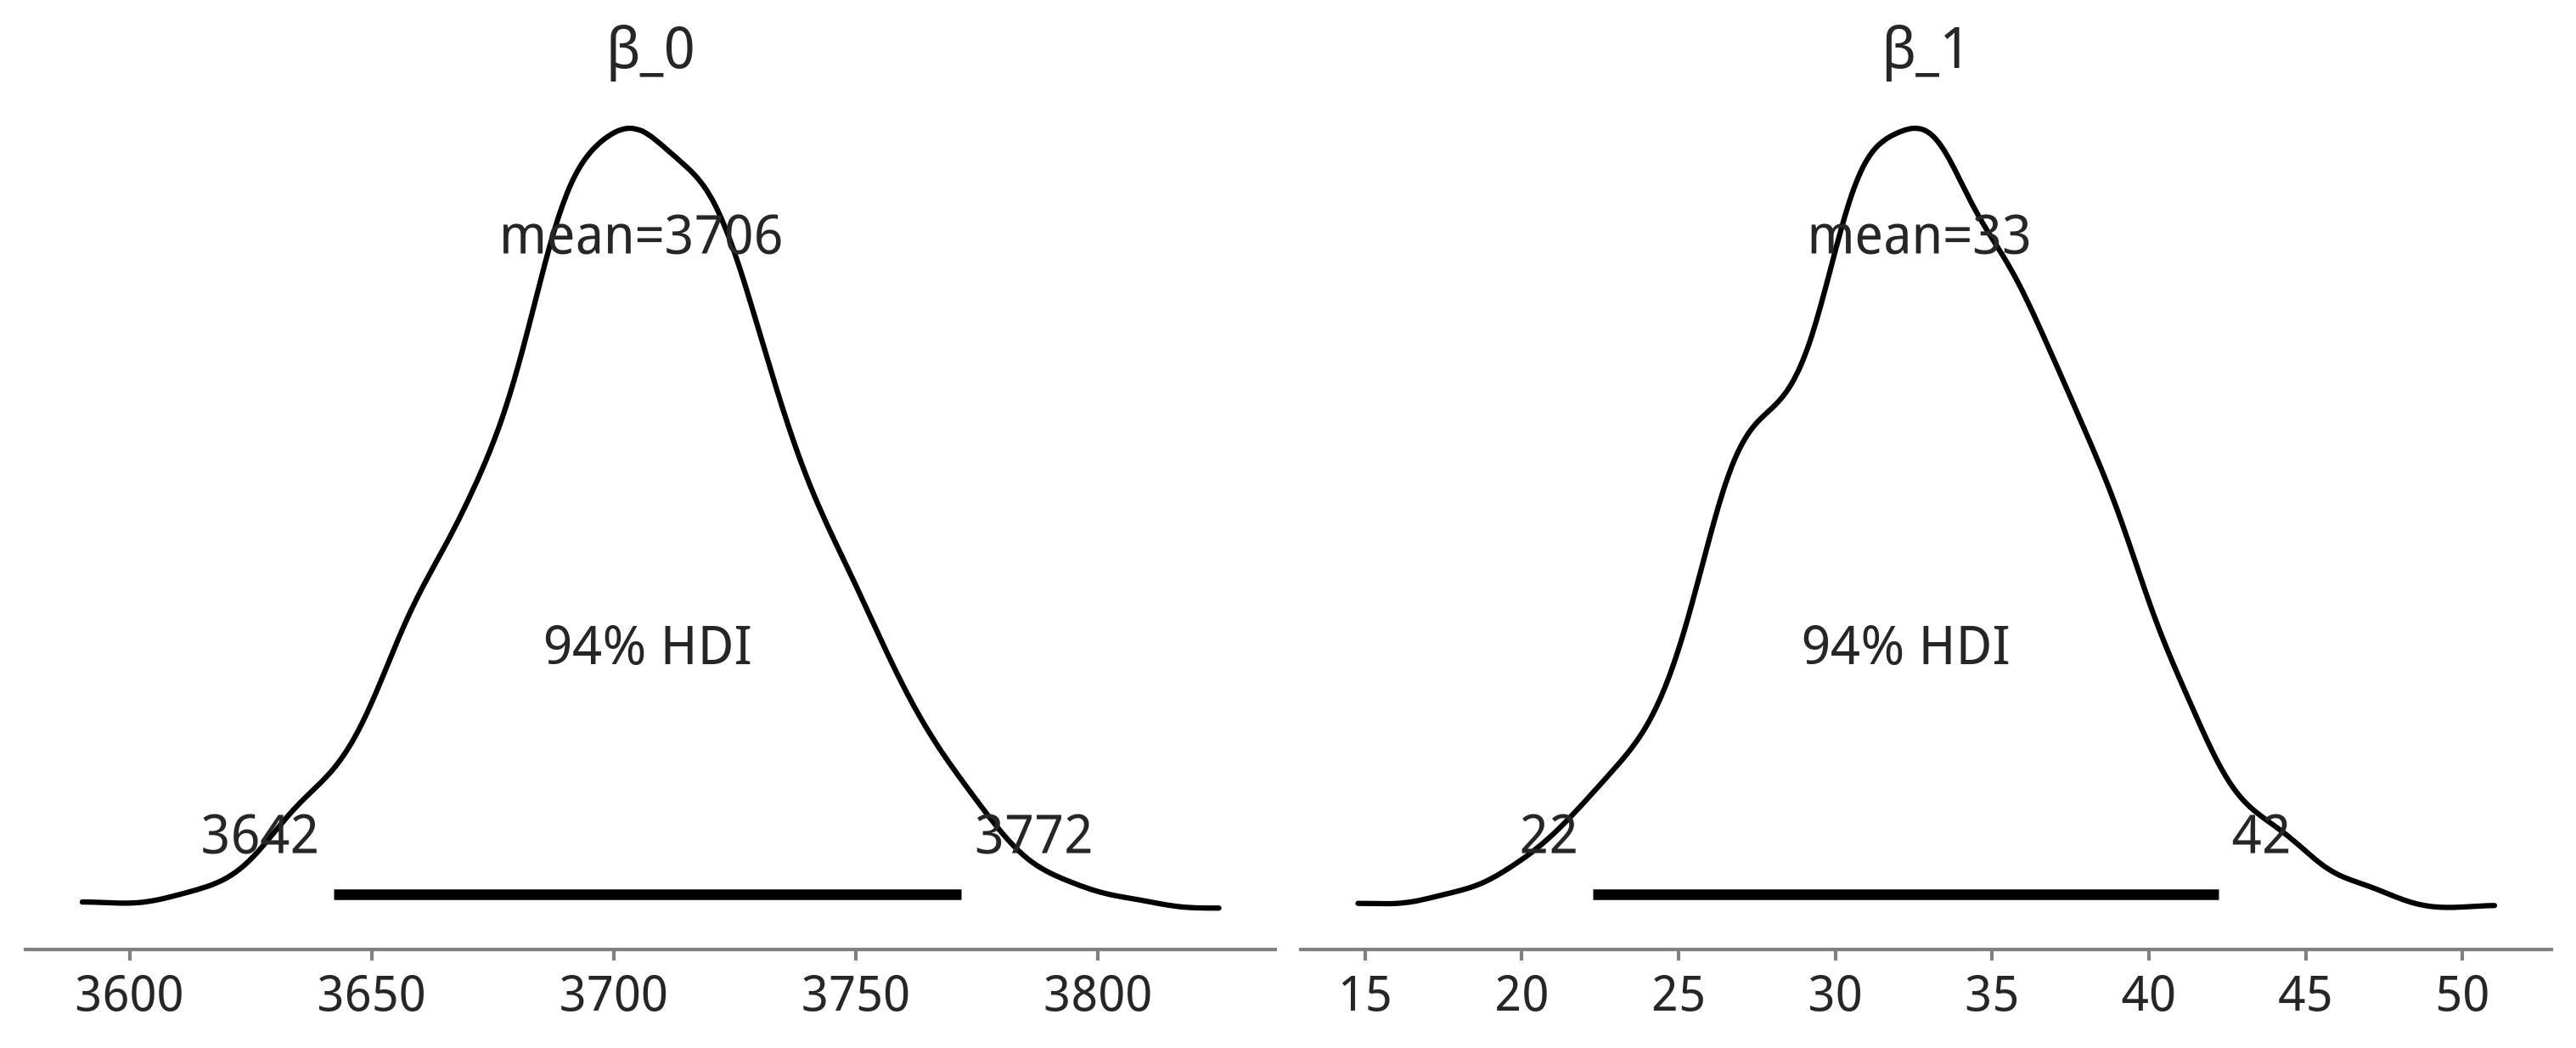

In [34]:
az.plot_posterior(
    idata_adelie_flipper_length_centered_pymc,
    var_names=["β_0", "β_1"],
    figsize=(10, 4),
)

现在用中心化后的协变量,再用 TFP 拟合一遍这个模型。

In [35]:
adelie_flipper_length_c = adelie_flipper_length_obs - adelie_flipper_length_obs.mean()

In [36]:
def gen_adelie_flipper_model(adelie_flipper_length):
    adelie_flipper_length = tf.constant(adelie_flipper_length, tf.float32)

    @tfd.JointDistributionCoroutine
    def jd_adelie_flipper_regression():
        σ = yield root(tfd.HalfStudentT(df=100, loc=0, scale=2000, name='sigma'))
        β_1 = yield root(tfd.Normal(loc=0, scale=4000, name='beta_1'))
        β_0 = yield root(tfd.Normal(loc=0, scale=4000, name='beta_0'))
        μ = β_0[..., None] + β_1[..., None] * adelie_flipper_length
        mass = yield tfd.Independent(
            tfd.Normal(loc=μ, scale=σ[..., None]),
            reinterpreted_batch_ndims=1,
            name='mass')

    return jd_adelie_flipper_regression


# 用中心化后的协变量拟合(与上面 PyMC 的中心化模型等价)
jd_adelie_flipper_regression = gen_adelie_flipper_model(
    adelie_flipper_length_c)

mcmc_samples_centered_tfp, sampler_stats_centered_tfp = run_mcmc(
    TFP_DRAWS,
    jd_adelie_flipper_regression,
    n_chains=CHAINS,
    num_adaptation_steps=TFP_ADAPT,
    seed=tf.constant([RANDOM_SEED, 2], tf.int32),
    mass=tf.constant(adelie_mass_obs, tf.float32),
)

idata_adelie_flipper_length_centered_tfp = az.from_dict(
    posterior={
        k: np.swapaxes(v, 1, 0)
        for k, v in mcmc_samples_centered_tfp._asdict().items()
    },
    sample_stats={
        k: np.swapaxes(sampler_stats_centered_tfp[k], 1, 0)
        for k in ["target_log_prob", "diverging", "accept_ratio", "n_steps"]
    },
)

array([<Axes: title={'center': 'beta_0'}>,
       <Axes: title={'center': 'beta_1'}>], dtype=object)

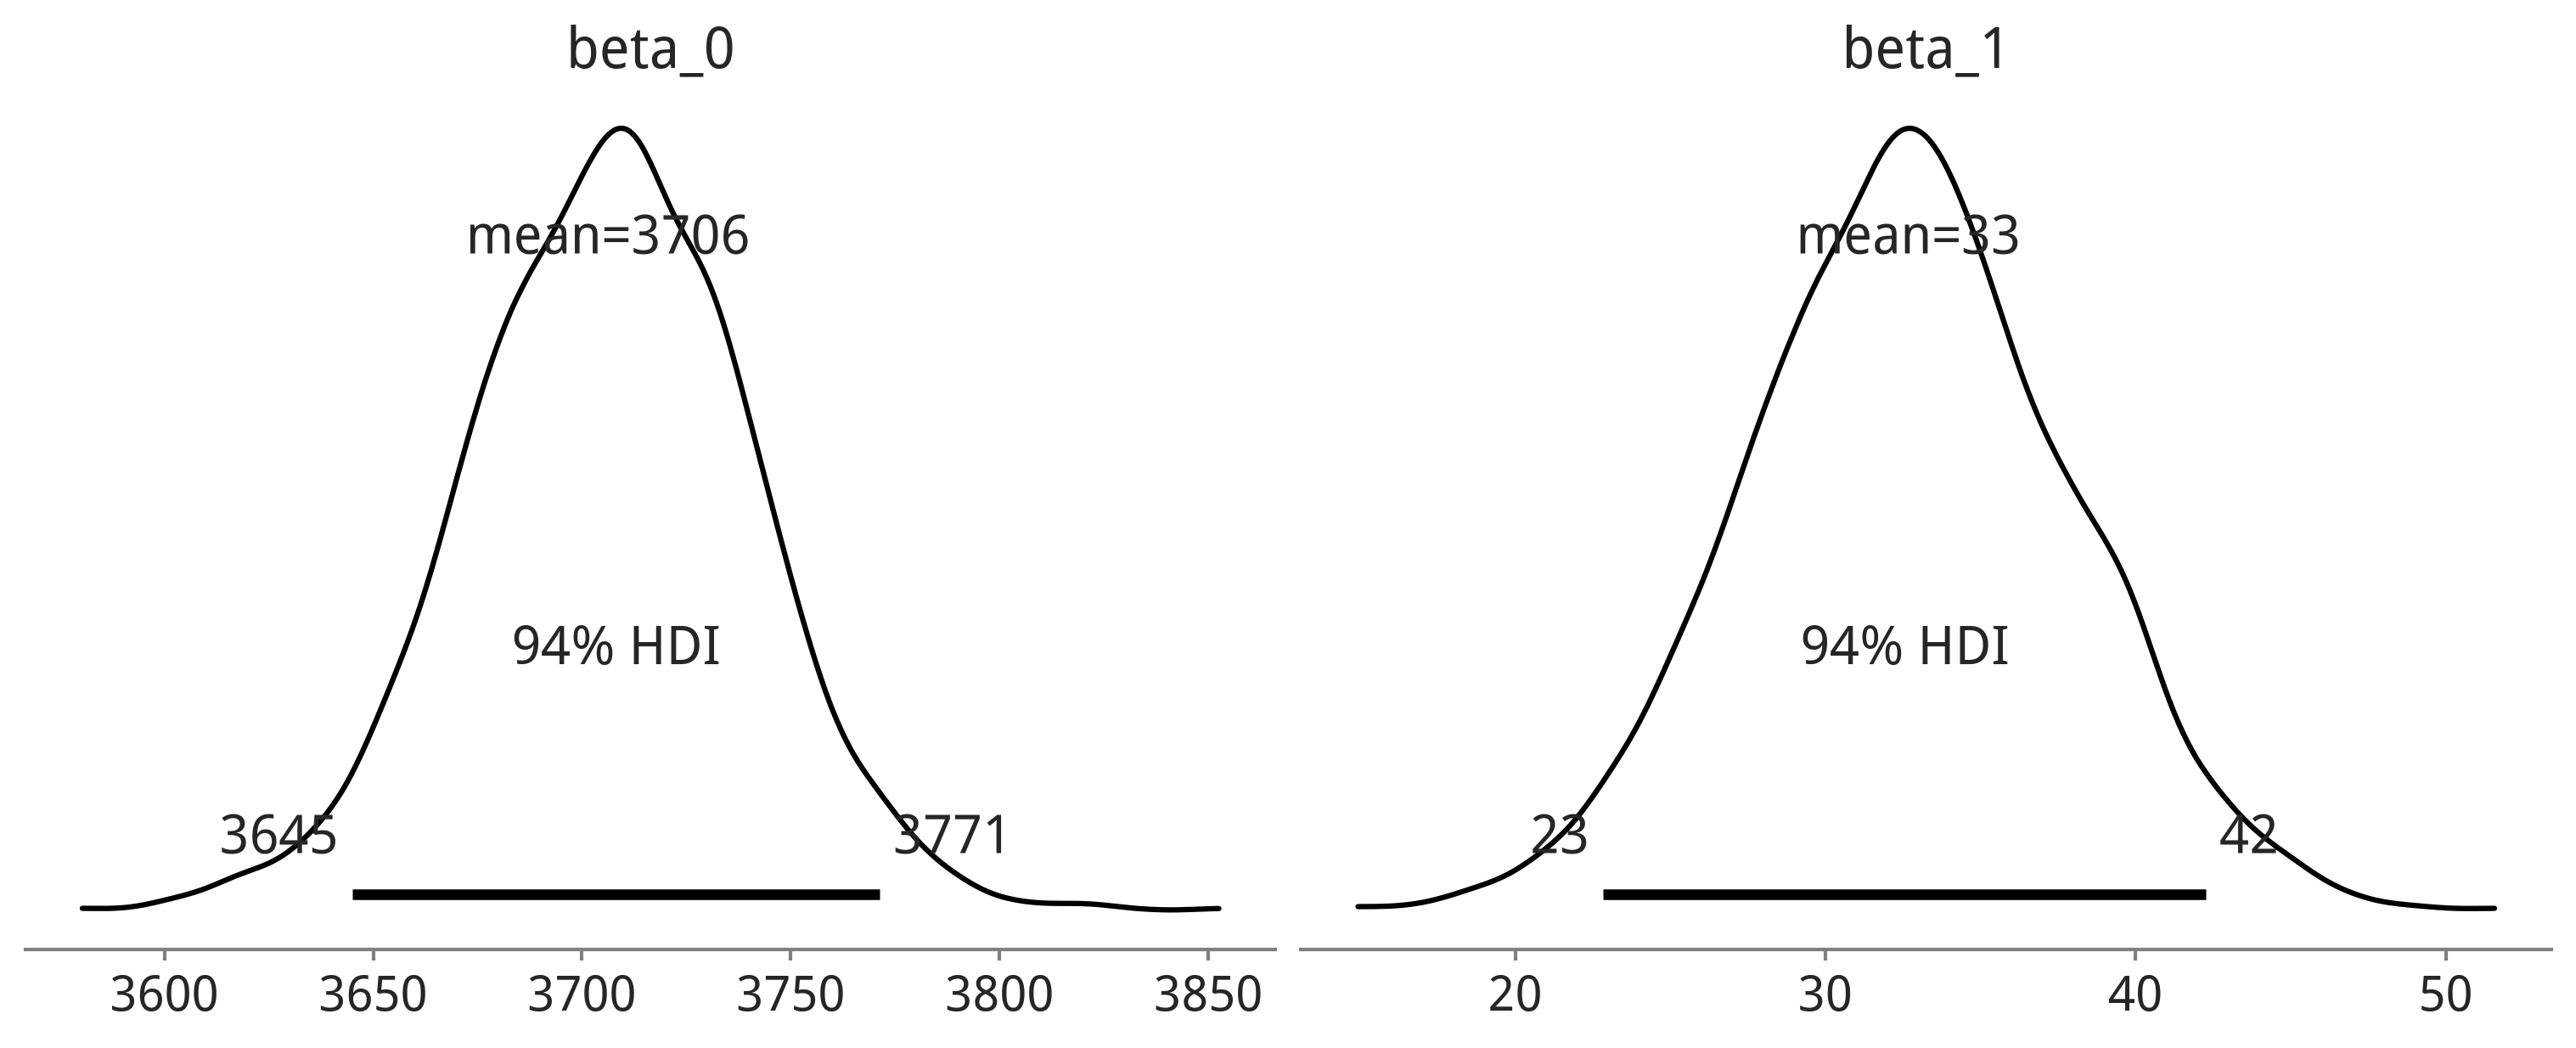

In [37]:
az.plot_posterior(
    idata_adelie_flipper_length_centered_tfp,
    var_names=["beta_0", "beta_1"],
    figsize=(10, 4),
)

**图 3.12（锚点 `fig:SingleSpecies_multipleRegression_Centered`）** TFP 中心化模型的系数后验。中心化基本不改变斜率,但让截距表示平均鳍肢长度处的体重均值。

这里用 TFP 定义的数学模型,与前面的 PyMC 中心化模型
`model_adelie_flipper_regression_centered` 等价;原始的非中心化模型
`model_adelie_flipper_regression` 仍保留为独立对象,不会被覆盖。从 PPL 的角度看,TFP 的结构
要求我们在好几处加上
`tensor_x[..., None]`,把标量批次扩展一维,以便能和向量批次做广播。具体来说,`None`
会追加一个新的轴,等价的写法还有 `np.newaxis` 或 `tf.newaxis`。我们还把模型包在一个函数
里,方便以后用不同的协变量做条件化——这里我们用的是中心化后的鳍肢长度,但换成非中心化的
协变量,结果也会与之前的模型接近。

再画一遍系数图会发现,$\beta_1$ 和 PyMC 模型给出的结果一样,但 $\beta_0$ 的分布变了。由于
我们把输入数据在其均值处做了中心化,现在 $\beta_0$ 的分布,正好等价于之前非中心化数据集下对
"分组均值"的预测。通过中心化,我们现在可以直接把 $\beta_0$ 解读为"具有平均鳍肢长度的 Adelie
企鹅"体重均值的分布。这种对输入变量做变换的思路,也可以在任意选定的取值处进行——比如我们
也可以减去观测到的最小鳍肢长度来拟合模型,这样 $\beta_0$ 的含义就会变成"鳍肢长度最小的那些
企鹅"的均值分布。关于线性回归中变换的更多讨论,推荐参阅《Applied Regression Analysis and
Generalized Linear Models》一书 {cite:p}`fox_fox_2016`。

## 多元线性回归

许多物种都存在性二态性(sexual dimorphism,即雌雄个体存在系统性差异)。事实上,对企鹅性
二态性的研究 {cite:p}`gorman_williams_fraser_2014`,正是最初收集 Palmer Penguins 数据集的动机
之一。为了更深入地研究企鹅的性二态性,
我们再加入第二个协变量——性别,把它编码成类别变量,看看能否更精确地估计企鹅体重。

In [38]:
# 把类别型预测变量二元编码
# 注意这里补充了 .astype(int).values:较新版本 pandas 会把字符串列读成
# 扩展的 StringDtype,对它调用 .replace({...}) 把值换成 0/1 之后,
# 结果并不会像旧版 pandas 那样自动降级为数值 dtype,而是停留在
# dtype=object 的数组上。这样的 object 数组和 pytensor 张量做运算时,
# 会被 numpy 自己的逐元素运算符接管,得到一个 dtype=object 的数组而不是
# 真正的 pytensor 张量表达式,传给 pm.Deterministic 时会报错,因此这里
# 显式转换成 int
sex_obs = penguins.loc[adelie_mask ,"sex"].replace({"male":0, "female":1}).astype(int).values

with pm.Model() as model_penguin_mass_categorical:
    # 中文版现代化说明：同前，用 lam = 1 / sigma**2 规避
    # pm.HalfStudentT(sigma=...) 在较大 sigma 下的数值错误。
    σ = pm.HalfStudentT("σ", nu=100, lam=1 / 2000**2)
    β_0 = pm.Normal("β_0", 0, 3000)
    β_1 = pm.Normal("β_1", 0, 3000)
    β_2 = pm.Normal("β_2", 0, 3000)

    μ = pm.Deterministic(
        "μ", β_0 + β_1 * adelie_flipper_length_obs + β_2 * sex_obs)

    mass = pm.Normal("mass", mu=μ, sigma=σ, observed=adelie_mass_obs)

    inf_data_penguin_mass_categorical = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        target_accept=.9, random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [σ, β_0, β_1, β_2]


Output()

你会注意到多了一个新参数 $\beta_2$,参与到 $\mu$ 的取值中。由于性别是类别型预测变量(本例中
只有雌雄两类),我们分别编码为 1 和 0。对模型来说,这意味着雌性企鹅的 $\mu$ 是三项之和,而
雄性企鹅的 $\mu$ 是两项之和(因为 $\beta_2$ 那一项会被清零)。

array([<Axes: title={'center': 'β_0'}>, <Axes: title={'center': 'β_1'}>,
       <Axes: title={'center': 'β_2'}>], dtype=object)

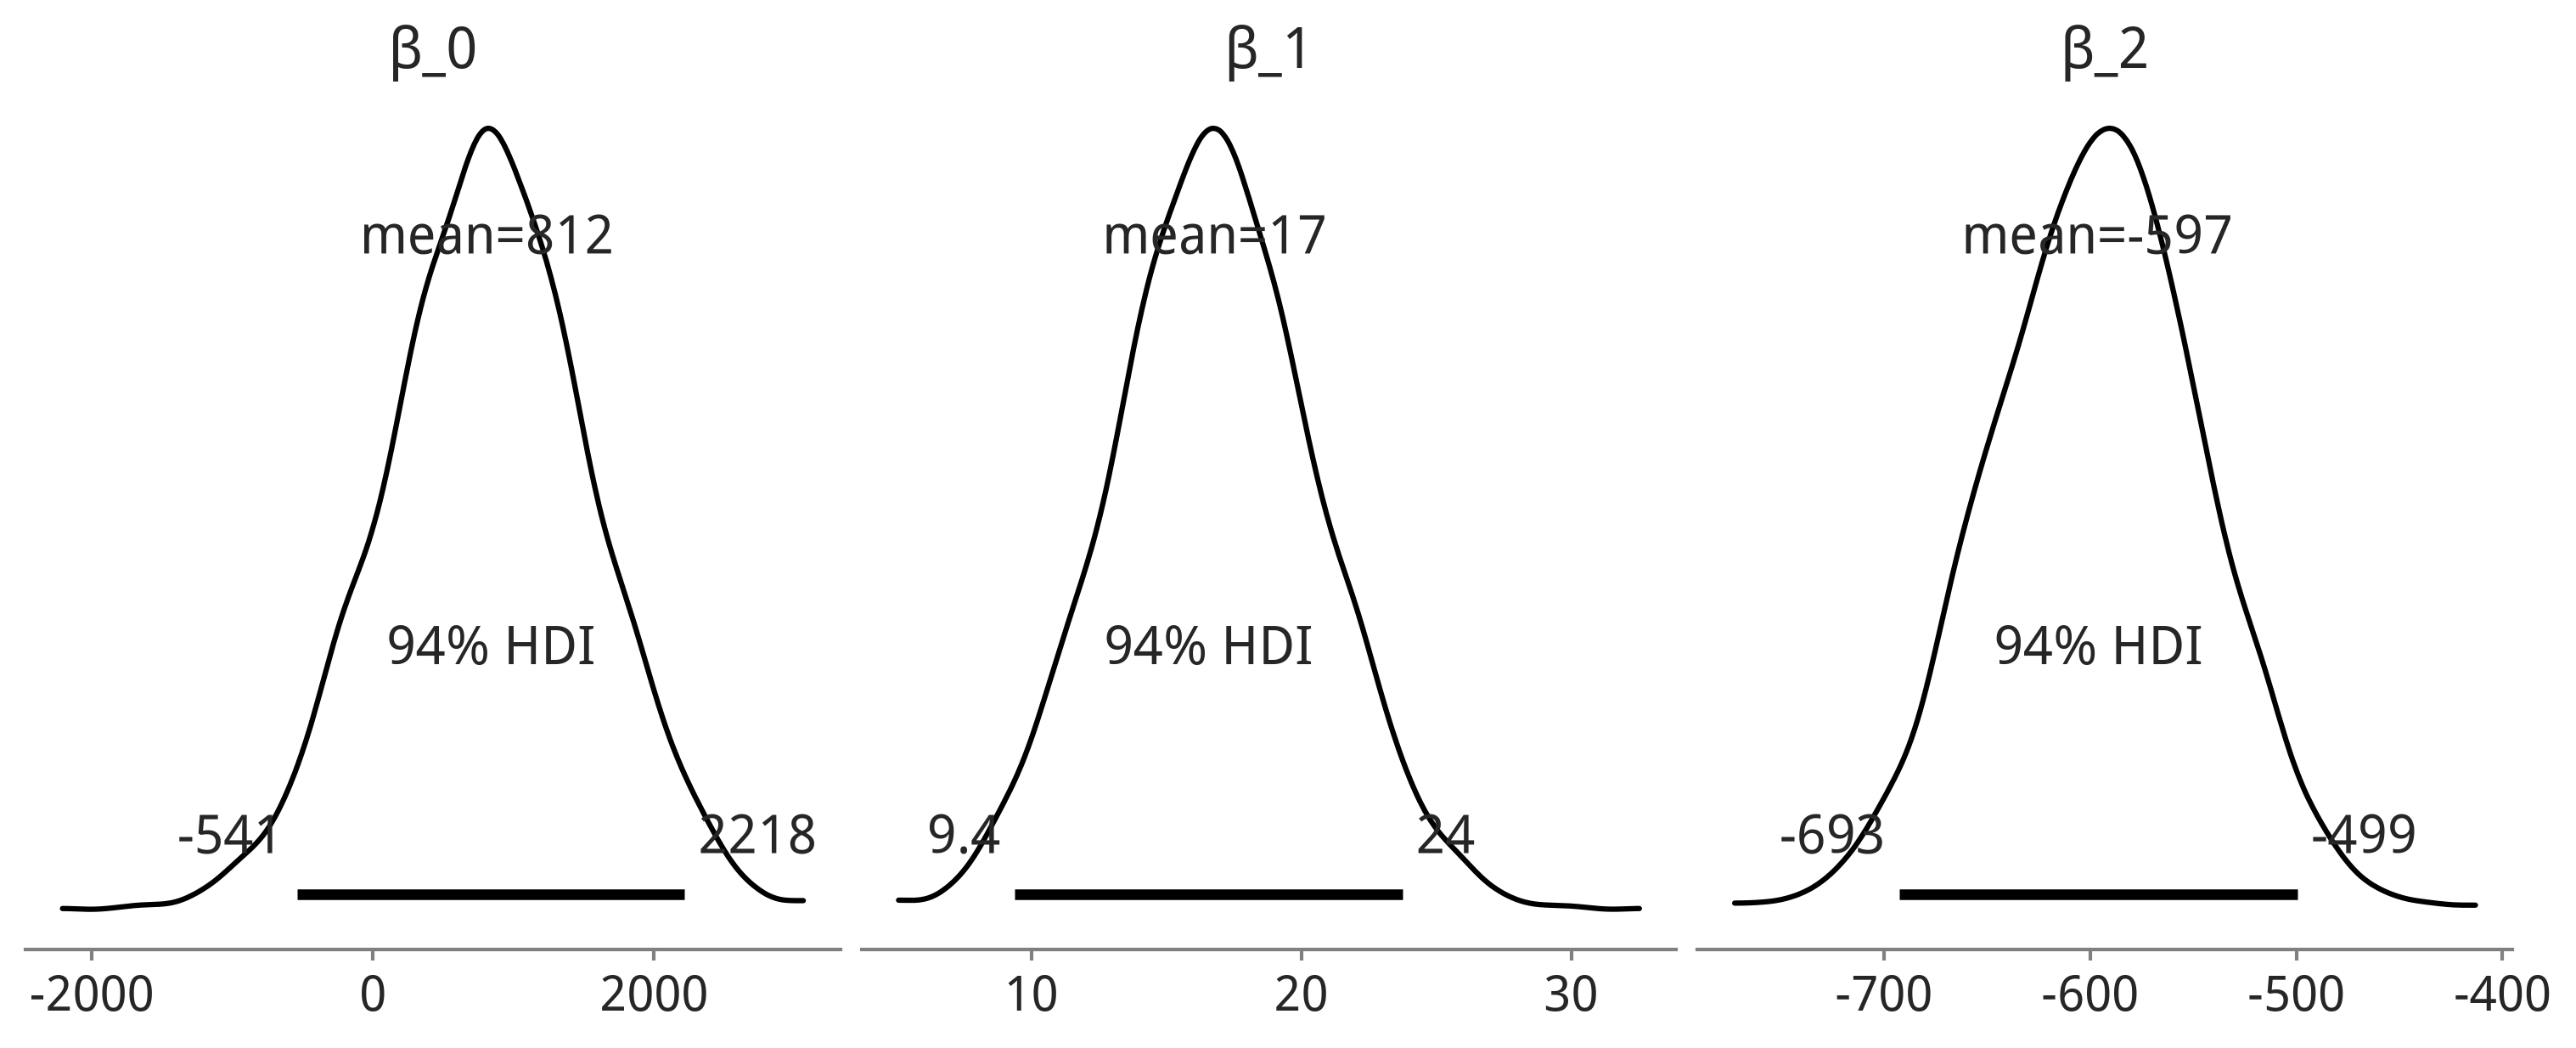

In [39]:
az.plot_posterior(inf_data_penguin_mass_categorical, var_names =["β_0", "β_1", "β_2"], figsize=(10, 4))

**图 3.13（锚点 `fig:adelie_sex_coefficient_posterior`）** 加入性别后的回归系数后验;在雄性编码为 0、雌性编码为 1 时,$eta_2$ 表示相同鳍肢长度下雌雄条件均值之差。

In [40]:
az.summary(inf_data_penguin_mass_categorical, var_names=["β_0","β_1","β_2", "σ"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β_0,811.864,733.140,-541.000,2217.802,18.476,13.182,1583.0,1591.0,1.0
β_1,16.793,3.812,9.374,23.746,0.096,0.068,1595.0,1591.0,1.0
β_2,-596.510,51.520,-692.609,-499.483,1.147,0.898,2016.0,1998.0,1.0
σ,297.429,17.317,263.444,329.274,0.372,0.319,2195.0,2264.0,1.0


> **线性模型的语法糖**:线性模型的应用极其广泛,以至于专门有人为回归写了特殊的语法、方法和
> 库。Bambi(BAyesian Model-Building Interface){cite:p}`capretto2020` 就是其中之一——一个用
> 公式语法拟合广义线性层级模型的 Python 包,风格类似 R 语言里的 lme4 {cite:p}`lme4`、nlme
> {cite:p}`nlme`、rstanarm {cite:p}`gabry_goodrich_2020` 或 brms {cite:p}`brms` 等包。Bambi
> 底层使用 PyMC,提供了更高层的 API。如果不考虑先验的具体设置 [^4],上面那个模型用 Bambi
> 大致可以写成:
>
> ```python
> import bambi as bmb
> model = bmb.Model("body_mass_g ~ flipper_length_mm + sex", penguins[adelie_mask])
> trace = model.fit()
> ```
>
> 这段代码是可选对照示例,本章的必需运行环境不导入 Bambi。若要执行它,请另外安装与当前 PyMC
> 版本兼容的 `bambi`,并先检查自动先验是否符合你的建模目的。
>
> 如果没有指定先验,Bambi 会自动分配。在内部,Bambi 几乎保存了 PyMC 生成的所有对象,方便
> 用户获取、检查和修改。此外 Bambi 还会返回一个 `az.InferenceData` 对象,可以直接配合
> ArviZ 使用。

由于我们把男性(male)编码为 0,`model_penguin_mass_categorical` 给出的后验,估计的是"在
鳍肢长度相同的前提下",雌性 Adelie 企鹅与雄性相比,体重的差异。这一点很重要:一旦加入了第二
个协变量,我们就有了一个多元线性回归,解读系数时需要更加谨慎——此时系数表示的是:**在其他
协变量保持不变的前提下**,某个协变量与响应变量之间的关系 [^5]。

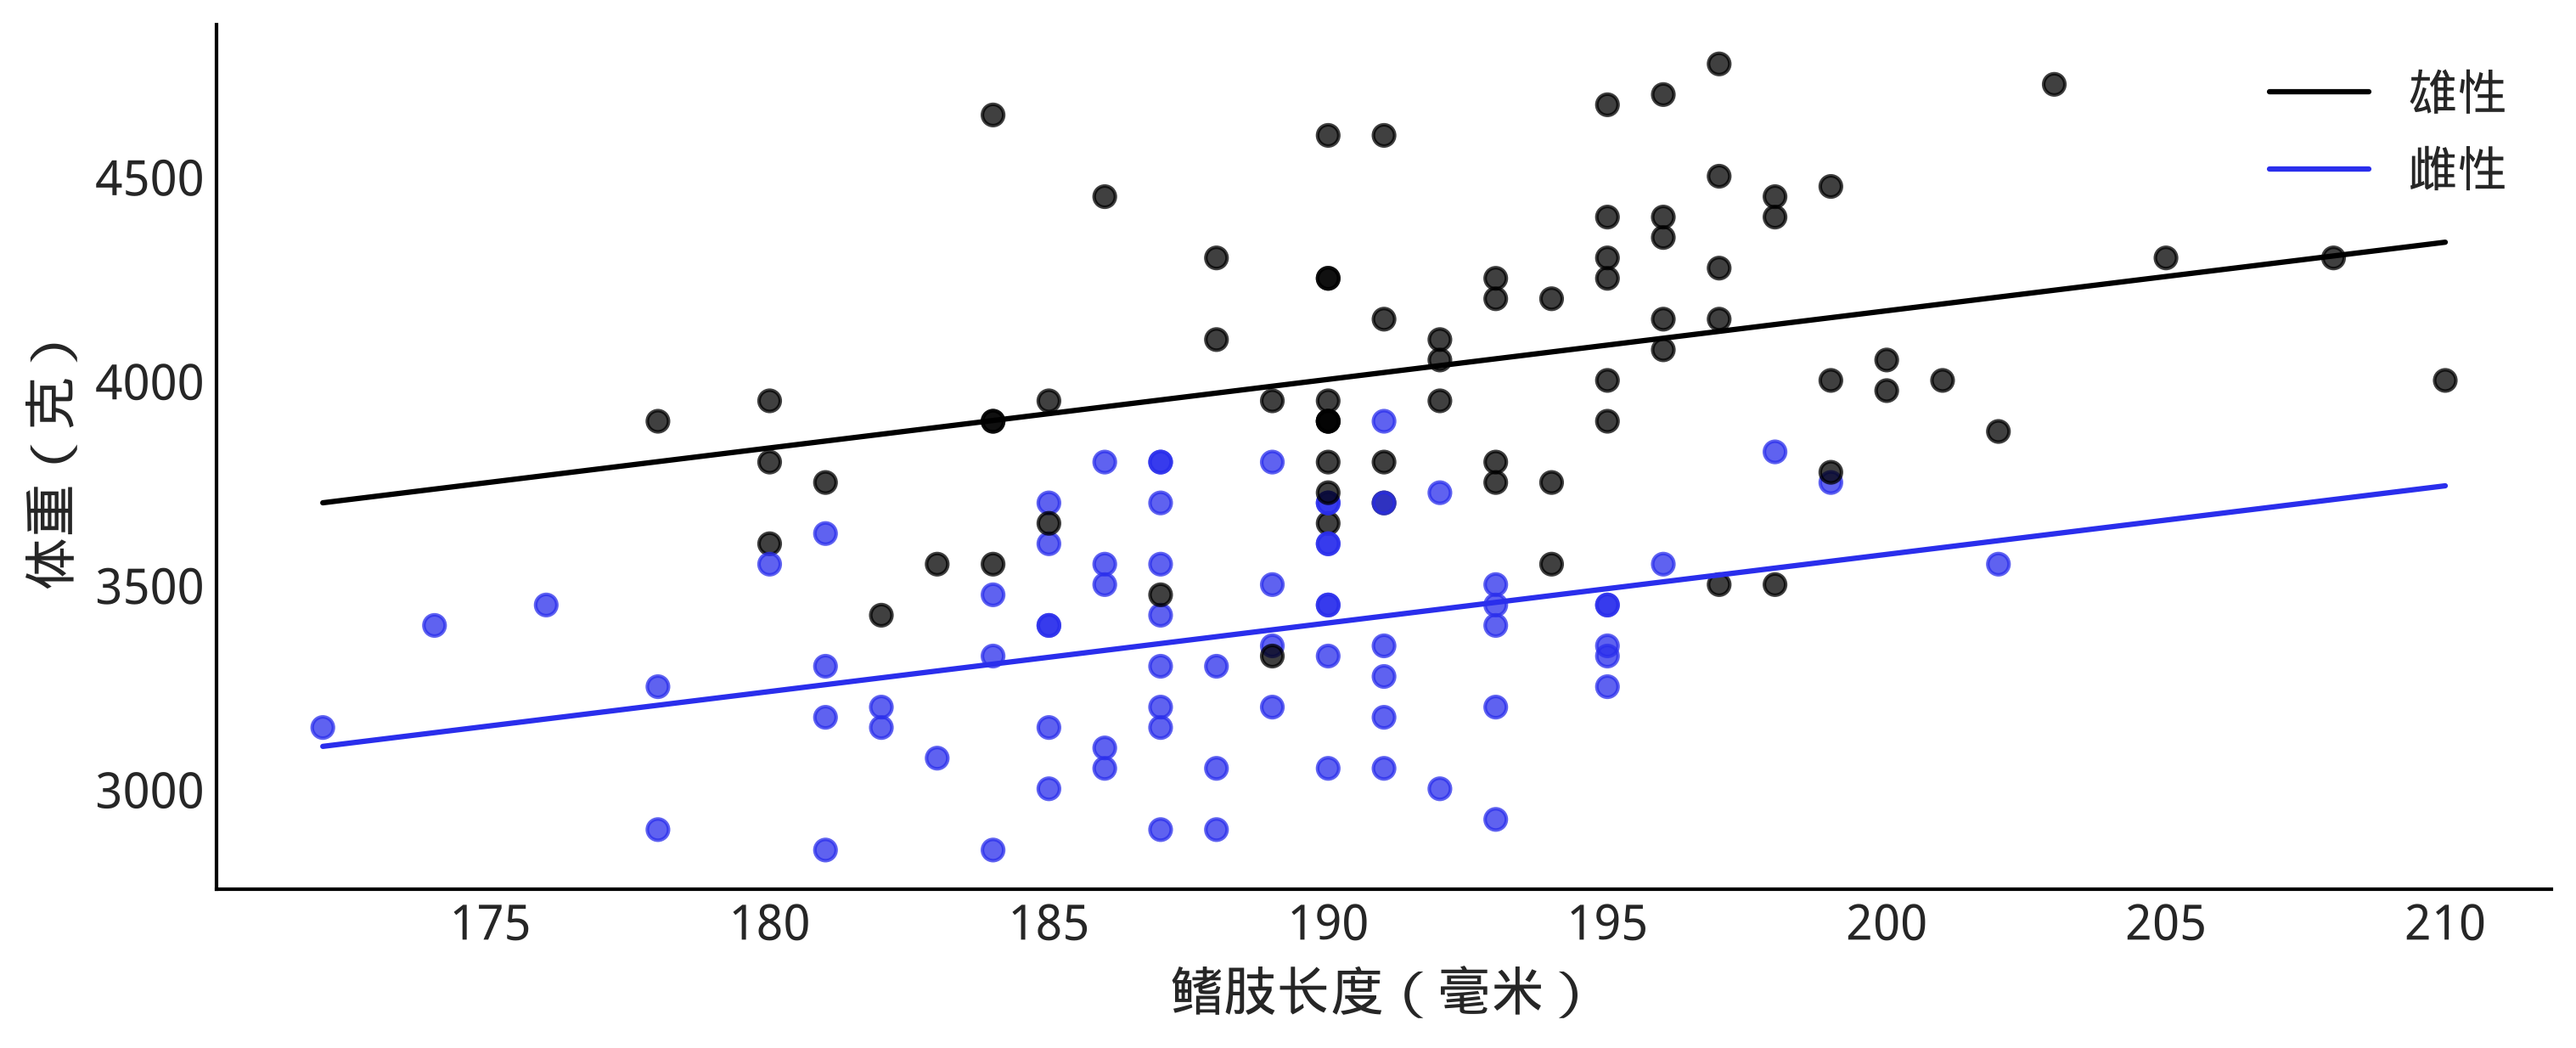

In [41]:
# 修正配色
fig, ax = plt.subplots(figsize=(10, 4))
alpha_1 = inf_data_penguin_mass_categorical.posterior["β_0"].mean().item()
beta_1 = inf_data_penguin_mass_categorical.posterior["β_1"].mean().item()
beta_2 = inf_data_penguin_mass_categorical.posterior["β_2"].mean().item()


flipper_length = np.linspace(adelie_flipper_length_obs.min(), adelie_flipper_length_obs.max(), 100)

mass_mean_male = alpha_1 + beta_1 * flipper_length
mass_mean_female = alpha_1 + beta_1 * flipper_length + beta_2

ax.plot(flipper_length, mass_mean_male, label="雄性")
ax.plot(flipper_length, mass_mean_female, c="C4", label="雌性")

point_colors = np.where(sex_obs == 0, "C0", "C4")
ax.scatter(
    adelie_flipper_length_obs,
    adelie_mass_obs,
    c=point_colors,
    alpha=0.75,
)

ax.set_xlabel("鳍肢长度（毫米）")
ax.set_ylabel("体重（克）")
ax.legend()

**图 3.14（锚点 `fig:Single_Species_Categorical_Regression`）** 同时使用鳍肢长度与性别的多元回归。平行线反映模型假设性别差异在各鳍肢长度处保持不变。

我们再一次比较三个模型的标准差,看看是否进一步降低了估计的不确定性。若“鳍肢长度与性别”
模型的 $\sigma$ 后验整体低于前两个模型,就说明额外信息解释了更多体重差异。不要依赖正文中写死
的某次抽样均值;应从本次运行的森林图、HDI 与诊断量共同判断这种下降是否稳定。

Text(0.5, 1.0, '模型间 σ 比较：94% HDI')

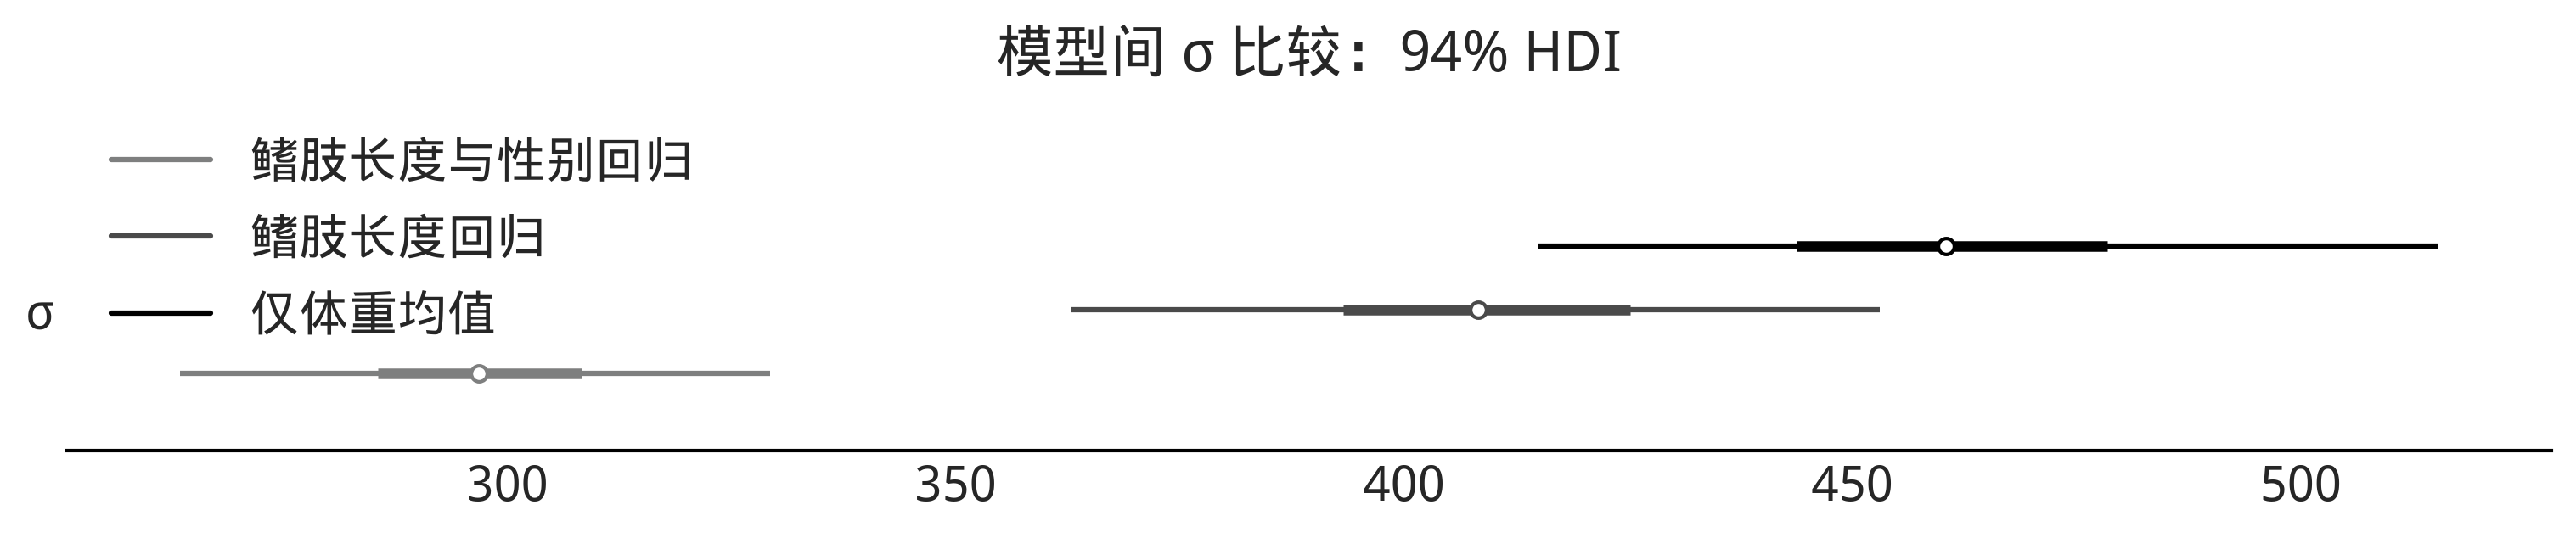

In [42]:
axes = az.plot_forest(
    [idata_adelie_mass, idata_adelie_flipper_regression, inf_data_penguin_mass_categorical],
    model_names=["仅体重均值", "鳍肢长度回归", "鳍肢长度与性别回归"],
    var_names=["σ"], combined=True, figsize=(10, 2))

axes[0].set_title("模型间 σ 比较：94% HDI")

**图 3.15（锚点 `fig:SingleSpecies_multipleRegression_Forest_Sigma_Comparison`）** 三个 Adelie 体重模型的 $\sigma$ 后验比较,用于评估新增协变量解释的残差变异。

> **协变量并非越多越好**:任何模型拟合算法都会去寻找信号——哪怕这个"信号"其实只是随机噪声。
> 这种现象被称为过拟合:算法在已见过的样本上能很好地把协变量映射到结果,却无法泛化到新的
> 观测。在线性回归中,我们可以通过生成 100 个随机协变量、拟合到一个随机模拟数据集上来演示
> 这一点 {cite:p}`mcelreath_2020`——即便协变量与目标毫无关系,我们也很可能被“线性模型表现
> 不错”这个假象误导。

### 反事实分析(Counterfactuals)

下面先定义并拟合一个 TFP 多元回归:它同时使用鳍肢长度、性别和喙长来估计体重。把模型构造函数
放在反事实解释之前,是为了让变量和后验样本在第一次出现时就有清楚的来源。下一段代码先定义模型,
再对已观测数据拟合;随后才会构造新的协变量取值并生成反事实预测。

In [43]:
def gen_jd_flipper_bill_sex(flipper_length, sex, bill_length, dtype=tf.float32):
    flipper_length, sex, bill_length = tf.nest.map_structure(
        lambda x: tf.constant(x, dtype),
        (flipper_length, sex, bill_length)
    )

    @tfd.JointDistributionCoroutine
    def jd_flipper_bill_sex():
        σ = yield root(
            tfd.HalfStudentT(df=100, loc=0, scale=2000, name="sigma"))
        β_0 = yield root(tfd.Normal(loc=0, scale=3000, name="beta_0"))
        β_1 = yield root(tfd.Normal(loc=0, scale=3000, name="beta_1"))
        β_2 = yield root(tfd.Normal(loc=0, scale=3000, name="beta_2"))
        β_3 = yield root(tfd.Normal(loc=0, scale=3000, name="beta_3"))
        μ = (β_0[..., None]
             + β_1[..., None] * flipper_length
             + β_2[..., None] * sex
             + β_3[..., None] * bill_length
            )
        mass = yield tfd.Independent(
            tfd.Normal(loc=μ, scale=σ[..., None]),
            reinterpreted_batch_ndims=1,
            name="mass")

    return jd_flipper_bill_sex

bill_length_obs = penguins.loc[adelie_mask, "bill_length_mm"]
jd_flipper_bill_sex = gen_jd_flipper_bill_sex(
    adelie_flipper_length_obs, sex_obs, bill_length_obs)

mcmc_samples_flipper_bill_sex, sampler_stats_flipper_bill_sex = run_mcmc(
    TFP_DRAWS,
    jd_flipper_bill_sex,
    n_chains=CHAINS,
    num_adaptation_steps=TFP_ADAPT,
    seed=tf.constant([RANDOM_SEED, 3], tf.int32),
    mass=tf.constant(adelie_mass_obs, tf.float32),
)

In [44]:
idata_model_penguin_flipper_bill_sex = az.from_dict(
    posterior={
        k: np.swapaxes(v, 1, 0)
        for k, v in mcmc_samples_flipper_bill_sex._asdict().items()
    },
    sample_stats={
        k: np.swapaxes(sampler_stats_flipper_bill_sex[k], 1, 0)
        for k in ["target_log_prob", "diverging", "accept_ratio", "n_steps"]
    },
)

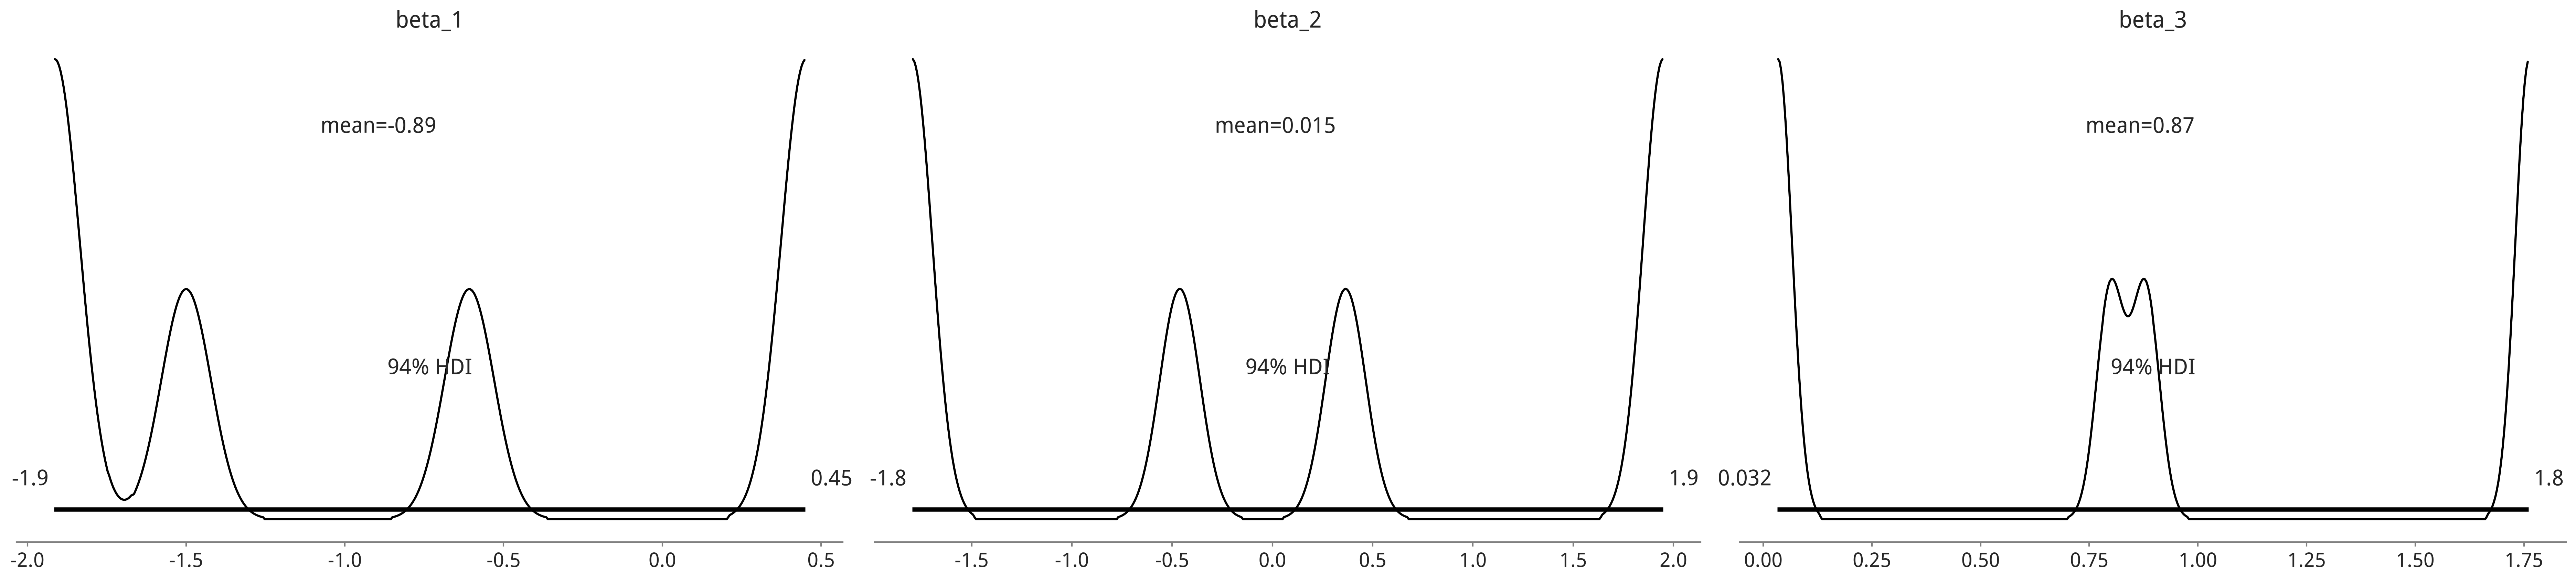

In [45]:
az.plot_posterior(idata_model_penguin_flipper_bill_sex, var_names=["beta_1", "beta_2", "beta_3"]);

In [46]:
az.summary(idata_model_penguin_flipper_bill_sex, var_names=["beta_1", "beta_2", "beta_3", "sigma"])

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:595: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:595: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:595: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:595: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
/home/ai/Projects/BookCode_Edition1/.venv/li

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_1,-0.894,0.908,-1.916,0.450,0.452,0.183,4.0,4.0,NaN
beta_2,0.015,1.358,-1.797,1.949,0.676,0.308,4.0,4.0,NaN
beta_3,0.867,0.612,0.032,1.761,0.305,0.152,4.0,4.0,NaN
sigma,1.819,1.423,0.283,3.947,0.709,0.287,4.0,4.0,NaN


前面我们用单协变量模型拟合出的参数做过预测,通过改变鳍肢长度这一个协变量,得到了固定鳍肢长度
下的体重估计。在多元回归里,我们也可以做类似的事:固定除某一个协变量之外的所有协变量,观察
这一个协变量的变化会如何改变预期结果——这种分析叫做**反事实分析(counterfactual
analysis)**。上面的 TFP 模型已加入喙长(bill length),新增系数 `beta_3` 对应这一协变量。推断
完成后,我们可以模拟"虚构鳍肢长度"下企鹅的体重——固定性别为雄性,喙长固定为数据集的观测均值。
由于我们把模型生成过程包在了一个 Python 函数里(函数式编程风格),可以很方便地用新的预测变量
做条件化,这对反事实分析很有用。

In [47]:
mean_flipper_length = penguins.loc[adelie_mask, "flipper_length_mm"].mean()
# 反事实维度设为 21,方便刚好取到均值这个点
counterfactual_flipper_lengths = np.linspace(
    mean_flipper_length-20, mean_flipper_length+20, 21)
sex_male_indicator = np.zeros_like(counterfactual_flipper_lengths)
mean_bill_length = np.ones_like(
    counterfactual_flipper_lengths) * bill_length_obs.mean()

jd_flipper_bill_sex_counterfactual = gen_jd_flipper_bill_sex(
    counterfactual_flipper_lengths, sex_male_indicator, mean_bill_length)
ppc_samples = jd_flipper_bill_sex_counterfactual.sample(
    value=mcmc_samples_flipper_bill_sex,
    seed=tf.constant([RANDOM_SEED, 4], tf.int32),
)
estimated_mass = ppc_samples[-1].numpy().reshape(-1, 21)

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


Text(0, 0.5, '估计体重（克）')

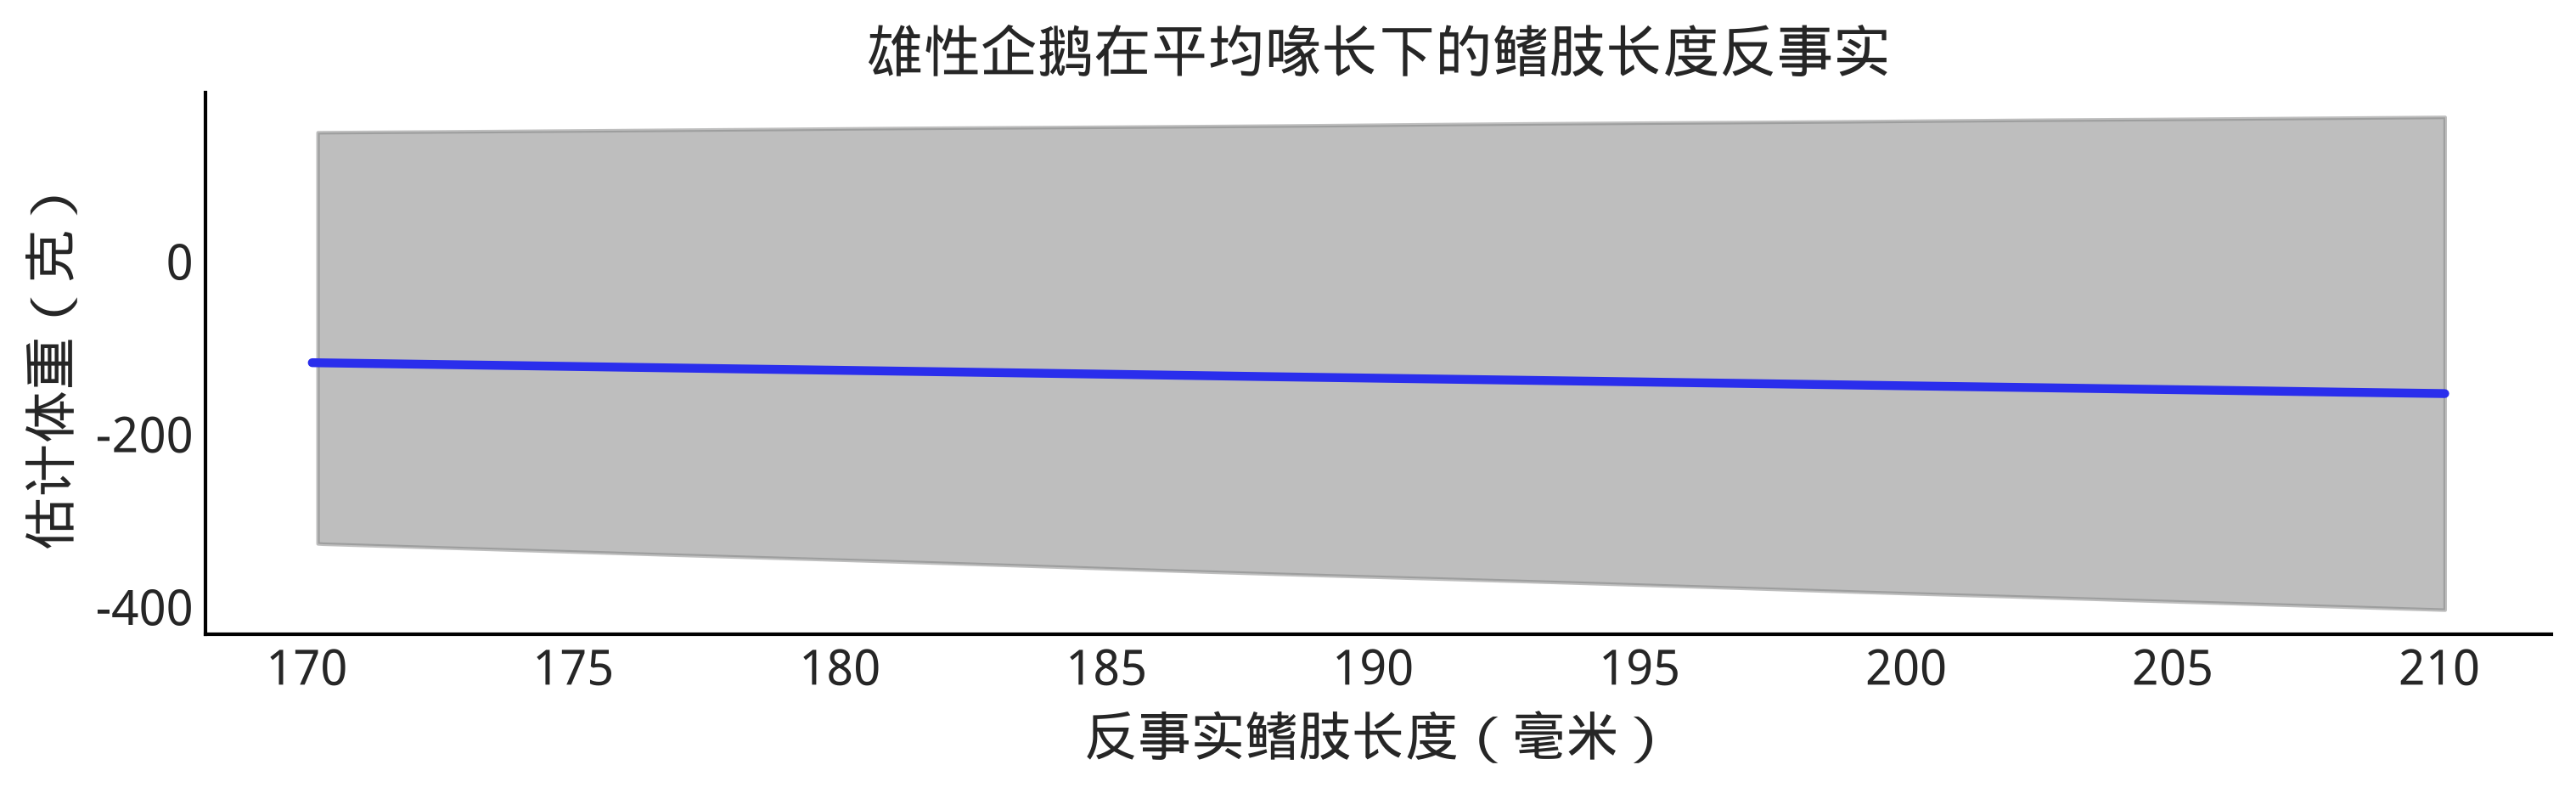

In [48]:
_, ax = plt.subplots(figsize=(10, 3))
az.plot_hdi(
    counterfactual_flipper_lengths,
    estimated_mass,
    color="C2",
    plot_kwargs={"ls": "--"},
    ax=ax,
)
ax.plot(
    counterfactual_flipper_lengths,
    estimated_mass.mean(axis=0),
    lw=2.5,
    c="C4",
)
ax.set_title("雄性企鹅在平均喙长下的鳍肢长度反事实")
ax.set_xlabel("反事实鳍肢长度（毫米）")
ax.set_ylabel("估计体重（克）")

**图 3.16（锚点 `fig:LinearCounterfactual`）** 固定性别与喙长后改变鳍肢长度得到的反事实体重估计;阴影表示后验不确定性。

沿用 McElreath 的反事实图思路 {cite:p}`mcelreath_2020`,上图评估的是一种与
已观测数据(即"事实")相反的情形——换句话说,我们在评估那些从未发生过的情形。反事实图最简单
的用法,就是像我们刚才做的那样,调整某个协变量,观察结果——这让我们能够探索原本难以触及的
"假如……会怎样"场景 [^6]。但我们在解读这类"戏法"时必须保持谨慎。第一个陷阱是:反事实取值
可能根本不可能存在——比如现实中或许根本不存在鳍肢长度超过 1500 毫米的企鹅,但模型依然会
欣然给出这只"虚构企鹅"的估计。第二个陷阱更隐蔽:我们假设可以独立地改变每个协变量,但现实中
未必如此——比如企鹅鳍肢变长时,喙长可能也会随之变化。反事实分析的强大之处在于,它能让我们
探索那些没有发生过、或者至少我们没有观测到的结果。但它也很容易让我们对那些*永远不会*发生的
情形生成估计——模型本身分不清这两者的区别,分辨这一点是建模者的责任。

> **相关性与因果性**:在解读线性回归时,很容易脱口而出"$X$ 增加**导致**了 $Y$ 增加"。但这
> 未必成立——事实上,仅凭一个(线性)回归本身,是无法做出因果论断的。数学上,线性模型把两个
> (或更多)变量关联在一起,但这种关联未必是因果的。比如,给植物浇更多水确实(而且是因果性地)
> 会促进植物生长(至少在一定范围内),但没有什么能阻止我们在模型中把这个关系反过来,用植物
> 的生长情况去估计降雨量——即便植物生长本身并不会导致降雨 [^7]。统计学中的因果推断
> (Causal Inference)这一分支,正是研究如何在随机实验或观察性研究的语境下,得出因果论断
> 所需的工具和流程(第 7 章会简要讨论)。

## 广义线性模型

目前为止讨论的所有线性模型,都假设观测值在给定条件下服从高斯分布,这在很多场景下都行得通。但
有时我们想用其他分布——比如建模被限制在某个区间内的量,像 $[0, 1]$ 区间内的概率,或者自然数
$\{1, 2, 3, \dots \}$ 这样的计数事件。要做到这一点,我们把线性函数 $\mathbf{X} \mathit{\beta}$
用一个反连接函数(inverse link function)[^8] $\phi$ 做变换:

$$
\begin{split}
\mu =& \phi(\mathbf{X} \beta) \\
Y \sim& \Psi (\mu, \theta)
\end{split}
$$

**式 (3.5)（锚点 `eq:generalized_linear_model`）**

其中 $\Psi$ 是由 $\mu$、$\theta$ 参数化的某个分布,代表数据的似然。

反连接函数的具体作用,是把取值范围在整个实数轴 $(-\infty, \infty)$ 上的输出,映射到参数所
限定的那个受限区间。换句话说,反连接函数正是把线性模型推广到更多模型架构所需要的那个"戏法"。
从这个意义上说,我们保留的是**线性预测子** $\eta=\mathbf{X}\beta$:参数仍以线性方式进入
$\eta$。但响应分布的条件均值通常是 $\mu=\phi(\eta)$,在原始响应尺度上一般不再是协变量的线性
函数。正是这个变换让广义线性模型能处理概率、计数等不同取值范围 [^9]。

### 逻辑回归

最常见的广义线性模型之一就是逻辑回归(logistic regression)。它特别适合为"只有两种可能结果"
的数据建模——我们观测到的要么是这个,要么是那个。抛硬币正反面的概率是最典型的教科书例子。更
“接地气”的例子包括:制造业里出现缺陷的概率、癌症检测呈阳性或阴性、火箭发射失败的概率
{cite:p}`davidson-pilon_2015` 等等。
在逻辑回归中,反连接函数不出所料地被称为逻辑函数(logistic function),它把
$(-\infty, \infty)$ 映射到 $(0,1)$ 区间。这非常方便,因为这样我们就能把线性函数映射到"概率
参数"所要求的取值范围——按照定义,概率必须落在 0 到 1 之间。

$$
p = \frac{1}{1+e^{-\mathbf{X}\beta}}
$$

**式 (3.6)（锚点 `eq:logistic`）**

有了逻辑回归,我们就能用线性模型来估计某个事件的概率。有时候,我们想做的不是估计概率,而是
**分类**——即给定数据,预测一个具体的类别。为此我们需要把 $(-\infty, \infty)$ 区间上的连续
预测,转换成 0 到 1 之间的取值,再借助一个决策边界,把预测归到 $\{0,1\}$ 这个集合里。假设我们
把决策边界设在概率 0.5 处。对一个只有截距和一个协变量的模型,有:

$$
\begin{split}
0.5 &= logistic(\beta_{0} + \beta_{1}*x) \\
logit(0.5) &= \beta_{0} + \beta_{1}*x \\
0 &= \beta_{0} + \beta_{1}*x \\
x &= -\frac{\beta_{0}}{\beta_{1}} \\
\end{split}
$$

**式 (3.7)（锚点 `decision_boundary`）**

注意 $logit$ 是 $logistic$ 的反函数。也就是说,一旦拟合出逻辑模型,我们就可以用系数
$\beta_0$、$\beta_1$,直接算出使得类别概率大于 0.5 的 $x$ 取值。先画出逻辑函数本身,可以直观
看到它怎样把整条实数轴压缩到 $(0,1)$。

(-0.02, 1.02)

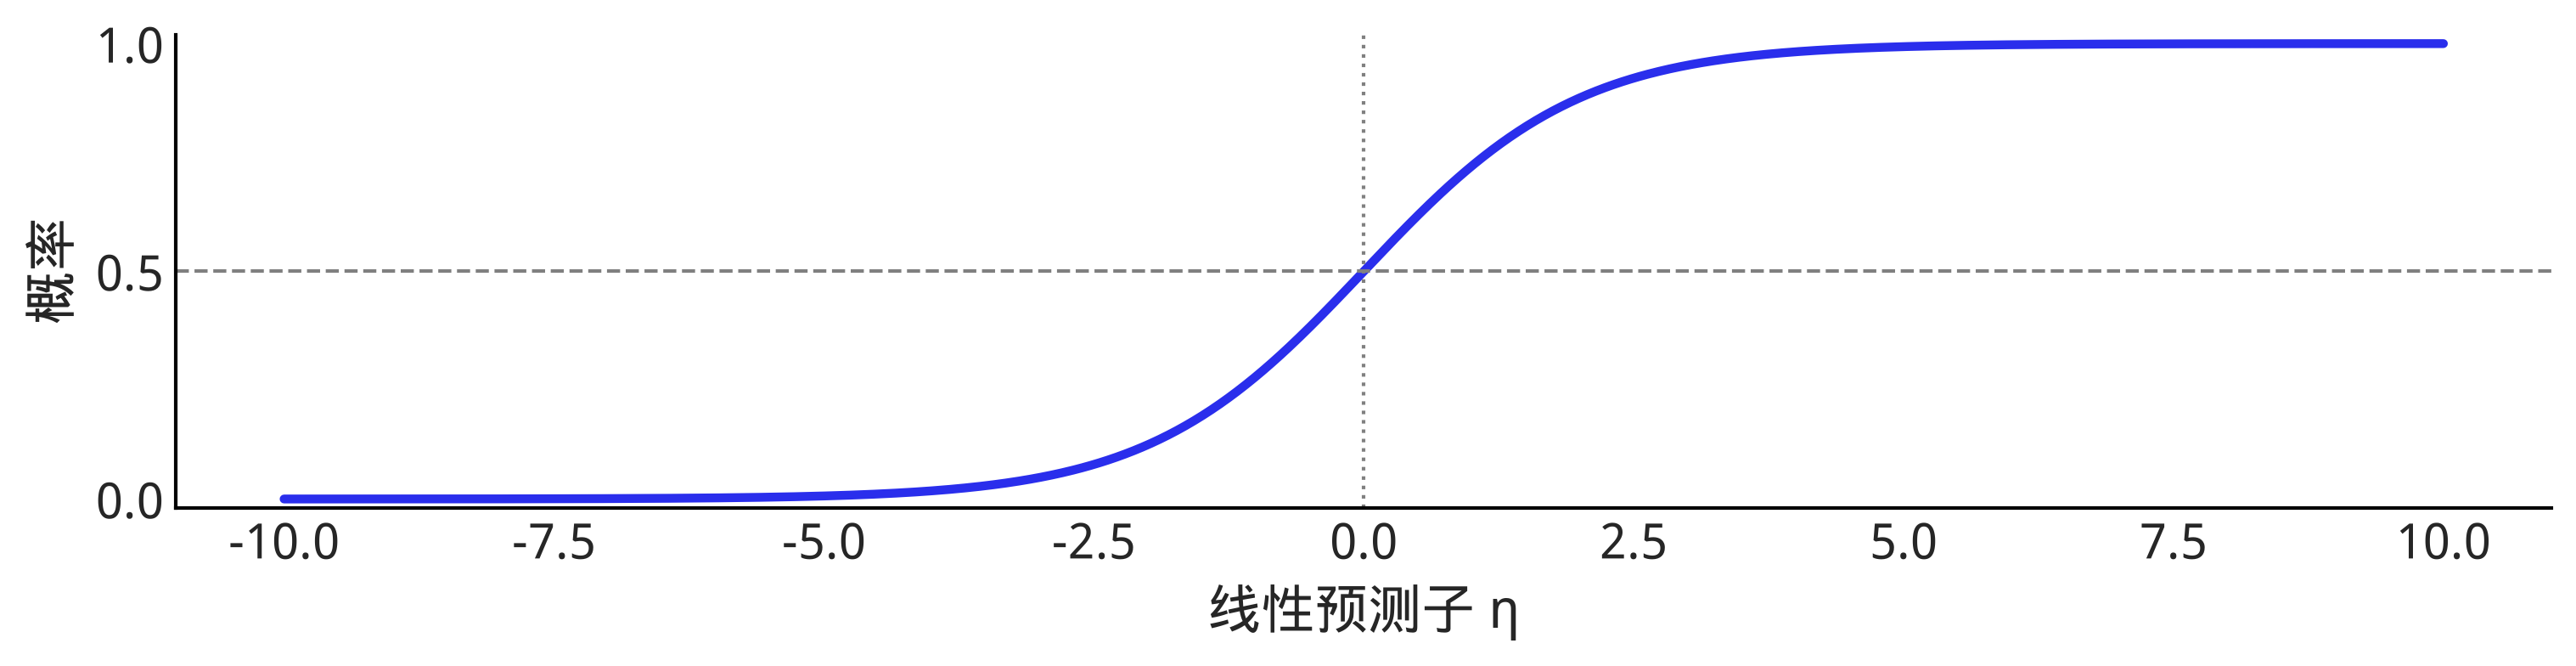

In [49]:
logit_grid = np.linspace(-10, 10, 1000)
probability_grid = special.expit(logit_grid)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(logit_grid, probability_grid, color="C4", lw=2.5)
ax.axhline(0.5, color="0.5", ls="--", lw=1)
ax.axvline(0, color="0.5", ls=":", lw=1)
ax.set_xlabel("线性预测子 η")
ax.set_ylabel("概率")
ax.set_ylim(-0.02, 1.02)

**图 3.17（锚点 `fig:Logistic`）** 逻辑函数把实数线性预测子压缩到 $(0,1)$ 概率区间。

### 给企鹅分类

前面几节,我们用企鹅的性别和喙长来估计体重。现在换个问法:如果给定一只企鹅的体重和喙长,
能否预测它的物种?我们用 Adelie 和 Chinstrap 两个物种,把问题变成一个二分类任务。像之前一样,
我们先从一个只有一个协变量(喙长)的简单模型入手。下面始终把 Chinstrap 明确编码为成功类别 1,
因此 $\theta=P(\mathrm{Chinstrap})$:

In [50]:
species_row_mask = penguins["species"].isin(["Adelie", "Chinstrap"])
bill_length_obs = penguins.loc[species_row_mask, "bill_length_mm"].to_numpy()
species = pd.Categorical(
    penguins.loc[species_row_mask, "species"],
    categories=["Adelie", "Chinstrap"],
)
chinstrap_observed = species.codes

bill_length_center = bill_length_obs.mean()
bill_length_scale = bill_length_obs.std()
bill_length_z = (bill_length_obs - bill_length_center) / bill_length_scale

with pm.Model() as model_logistic_penguins_bill_length:
    β_0 = pm.Normal("β_0", mu=0, sigma=2.5)
    β_1 = pm.Normal("β_1", mu=0, sigma=2.5)

    η = β_0 + β_1 * bill_length_z
    θ = pm.Deterministic("θ", pm.math.sigmoid(η))

    # 在标准化尺度上求阈值,再转换回毫米,便于画决策边界。
    bd_z = -β_0 / β_1
    bd = pm.Deterministic(
        "bd", bill_length_center + bill_length_scale * bd_z
    )

    yl = pm.Bernoulli("yl", p=θ, observed=chinstrap_observed)

    idata_logistic_penguins_bill_length = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED,
        idata_kwargs={"log_likelihood": True})
    idata_logistic_penguins_bill_length.extend(pm.sample_prior_predictive(
        draws=PRIOR_SAMPLES, random_seed=RANDOM_SEED))
    idata_logistic_penguins_bill_length.extend(pm.sample_posterior_predictive(
        idata_logistic_penguins_bill_length, random_seed=RANDOM_SEED))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [β_0, β_1]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 248 seconds.


Sampling: [yl, β_0, β_1]


Sampling: [yl]


Output()

在广义线性模型中,"参数先验 → 响应变量"这条映射链有时会更难直观理解。我们可以借助先验预测
样本,帮助我们可视化预期的观测结果。在这个企鹅分类的例子里,在看到任何数据之前,我们认为
"不论喙长如何,Chinstrap 企鹅和 Adelie 企鹅出现的概率应该差不多"是合理的假设。我们可以用
先验预测分布,double-check 一下这个建模意图是否被先验和模型正确地表达了出来。下图显示,在
看到数据之前,两个类别大致均衡——这正是我们期望看到的结果。

Text(0.5, 0, '先验预测类别')

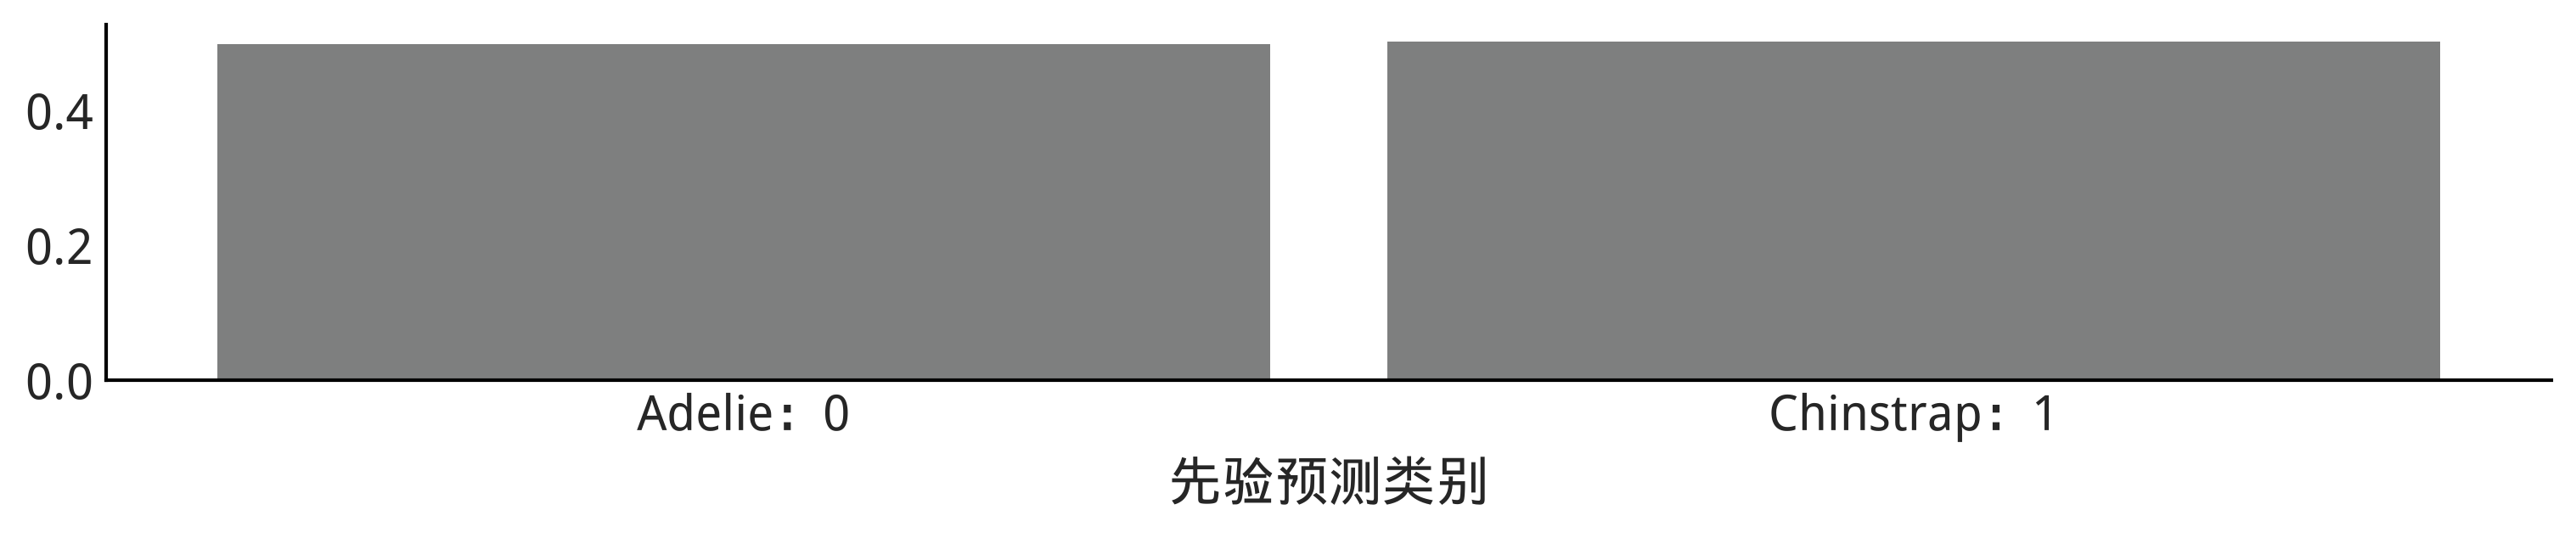

In [51]:
_, ax = plt.subplots(figsize=(10, 2))
az.plot_dist(
    idata_logistic_penguins_bill_length.prior_predictive["yl"],
    color="C2",
    ax=ax,
)
ax.set_xticks([0, 1], labels=["Adelie：0", "Chinstrap：1"])
ax.set_xlabel("先验预测类别")

**图 3.18（锚点 `fig:Prior_Predictive_Logistic`）** 喙长逻辑回归的先验预测类别。样本数由当前执行配置的 `PRIOR_SAMPLES` 决定。

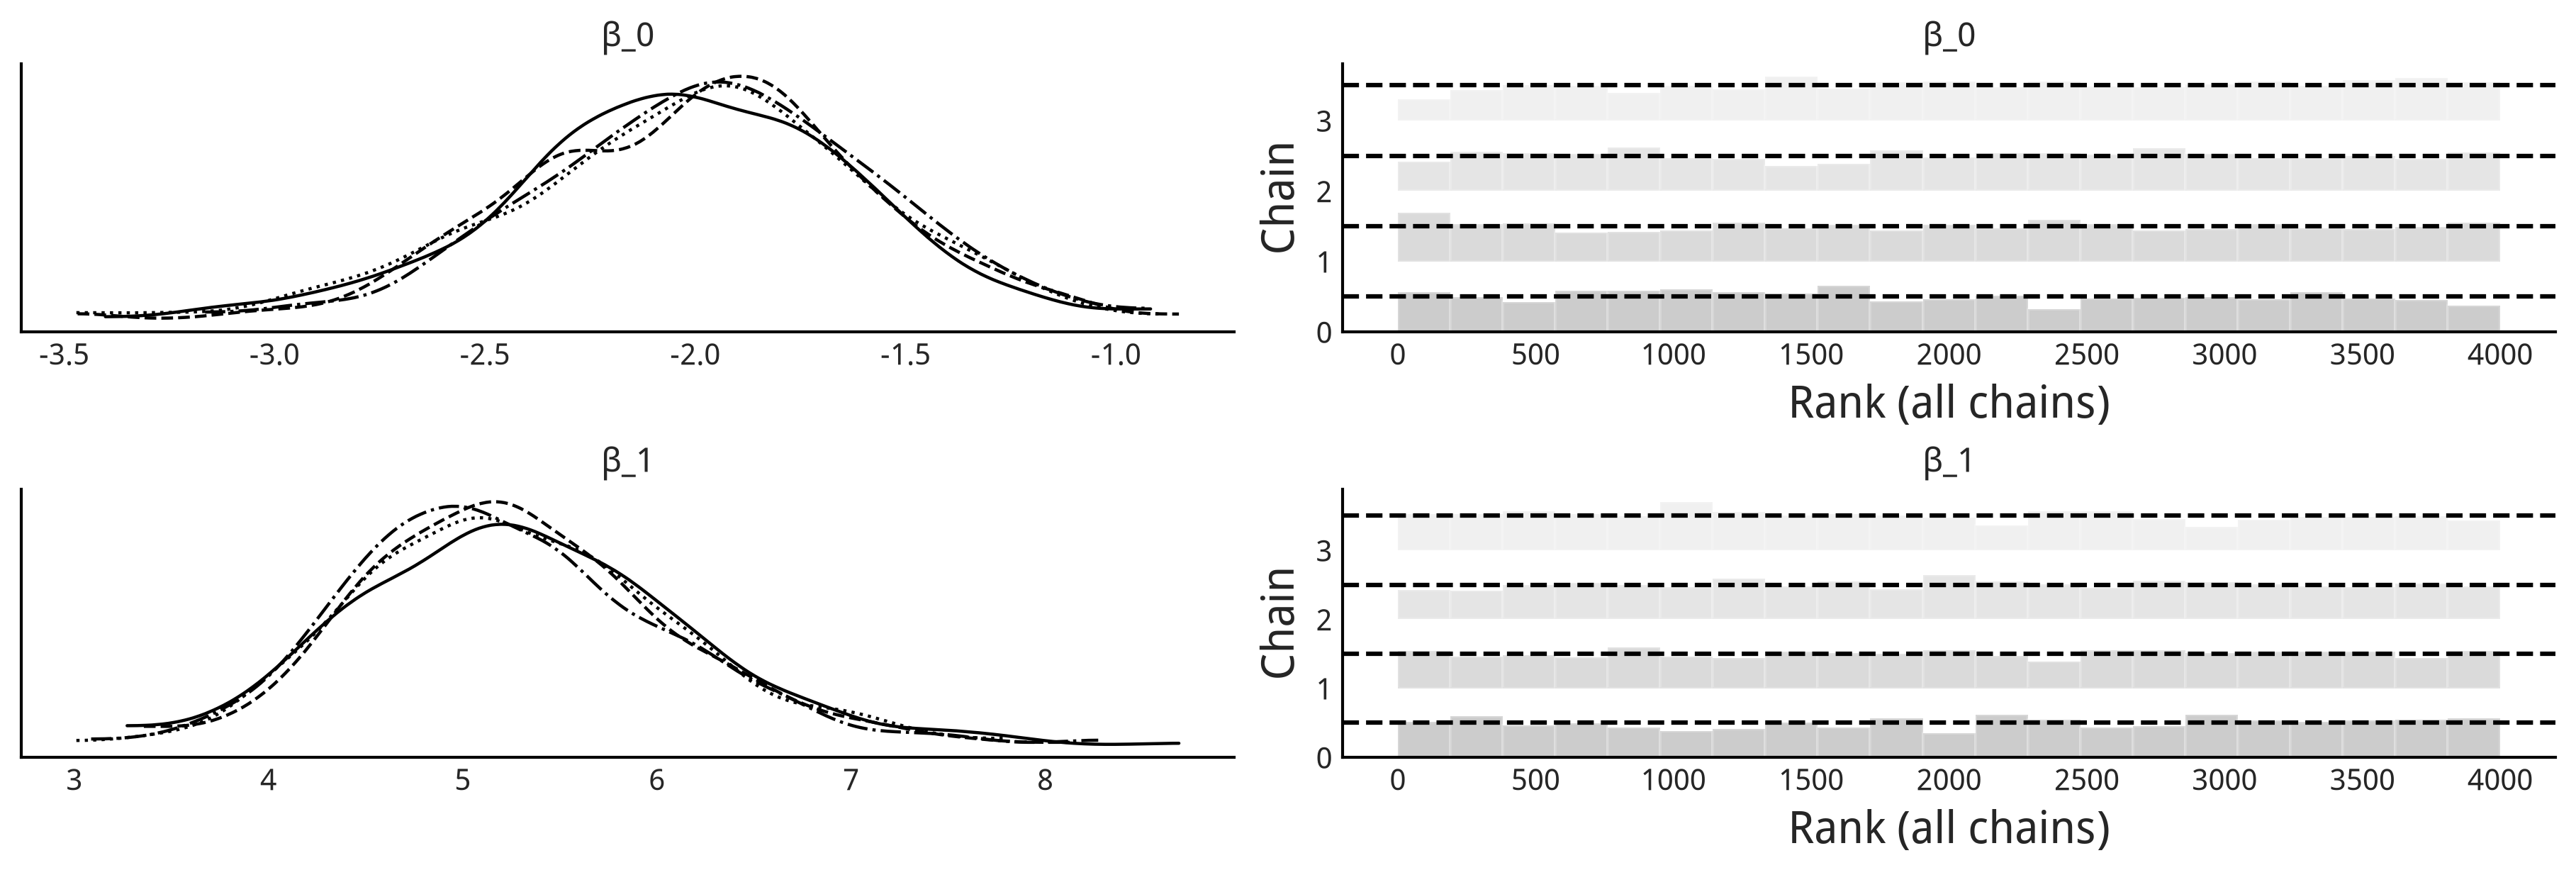

In [52]:
az.plot_trace(idata_logistic_penguins_bill_length, var_names=["β_0", "β_1"], kind="rank_bars");

拟合出参数之后,我们可以用 `az.summary(.)` 检查系数。这里 $\beta_1$ 表示喙长增加一个样本
标准差时,成为 Chinstrap 的**对数几率**变化量。若其 HDI 位于 0 以上,就说明喙长越大时
$P(\mathrm{Chinstrap})$ 越高。决策边界已转换回毫米尺度;具体点估计与区间应从本次运行结果读取,
而不写死某一次抽样的数值。把回归结果画出来会更直观:逻辑曲线从 Adelie 一侧的低概率变化到
Chinstrap 一侧的高概率,决策边界也与两组观测的重叠区域相符。

In [53]:
az.summary(idata_logistic_penguins_bill_length, var_names=["β_0", "β_1"], kind="stats")

,mean,sd,hdi_3%,hdi_97%
β_0,-2.005,0.404,-2.732,-1.222
β_1,5.267,0.799,3.835,6.813


**表 3.3（锚点 `table:logistic_penguins_bill_length`）** 标准化喙长逻辑回归的系数汇总。

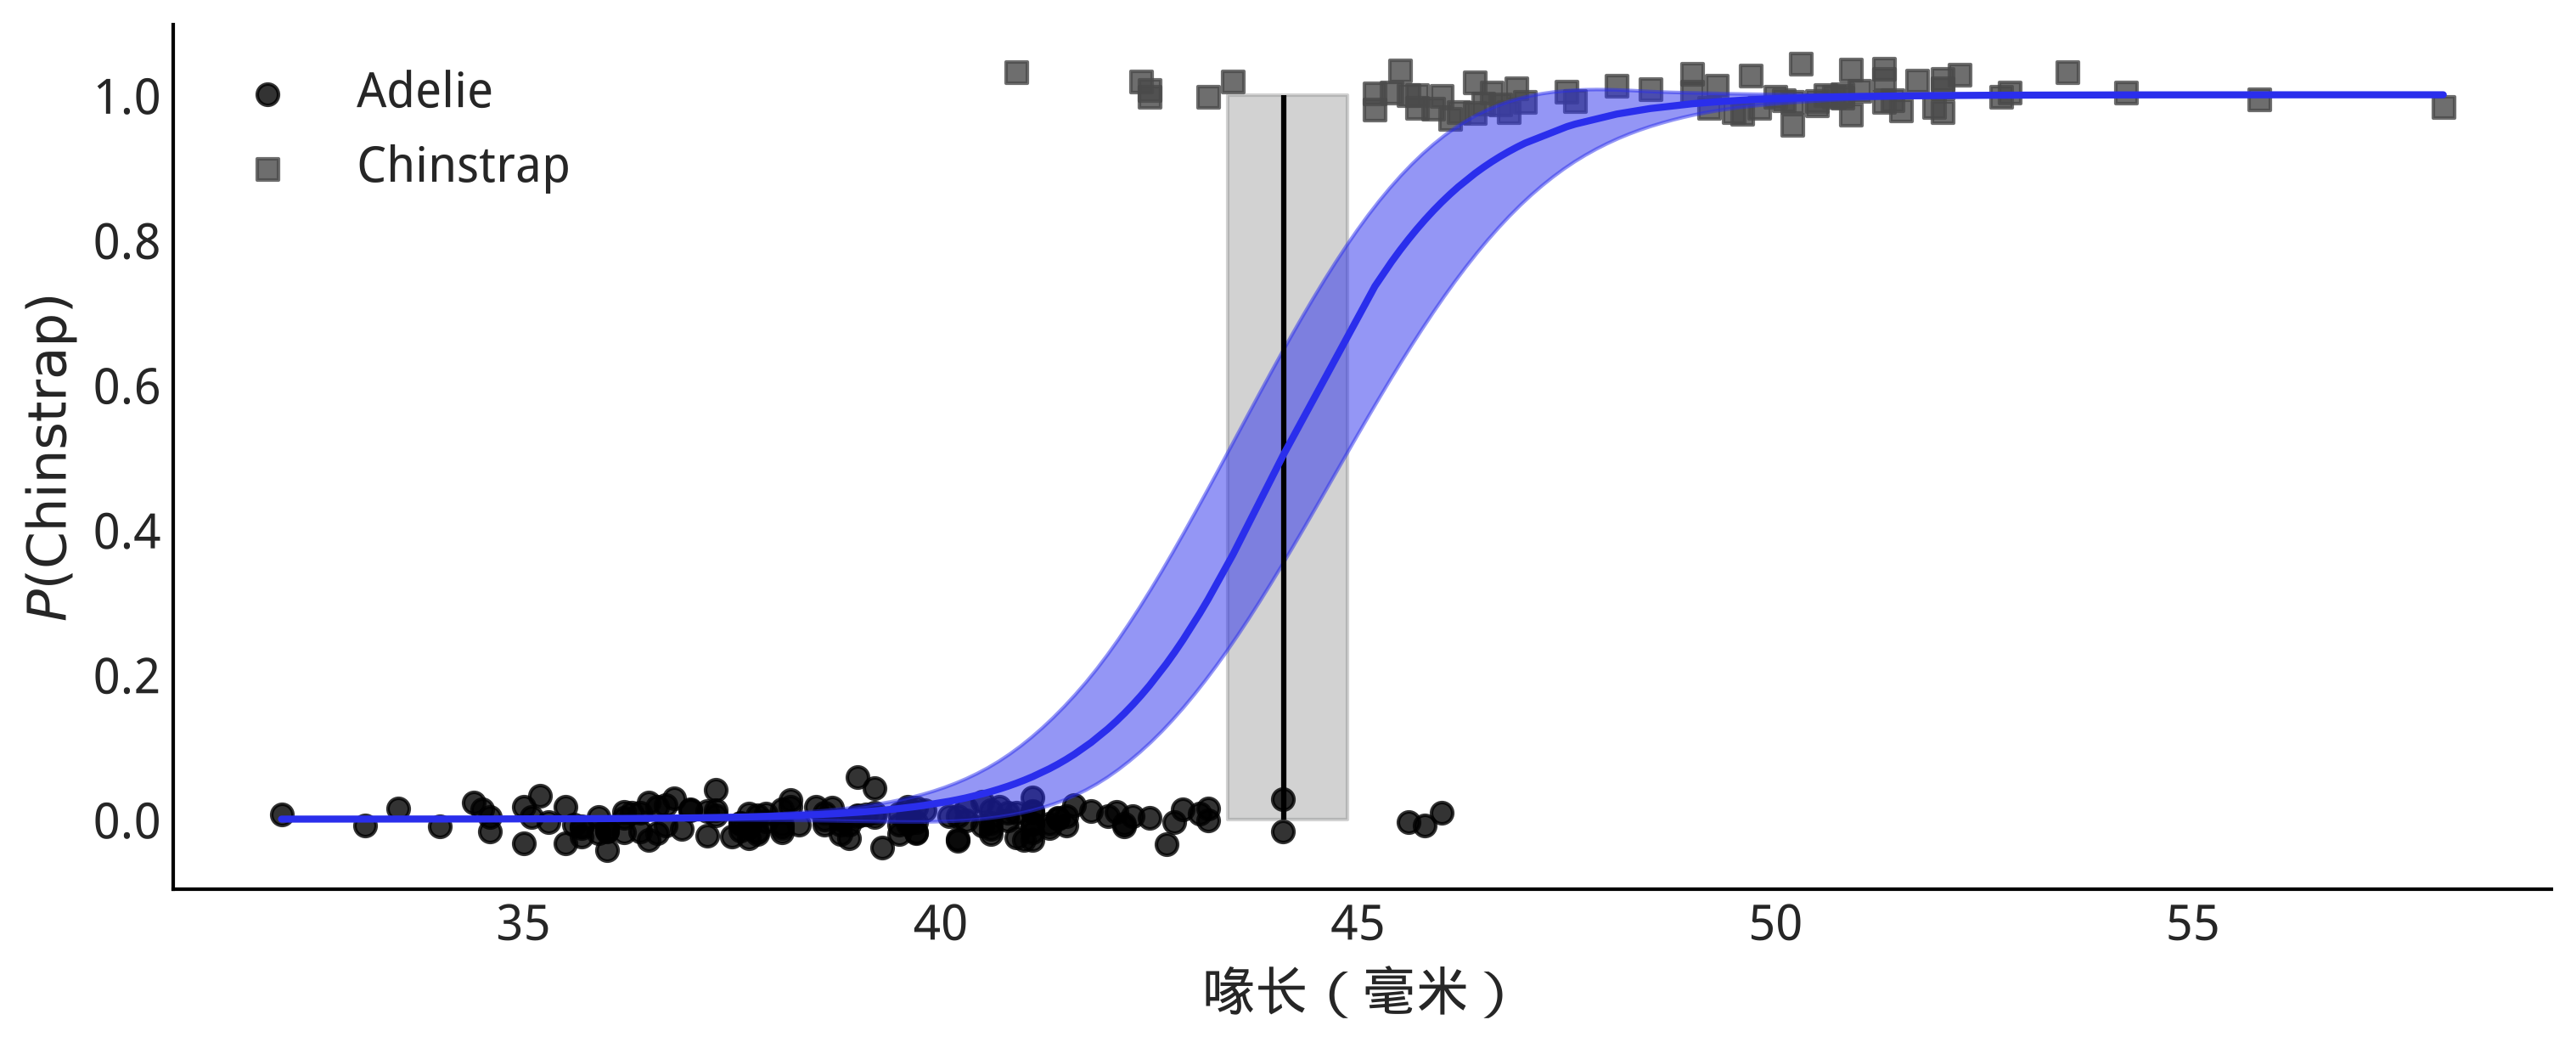

In [54]:
fig, ax = plt.subplots(figsize=(10, 4))

theta = idata_logistic_penguins_bill_length.posterior["θ"].mean(("chain", "draw"))
bill_curve_order = np.argsort(bill_length_obs)

# 决策边界及其 94% HDI。
boundary_mean = idata_logistic_penguins_bill_length.posterior["bd"].mean().item()
boundary_hdi = az.hdi(
    idata_logistic_penguins_bill_length.posterior["bd"].values.flatten()
)
ax.vlines(boundary_mean, 0, 1, color="k", lw=1.5)
ax.fill_betweenx([0, 1], boundary_hdi[0], boundary_hdi[1], color="C2", alpha=0.35)

for i, (label, marker) in enumerate(zip(species.categories, ("o", "s"))):
    class_mask = species.codes == i
    jittered_class = PLOT_RNG.normal(i, 0.02, size=class_mask.sum())
    ax.scatter(
        bill_length_obs[class_mask],
        jittered_class,
        marker=marker,
        label=label,
        alpha=0.8,
    )

az.plot_hdi(
    bill_length_obs,
    idata_logistic_penguins_bill_length.posterior["θ"].values,
    color="C4",
    ax=ax,
    plot_kwargs={"zorder": 10},
)
ax.plot(
    bill_length_obs[bill_curve_order],
    theta[bill_curve_order],
    color="C4",
    lw=2,
    zorder=10,
)

ax.set_xlabel("喙长（毫米）")
ax.set_ylabel(r"$P(\mathrm{Chinstrap})$")
ax.legend()

**图 3.19（锚点 `fig:Logistic_bill_length`）** 喙长逻辑回归的概率曲线、观测类别与决策边界;成功类别是 Chinstrap。

我们再换个思路,依然是分类企鹅,这次改用体重作为协变量:

In [55]:
mass_obs = penguins.loc[species_row_mask, "body_mass_g"].to_numpy()
mass_center = mass_obs.mean()
mass_scale = mass_obs.std()
mass_z = (mass_obs - mass_center) / mass_scale

with pm.Model() as model_logistic_penguins_mass:
    β_0 = pm.Normal("β_0", mu=0, sigma=2.5)
    β_1 = pm.Normal("β_1", mu=0, sigma=2.5)

    η = β_0 + β_1 * mass_z
    θ = pm.Deterministic("θ", pm.math.sigmoid(η))
    bd_z = -β_0 / β_1
    bd = pm.Deterministic("bd", mass_center + mass_scale * bd_z)

    yl = pm.Bernoulli("yl", p=θ, observed=chinstrap_observed)

    idata_logistic_penguins_mass = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        target_accept=.9, random_seed=RANDOM_SEED,
        idata_kwargs={"log_likelihood": True})
    idata_logistic_penguins_mass.extend(pm.sample_posterior_predictive(
        idata_logistic_penguins_mass, random_seed=RANDOM_SEED))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [β_0, β_1]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 234 seconds.


Sampling: [yl]


Output()

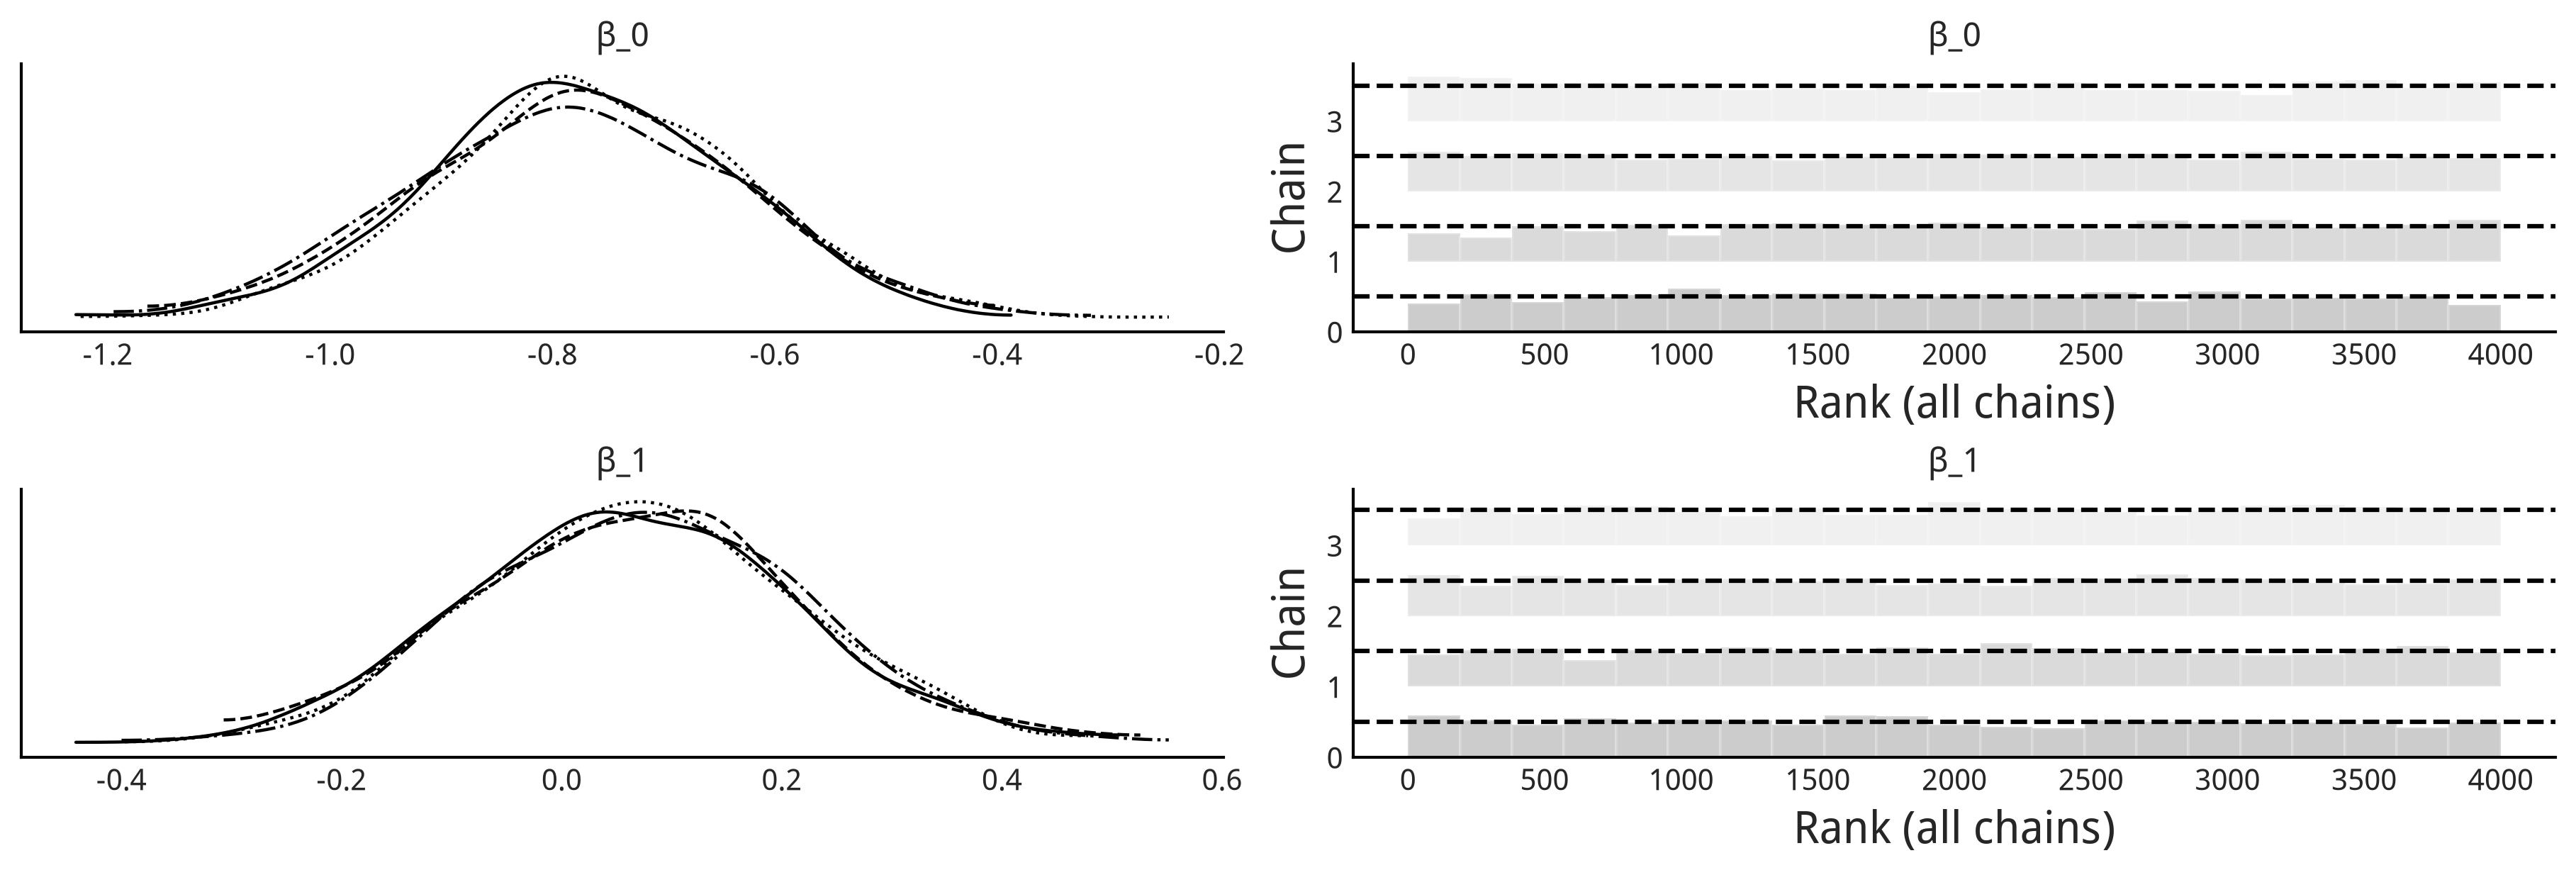

In [56]:
az.plot_trace(idata_logistic_penguins_mass, var_names=["β_0", "β_1"], kind="rank_bars");

体重已经标准化,所以 $\beta_1$ 表示体重增加一个样本标准差时,成为 Chinstrap 的对数几率变化。
若其后验仍较宽或包含 0,说明单凭体重没有足够信息稳定地区分这两个类别。这不一定是坏事,只是
模型在告诉我们:两物种的体重分布重叠较多。把数据和逻辑回归拟合结果画出来后会更加明显。

In [57]:
az.summary(idata_logistic_penguins_mass, var_names=["β_0", "β_1", "bd"], kind="stats")

,mean,sd,hdi_3%,hdi_97%
β_0,-0.773,0.142,-1.036,-0.501
β_1,0.066,0.149,-0.195,0.367
bd,7391.015,89039.488,-20884.797,29680.781


**表 3.4（锚点 `table:logistic_penguins_mass`）** 标准化体重逻辑回归的系数与决策边界汇总。

In [58]:
species.codes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int8)

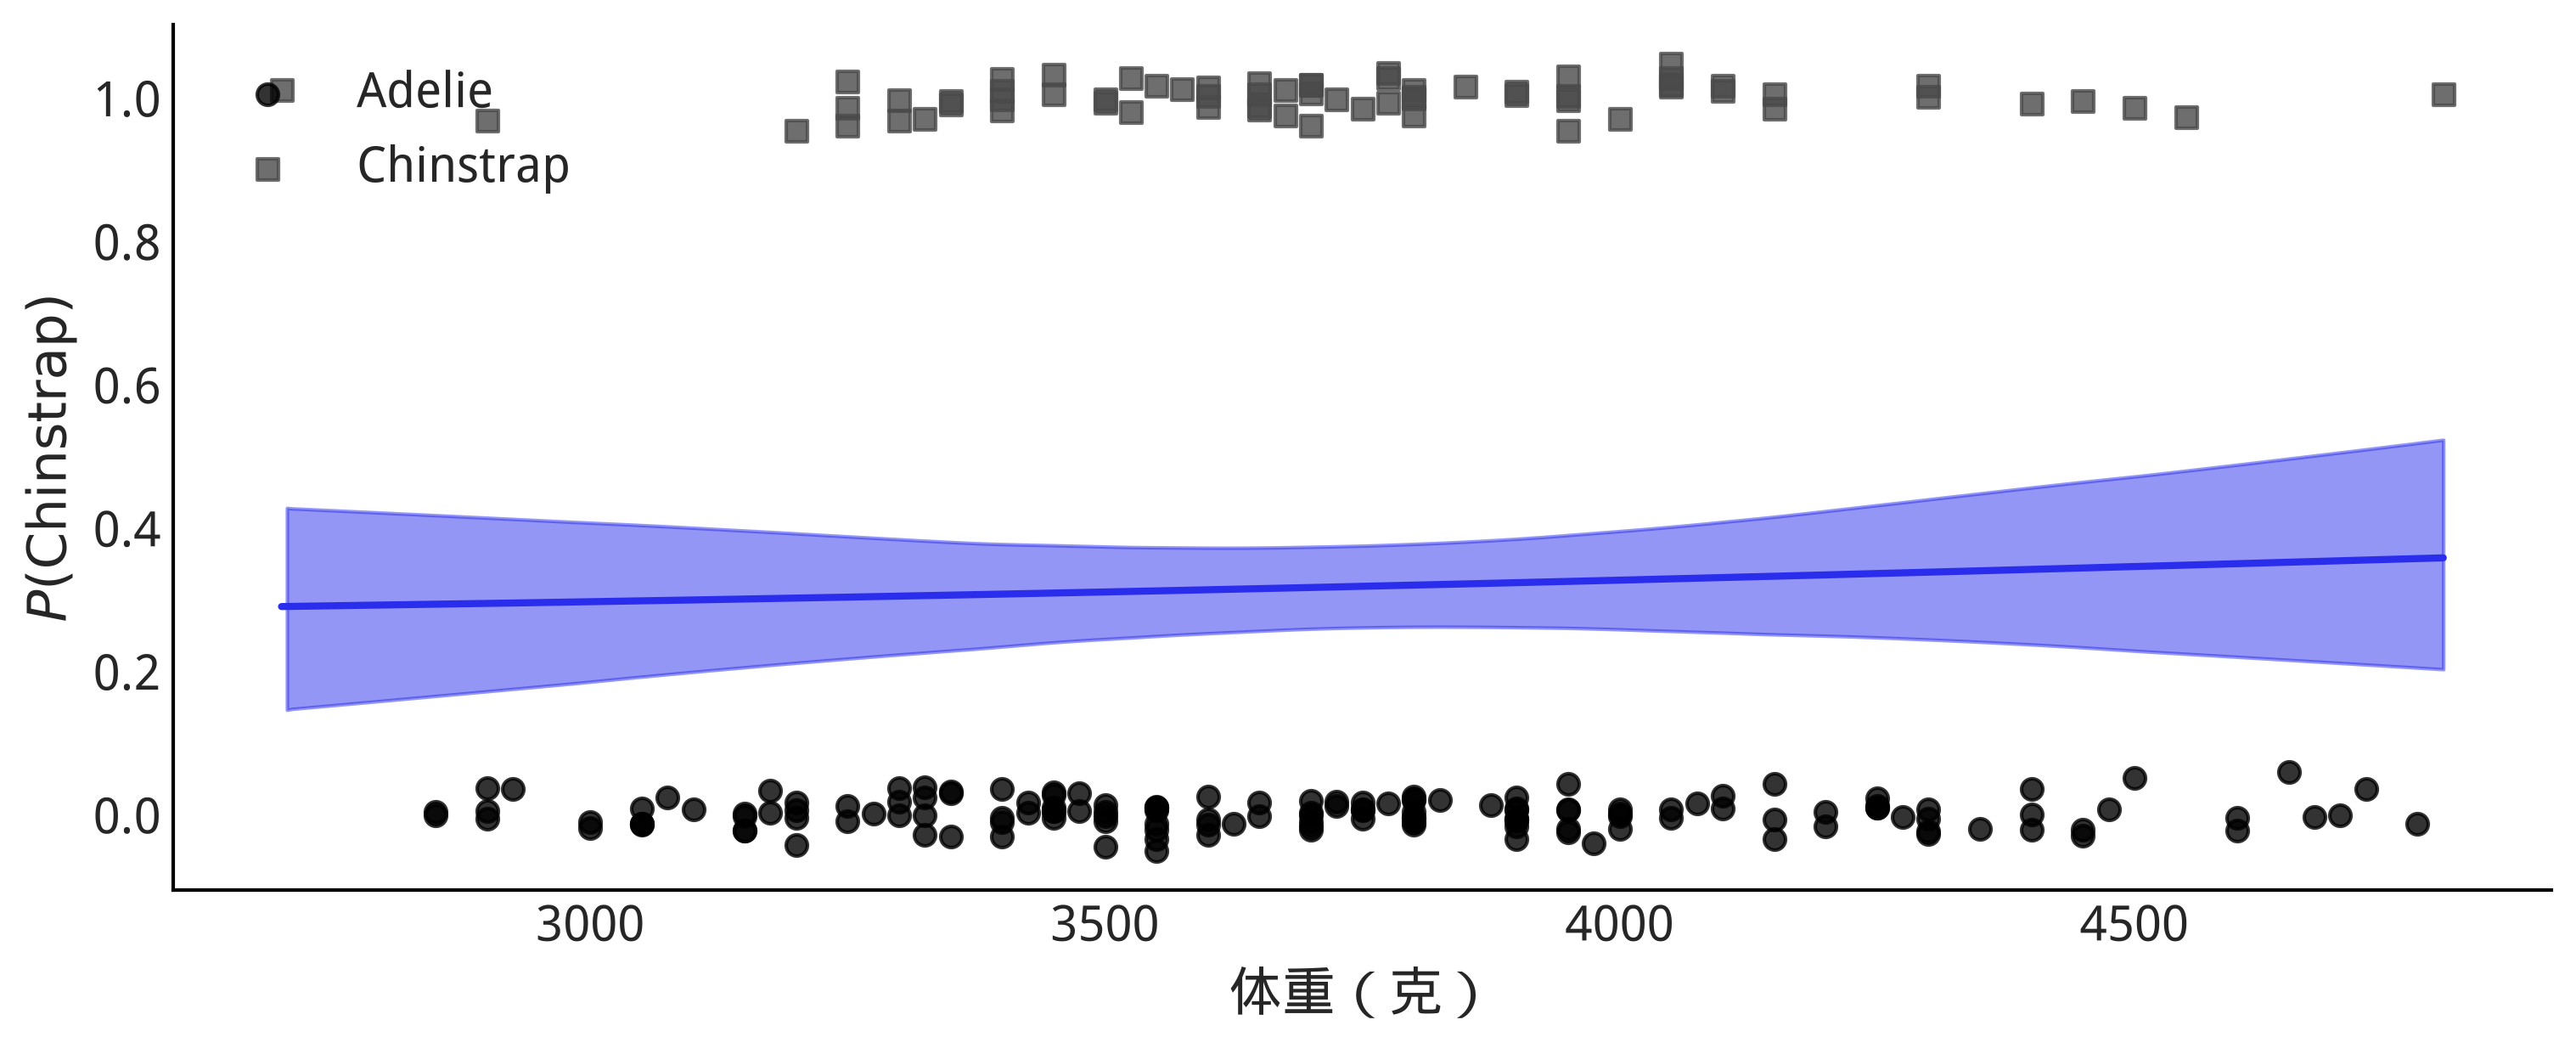

In [59]:
theta = idata_logistic_penguins_mass.posterior["θ"].mean(("chain", "draw"))

fig, ax = plt.subplots(figsize=(10, 4))
mass_curve_order = np.argsort(mass_obs)

ax.plot(
    mass_obs[mass_curve_order],
    theta[mass_curve_order],
    color="C4",
    lw=2,
)
for i, (label, marker) in enumerate(zip(species.categories, ("o", "s"))):
    class_mask = species.codes == i
    jittered_class = PLOT_RNG.normal(i, 0.02, size=class_mask.sum())
    ax.scatter(
        mass_obs[class_mask],
        jittered_class,
        marker=marker,
        label=label,
        alpha=0.8,
    )

az.plot_hdi(
    mass_obs,
    idata_logistic_penguins_mass.posterior["θ"],
    color="C4",
    ax=ax,
)

ax.set_xlabel("体重（克）")
ax.set_ylabel(r"$P(\mathrm{Chinstrap})$")
ax.legend()

**图 3.20（锚点 `fig:Logistic_mass`）** 仅以体重区分 Adelie 与 Chinstrap 的逻辑回归;重叠的观测使分类不确定性较大。

不应该因为这次没找到关系就气馁——有效的建模本来就包含反复试错。这不是说要随便乱试、指望
碰运气,而是说可以放心地借助计算工具,为下一步该怎么走提供线索。

下面我们同时用喙长和体重两个协变量,做一次多元逻辑回归,再画一遍决策边界。这次图的坐标轴略
有不同——纵轴不再是类别概率,而是体重,这样我们能看到两个自变量之间的决策边界。这些可视化
检查很有帮助,但终究是主观的,我们也可以用诊断量来给拟合结果打分。

In [60]:
X_standardized = np.column_stack(
    [np.ones_like(bill_length_z), bill_length_z, mass_z]
)

with pm.Model(
    coords={"coefficient": ["intercept", "bill_length_z", "mass_z"]}
) as model_logistic_penguins_bill_length_mass:
    β = pm.Normal("β", mu=0, sigma=2.5, dims="coefficient")

    η = pm.math.dot(X_standardized, β)
    θ = pm.Deterministic("θ", pm.math.sigmoid(η))

    # 在标准化空间求 p=0.5 的边界,再转换回克。
    mass_boundary_z = -β[0] / β[2] - β[1] / β[2] * bill_length_z
    mass_boundary = pm.Deterministic(
        "mass_boundary", mass_center + mass_scale * mass_boundary_z
    )

    yl = pm.Bernoulli("yl", p=θ, observed=chinstrap_observed)

    idata_logistic_penguins_bill_length_mass = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED, target_accept=.9,
        idata_kwargs={"log_likelihood": True})
    idata_logistic_penguins_bill_length_mass.extend(pm.sample_posterior_predictive(
        idata_logistic_penguins_bill_length_mass, random_seed=RANDOM_SEED))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [β]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 321 seconds.


Sampling: [yl]


Output()

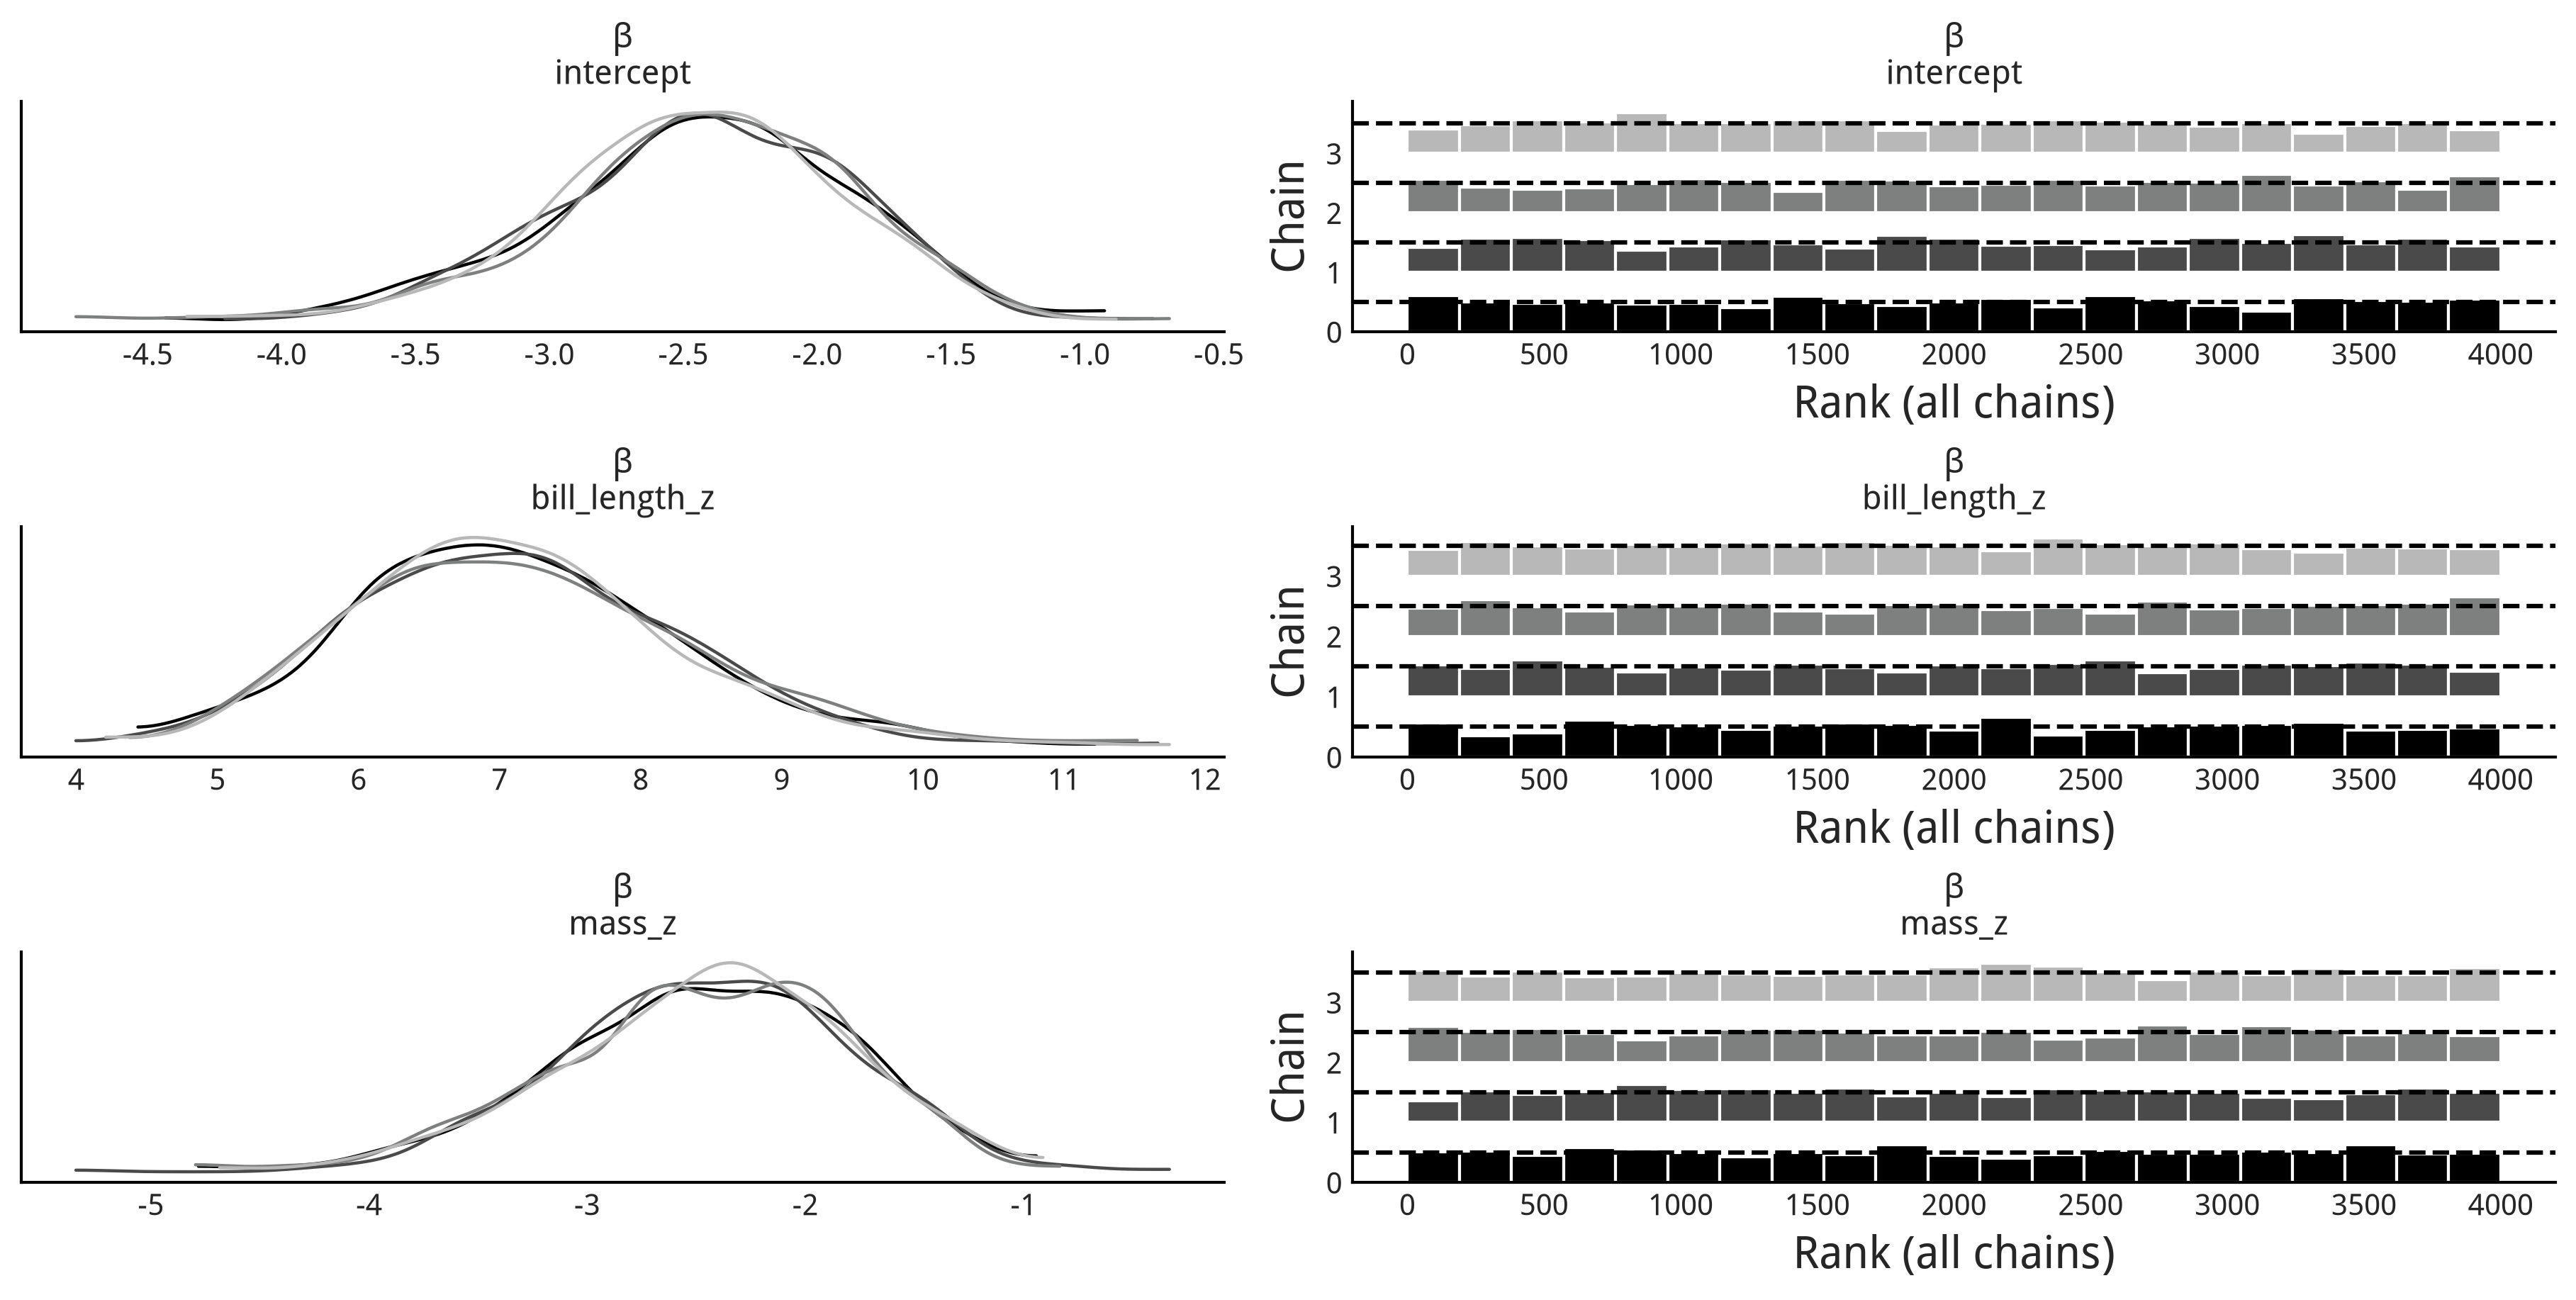

In [61]:
az.plot_trace(idata_logistic_penguins_bill_length_mass, compact=False, var_names=["β"], kind="rank_bars");

In [62]:
az.summary(idata_logistic_penguins_bill_length_mass, var_names=["β"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β[intercept],-2.431,0.546,-3.544,-1.527,0.014,0.010,1463.0,1730.0,1.0
β[bill_length_z],7.119,1.163,5.010,9.280,0.030,0.020,1553.0,1986.0,1.0
β[mass_z],-2.465,0.651,-3.648,-1.262,0.016,0.011,1652.0,1925.0,1.0


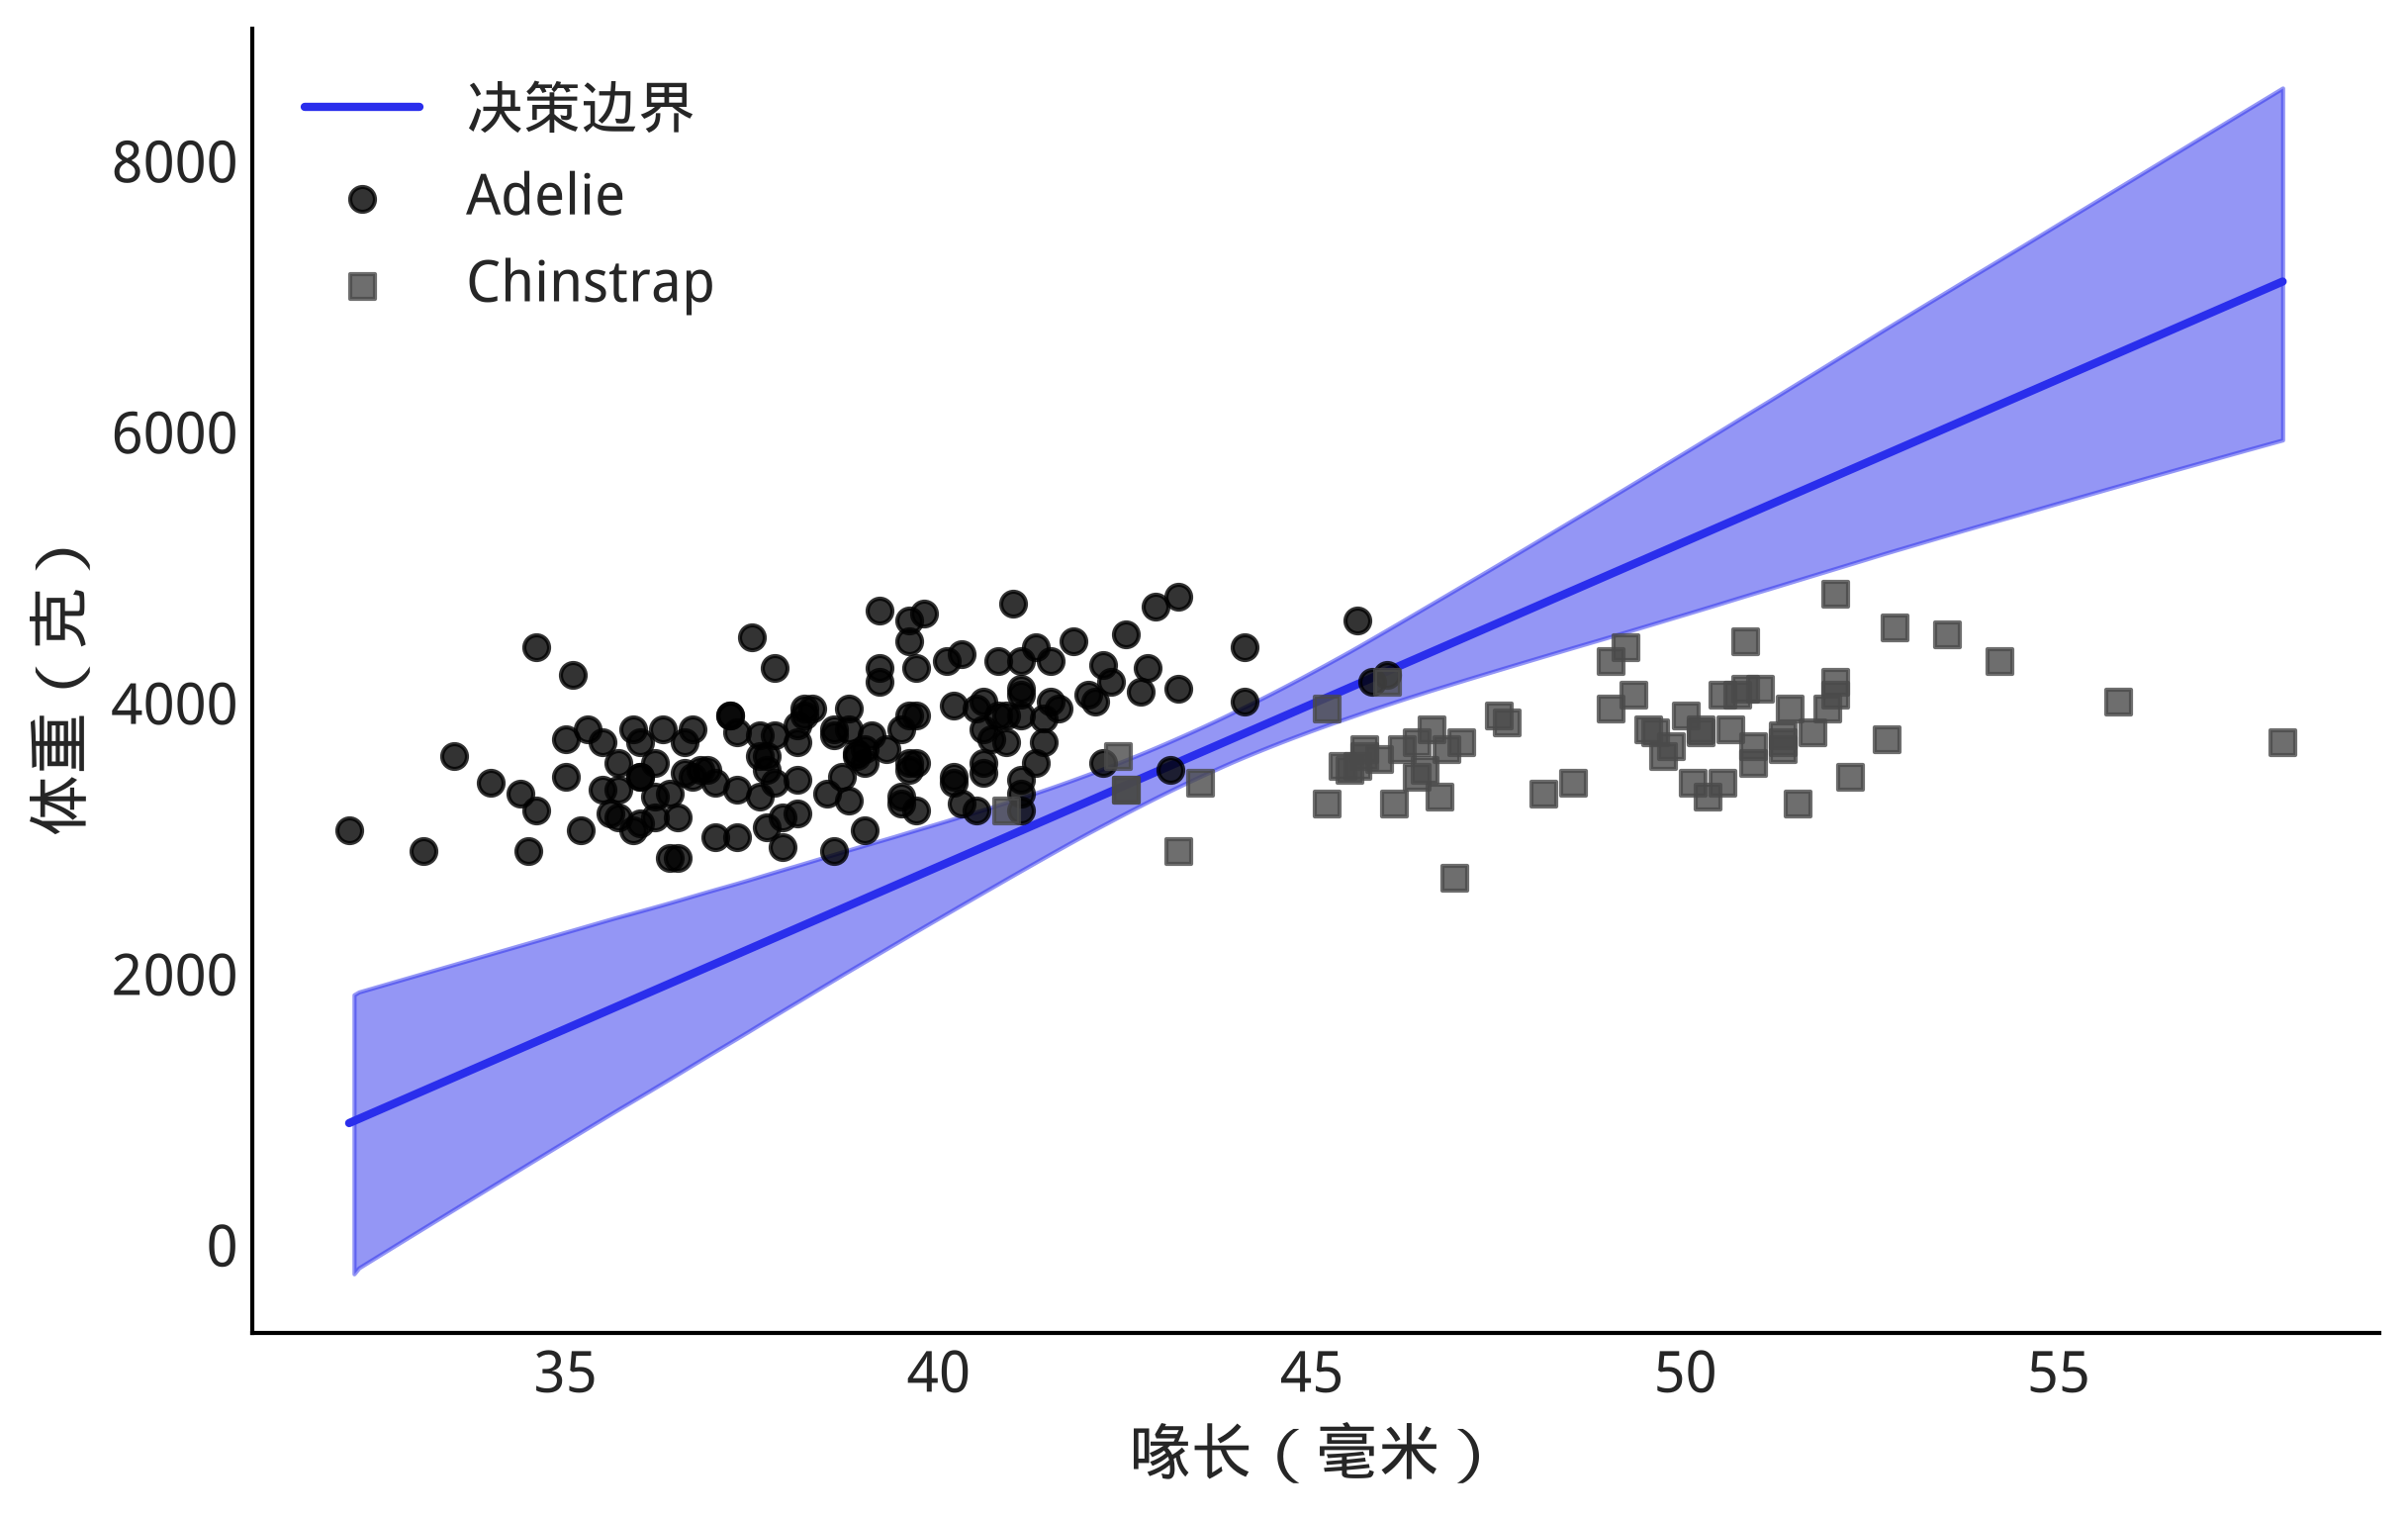

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))
boundary_order = np.argsort(bill_length_obs)
mass_boundary_mean = (
    idata_logistic_penguins_bill_length_mass.posterior["mass_boundary"]
    .mean(("chain", "draw"))
    .values
)
chinstrap_class_mask = chinstrap_observed.astype(bool)

ax.plot(
    bill_length_obs[boundary_order],
    mass_boundary_mean[boundary_order],
    color="C4",
    lw=2,
    label="决策边界",
)
az.plot_hdi(
    bill_length_obs,
    idata_logistic_penguins_bill_length_mass.posterior["mass_boundary"],
    color="C4",
    ax=ax,
)

ax.scatter(
    bill_length_obs[~chinstrap_class_mask],
    mass_obs[~chinstrap_class_mask],
    alpha=0.8,
    label="Adelie",
    zorder=10,
)
ax.scatter(
    bill_length_obs[chinstrap_class_mask],
    mass_obs[chinstrap_class_mask],
    marker="s",
    alpha=0.8,
    label="Chinstrap",
    zorder=10,
)

ax.set_ylabel("体重（克）")
ax.set_xlabel("喙长（毫米）")
ax.legend()

**图 3.21（锚点 `fig:Decision_Boundary_Logistic_mass_bill_length`）** 同时使用标准化喙长与体重的分类边界,并转换回原始毫米和克的尺度。

要评估逻辑回归模型的拟合效果,可以用分离图(separation plot){cite:p}`separation_plot`。分离图是一种评估二元观测数据
模型校准情况的方法:它按类别对预测值排序展示,理想情况下——如果模型能完美区分两类——图上会
呈现两个界限分明的矩形块。我们的例子里,没有一个模型完美区分了两个物种,但包含喙长的模型,
明显比只有体重的模型表现更好。一般来说,贝叶斯分析的目标并不是"完美校准",但分离图(以及像
LOO-PIT 这样的其他校准评估方法)依然能帮助我们比较模型、发现可以改进的地方。

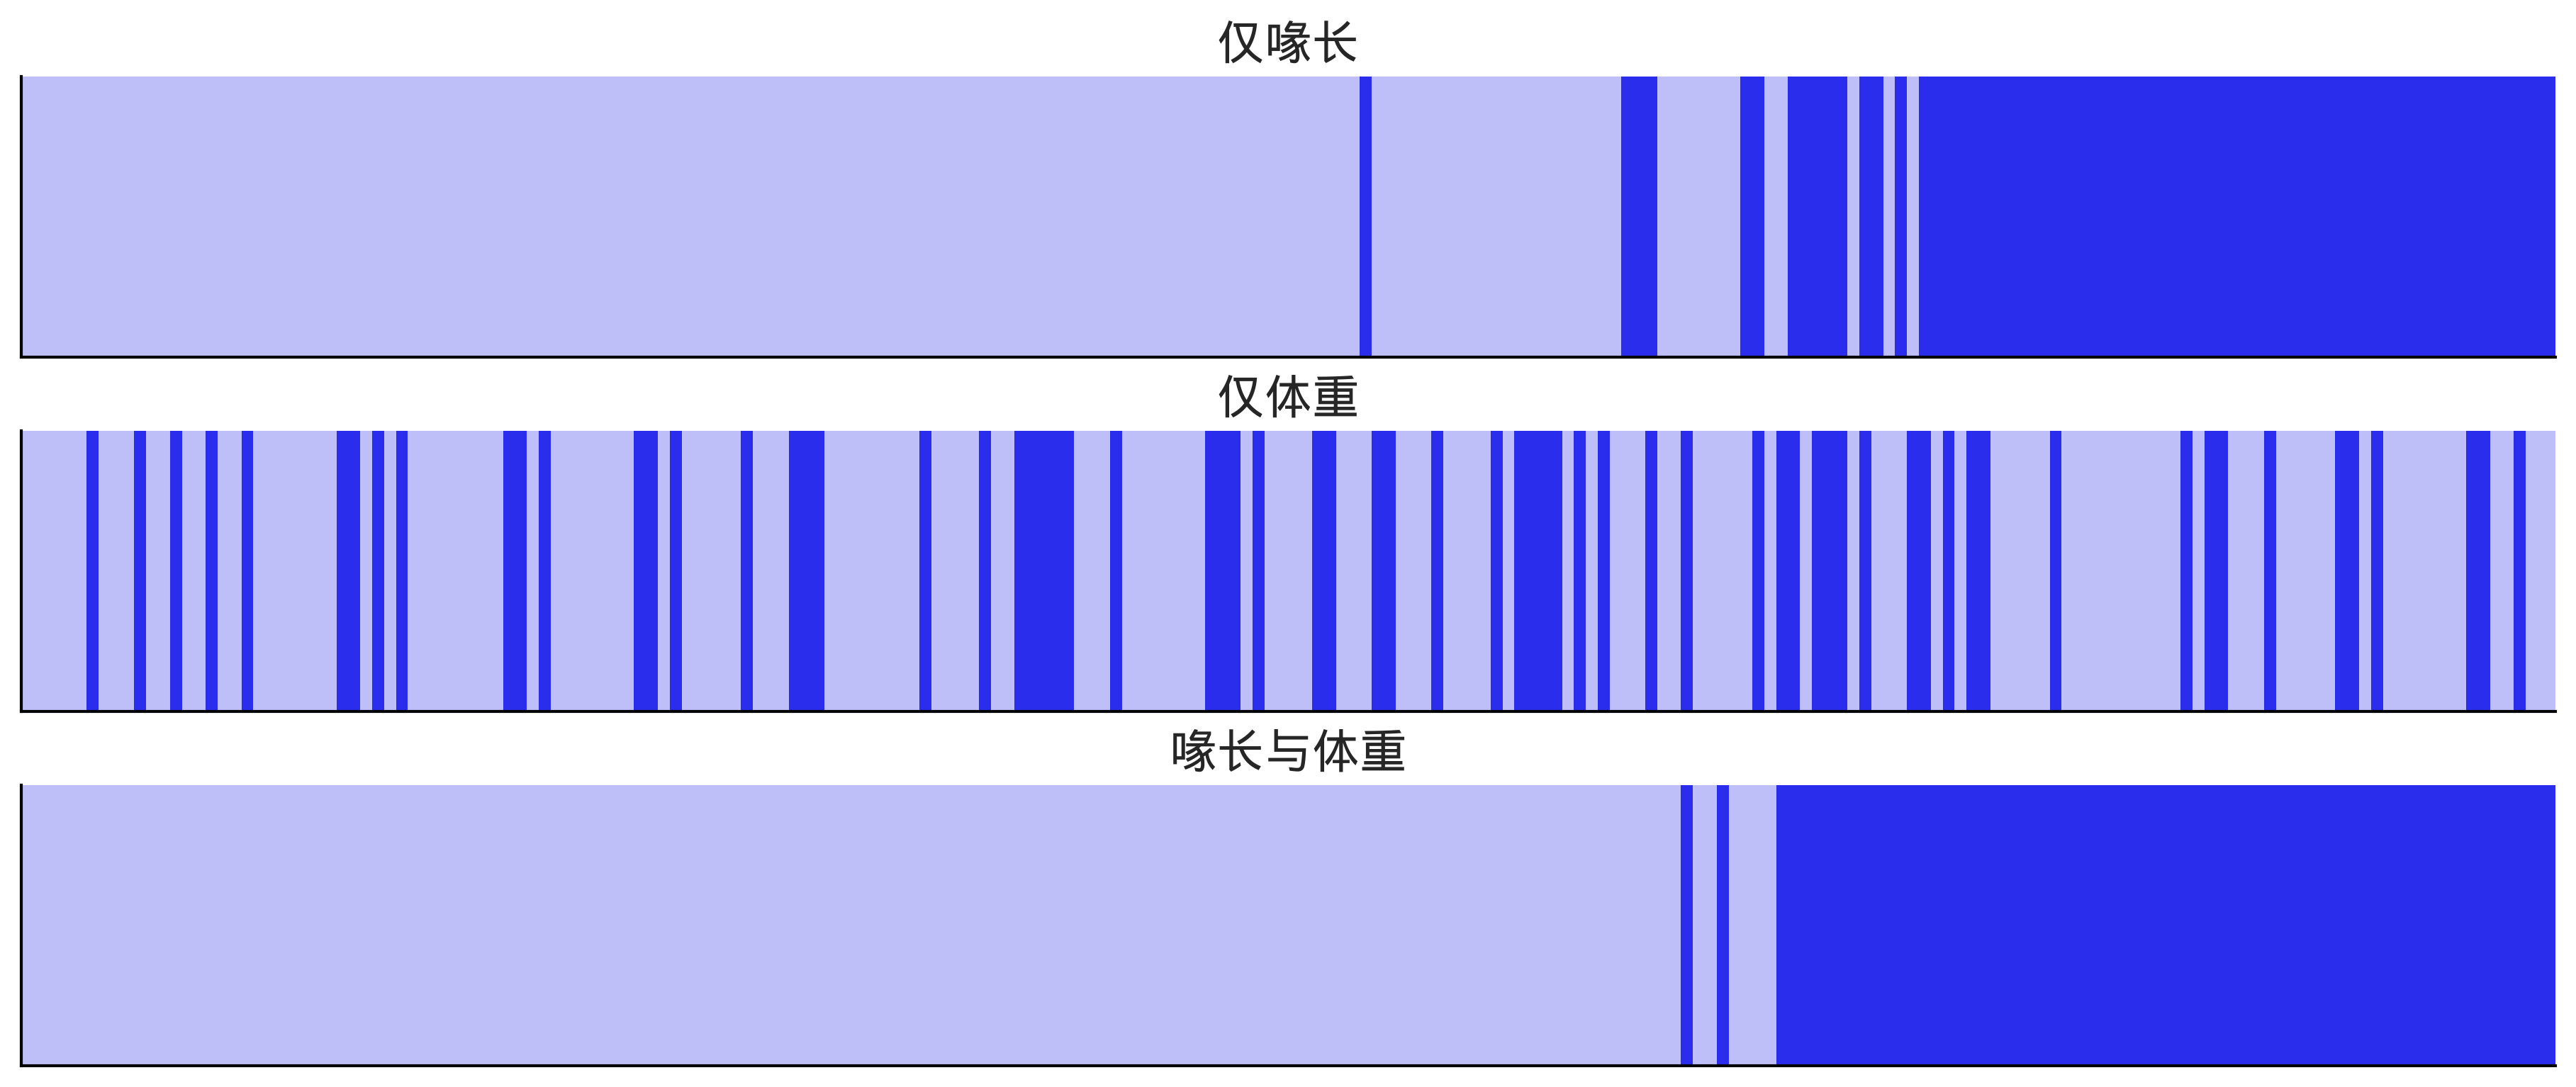

In [64]:
models = {
    "仅喙长": idata_logistic_penguins_bill_length,
    "仅体重": idata_logistic_penguins_mass,
    "喙长与体重": idata_logistic_penguins_bill_length_mass,
}

_, axes = plt.subplots(3, 1, figsize=(12, 5), sharey=True)
for (label, model), ax in zip(models.items(), axes):
    az.plot_separation(model, "yl", ax=ax, color="C4")
    ax.set_title(label)

**图 3.22（锚点 `fig:Penguins_Separation_Plot`）** 三个企鹅分类模型的分离图;按预测概率排序后可比较两类被区分的程度。

我们也可以用 LOO 来比较刚才建立的三个模型——只用体重、只用喙长,以及同时使用两者。按照 LOO,
只用体重的模型在区分物种上表现最差,只用喙长的模型居中,同时使用喙长和体重的模型表现最好。
这和我们从图中看到的结果一致,现在又有了数值上的印证。

In [65]:
penguin_logistic_comparison = az.compare(
    {
        "mass": idata_logistic_penguins_mass,
        "bill": idata_logistic_penguins_bill_length,
        "mass_bill": idata_logistic_penguins_bill_length_mass,
    }
)
penguin_logistic_comparison.round(1)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
mass_bill,0,-12.8,1.2,0.0,1.0,2.9,0.0,False,log
bill,1,-26.9,1.4,14.1,0.0,5.8,3.9,False,log
mass,2,-135.6,1.9,122.8,0.0,5.3,5.7,False,log


**表 3.5（锚点 `tab:penguin_loo`）** 三个企鹅分类模型的 LOO 比较;排序必须结合标准误、Pareto $k$ 与采样诊断解读。

比较表的排序不是自动结论。先确认各模型采样诊断可接受,再分别查看 `az.loo` 的 Pareto $k$
诊断与比较表中的标准误;若 ELPD 差异与其不确定性相当,就不应宣称模型存在确定排名。smoke 短链
尤其只适合验证 API 和数据流。

### 解读对数几率(Log Odds)

逻辑回归中,斜率告诉你的是:标准化后的 $x$ 每增加一个单位,Chinstrap 成功类别的对数几率
(log odds)会增加多少个单位。所谓
**几率(odds)**,最简单来说就是“事件发生的概率”与“事件不发生的概率”之比。我们的模型把
Chinstrap 编码为 1,所以从 Adelie 和 Chinstrap 中随机挑一只时,成功事件应是挑到 Chinstrap:

In [66]:
# 两个建模物种的样本数
counts = penguins["species"].value_counts()
adelie_count = int(counts["Adelie"])
chinstrap_count = int(counts["Chinstrap"])
chinstrap_probability = chinstrap_count / (adelie_count + chinstrap_count)
chinstrap_probability

0.3177570093457944

对同一个成功事件,几率是 $p/(1-p)$,也就是 Chinstrap 数量与 Adelie 数量之比:

In [67]:
chinstrap_odds = chinstrap_count / adelie_count
chinstrap_odds

0.4657534246575342

概率与几率由相同成分构成,只是变换后的解释不同。这里的经验几率小于 1,表示样本中 Chinstrap
少于 Adelie。这个方向与模型的成功类别完全一致,避免把 $P(\mathrm{Chinstrap})$ 误说成
$P(\mathrm{Adelie})$。

利用几率的概念,我们可以定义 logit:logit 就是几率的自然对数。我们可以用 logit,把逻辑回归
公式改写成另一种形式:

$$
\log \left(\frac{p}{1-p} \right) = \boldsymbol{X} \beta
$$

**式 (3.8)（锚点 `eq:logit`）**

这种改写方式,让我们能把逻辑回归的系数,解读为"对数几率的变化量"。借助这一点,我们可以计算
“观测到的喙长发生变化”时,Chinstrap 相对 Adelie 企鹅出现概率的变化,如下所示。由于模型使用
标准化喙长,代入线性预测子前必须先做同样的中心化和缩放。这类变换不仅
在数学上很有意思,在讨论统计结果时也非常实用,我们会在后续章节更深入地讨论这个话题。

In [68]:
β_0 = idata_logistic_penguins_bill_length.posterior["β_0"].mean().item()
β_1 = idata_logistic_penguins_bill_length.posterior["β_1"].mean().item()

In [69]:
β_0

-2.0047775803201953

In [70]:
β_1

5.266552956787246

In [71]:
bill_length = 45.0
bill_length_next = 46.0
bill_z_1 = (bill_length - bill_length_center) / bill_length_scale
bill_z_2 = (bill_length_next - bill_length_center) / bill_length_scale
val_1 = β_0 + β_1 * bill_z_1
val_2 = β_0 + β_1 * bill_z_2
probability_change = special.expit(val_2) - special.expit(val_1)

f"喙长从 45 mm 到 46 mm 时，P(Chinstrap) 改变 {probability_change * 100:.1f} 个百分点"

'喙长从 45 mm 到 46 mm 时，P(Chinstrap) 改变 15.7 个百分点'

In [72]:
bill_length = np.array([30.0, 45.0])
bill_length_z_now = (bill_length - bill_length_center) / bill_length_scale
bill_length_z_next = (bill_length + 1 - bill_length_center) / bill_length_scale
val_1 = β_0 + β_1 * bill_length_z_now
val_2 = β_0 + β_1 * bill_length_z_next

In [73]:
special.expit(val_2) - special.expit(val_1)

array([2.11754648e-06, 1.56761686e-01])

## 回归模型中先验的选择

熟悉了广义线性模型之后,我们把重点放到先验及其对后验估计的影响上。这里借用《Regression and
Other Stories》{cite:p}`ROS` 中的一个例子,以及其中讨论的研究 {cite:p}`LikehoodandPrior`:
该研究探讨了“父母的外貌吸引力”与“其子女中女孩比例”之间的关系。研究者把美国青少年的外貌
吸引力按 5 档评分,这些受试者后来大多有了孩子,研究者统计了
每个吸引力档位下的性别比例。数据如下,同一段代码里我们也写了一个单变量回归模型——不过这次,
我们特别关注先验和似然应该**放在一起**评估,而不是各自独立地看待。

In [74]:
x = np.arange(-2,3,1)
y = [50, 44, 50, 47, 56]

Text(0.5, 1.0, '父母吸引力与子女中女孩比例')

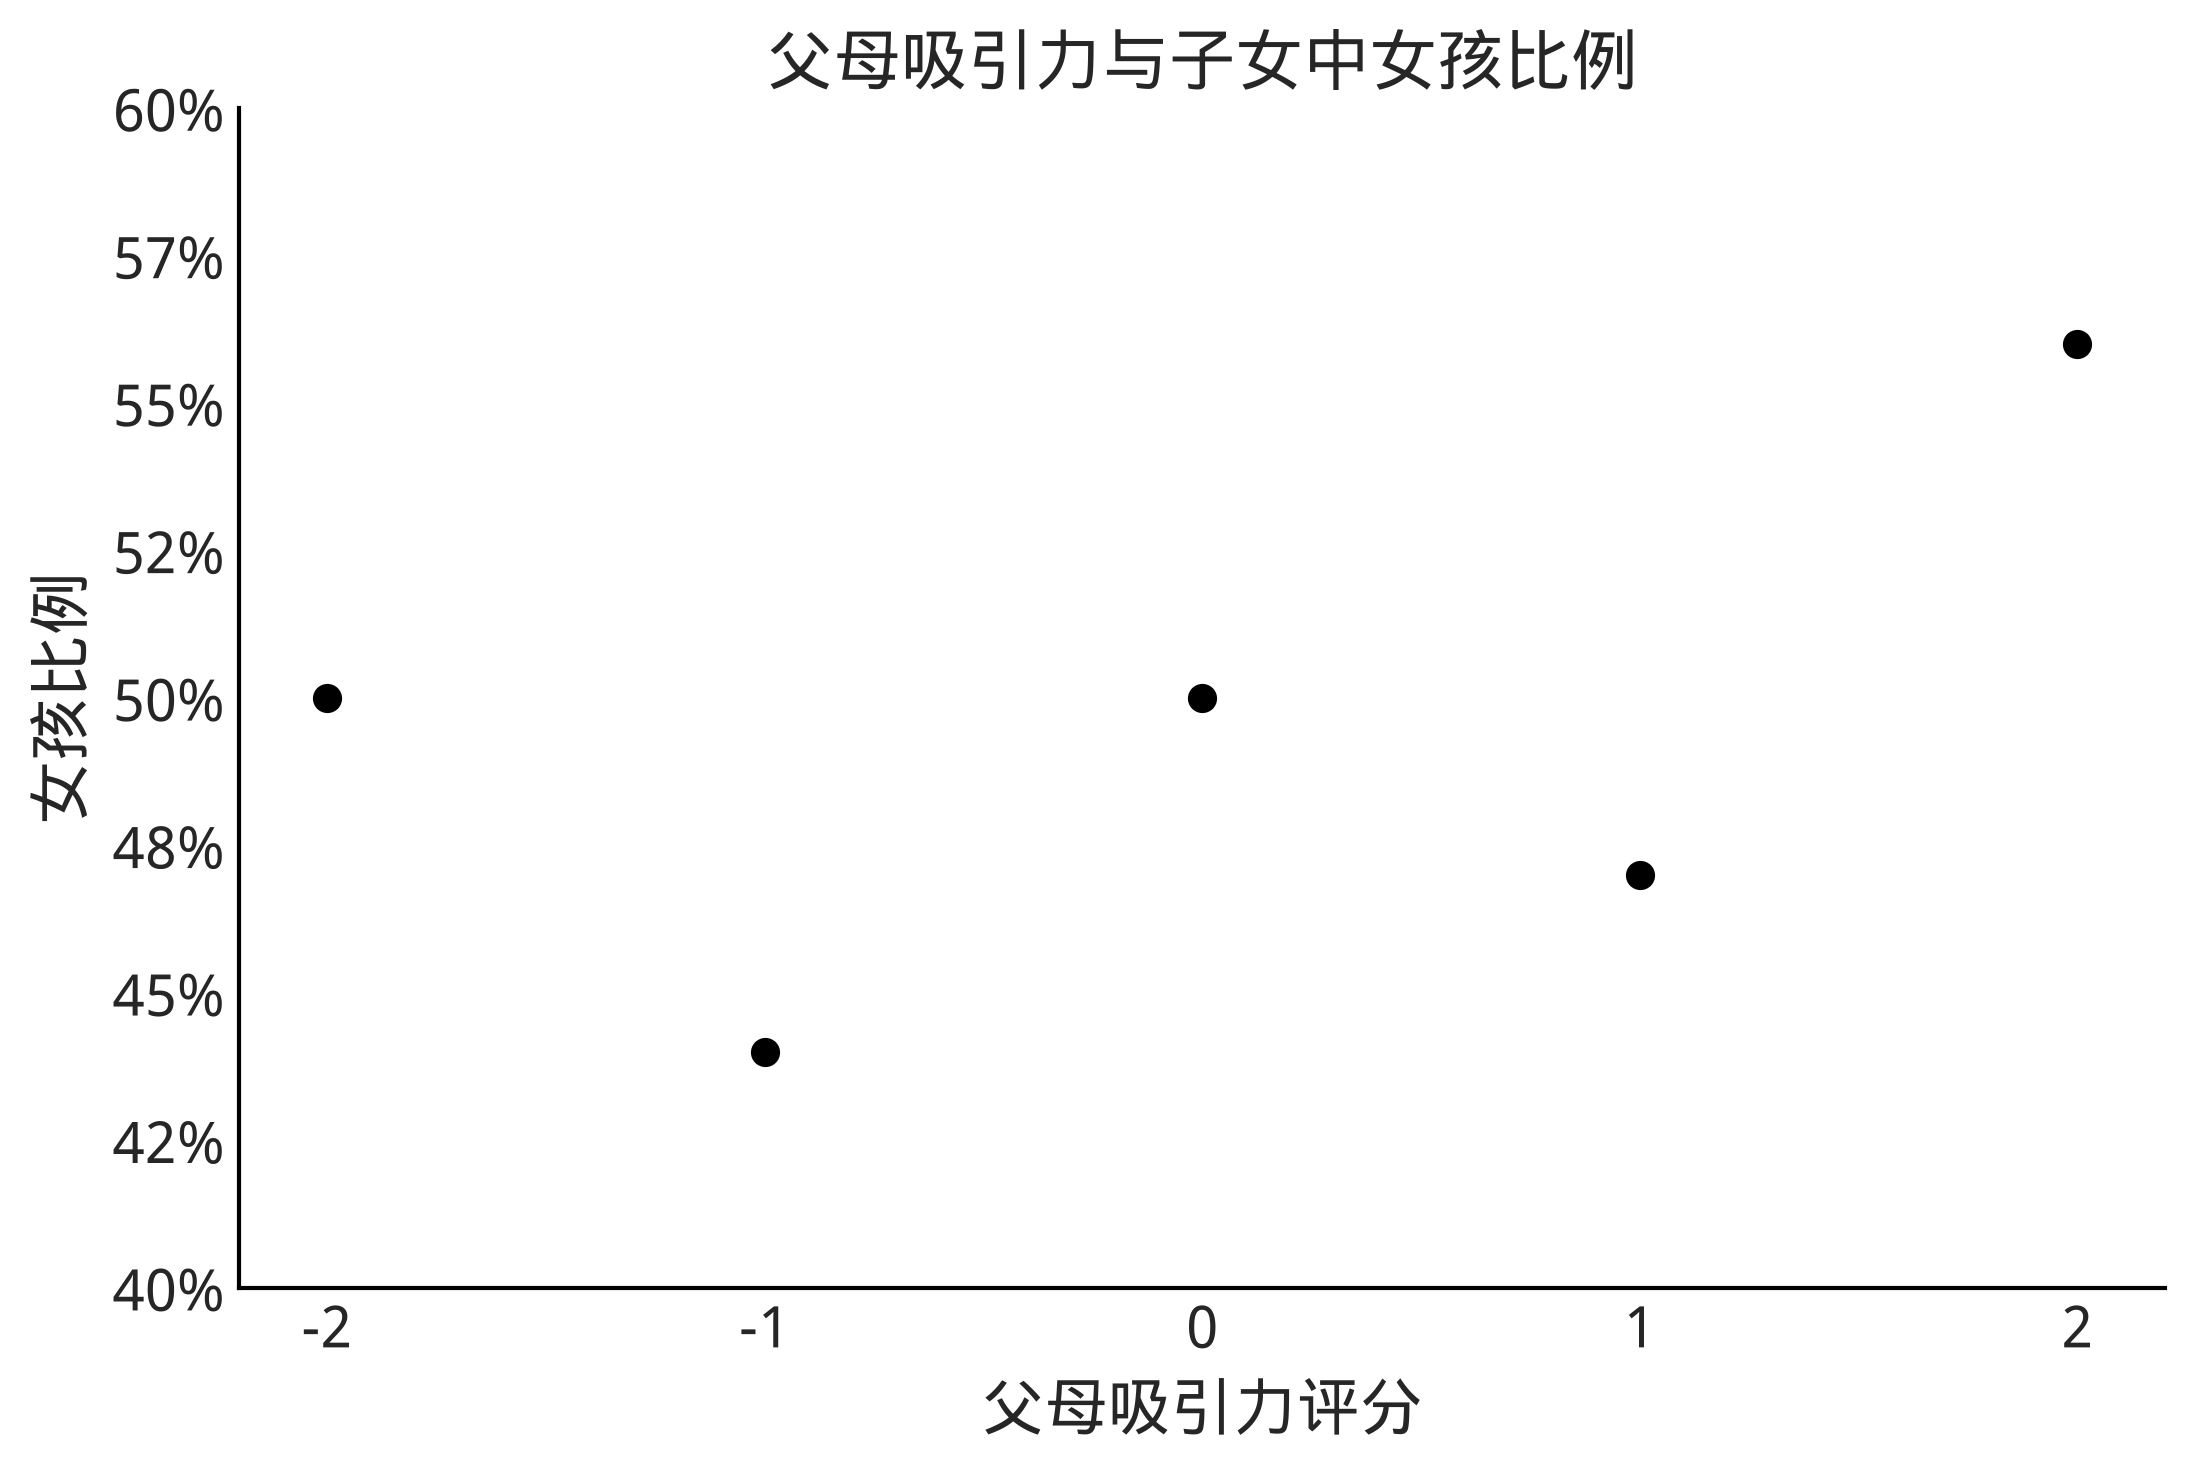

In [75]:
import matplotlib.ticker as mtick
fig, ax = plt.subplots()

ax.scatter(x, y)
ax.set_xticks(x)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_ylim(40, 60)
ax.set_xlabel("父母吸引力评分")
ax.set_ylabel("女孩比例")
ax.set_title("父母吸引力与子女中女孩比例")

**图 3.23（锚点 `fig:BeautyRatio`）** 父母吸引力评分与子女中女孩比例的五个汇总观测。

名义上,我们会假设男孩女孩出生比例大致相等,且外貌吸引力对性别比例没有影响。这意味着截距
$\beta_0$ 的先验均值设为 50,系数 $\beta_1$ 的先验均值设为 0。同时我们把先验的离散程度设得
很宽,以表达我们对截距、以及吸引力对性别比例的影响都缺乏了解。这并不是完全"无信息"的先验
(我们在前面章节讨论过那种先验),而是一个非常宽泛的先验。

In [76]:
with pm.Model() as model_uninformative_prior_sex_ratio:
    σ = pm.Exponential("σ", .5)
    β_1 = pm.Normal("β_1", 0, 20)
    β_0 = pm.Normal("β_0", 50, 20)

    μ = pm.Deterministic("μ", β_0 + β_1 * x)

    ratio = pm.Normal("ratio", mu=μ, sigma=σ, observed=y)

    idata_uninformative_prior_sex_ratio = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED)
    idata_uninformative_prior_sex_ratio.extend(pm.sample_prior_predictive(
        draws=PRIOR_SAMPLES, random_seed=RANDOM_SEED))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [σ, β_1, β_0]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 78 seconds.


Sampling: [ratio, β_0, β_1, σ]


array([<Axes: title={'center': 'β_0'}>, <Axes: title={'center': 'β_1'}>],
      dtype=object)

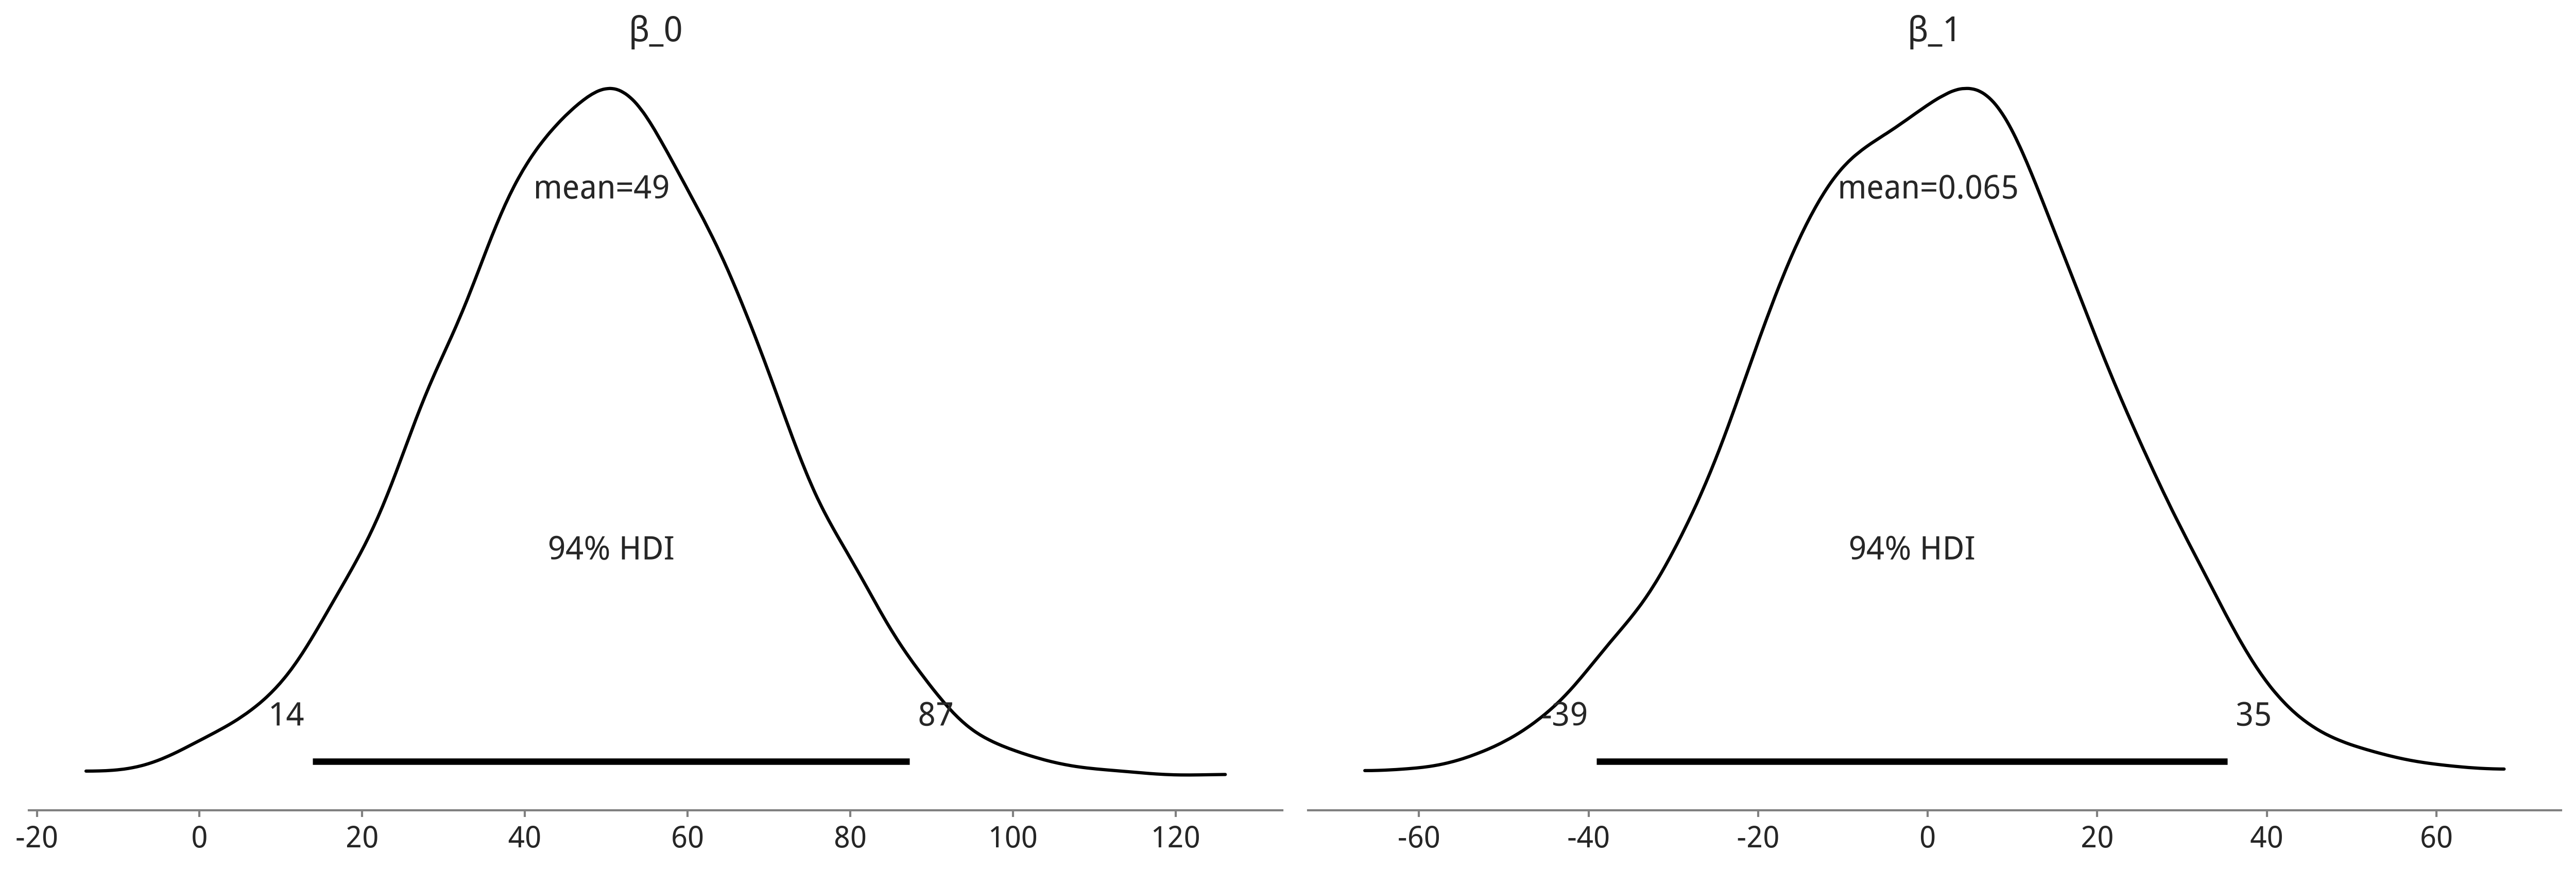

In [77]:
az.plot_posterior(idata_uninformative_prior_sex_ratio.prior, var_names=["β_0", "β_1"])

In [78]:
az.summary(idata_uninformative_prior_sex_ratio, var_names=["β_0", "β_1", "σ"], kind="stats")

,mean,sd,hdi_3%,hdi_97%
β_0,49.365,2.002,45.281,52.994
β_1,1.481,1.397,-1.215,4.071
σ,4.268,1.477,2.066,7.062


用这样的设置拟合模型后,应从本次 `az.summary` 读取 $\beta_1$ 的点估计与 HDI。宽泛先验允许
许多非常陡的先验拟合线;后验也可能因为样本很少而保留看似很大的效应。下图上半部分确实抽取
**先验**样本,下半部分则抽取**后验**样本,两组不能混淆 [^10]。

Text(0.5, 0, '父母吸引力评分')

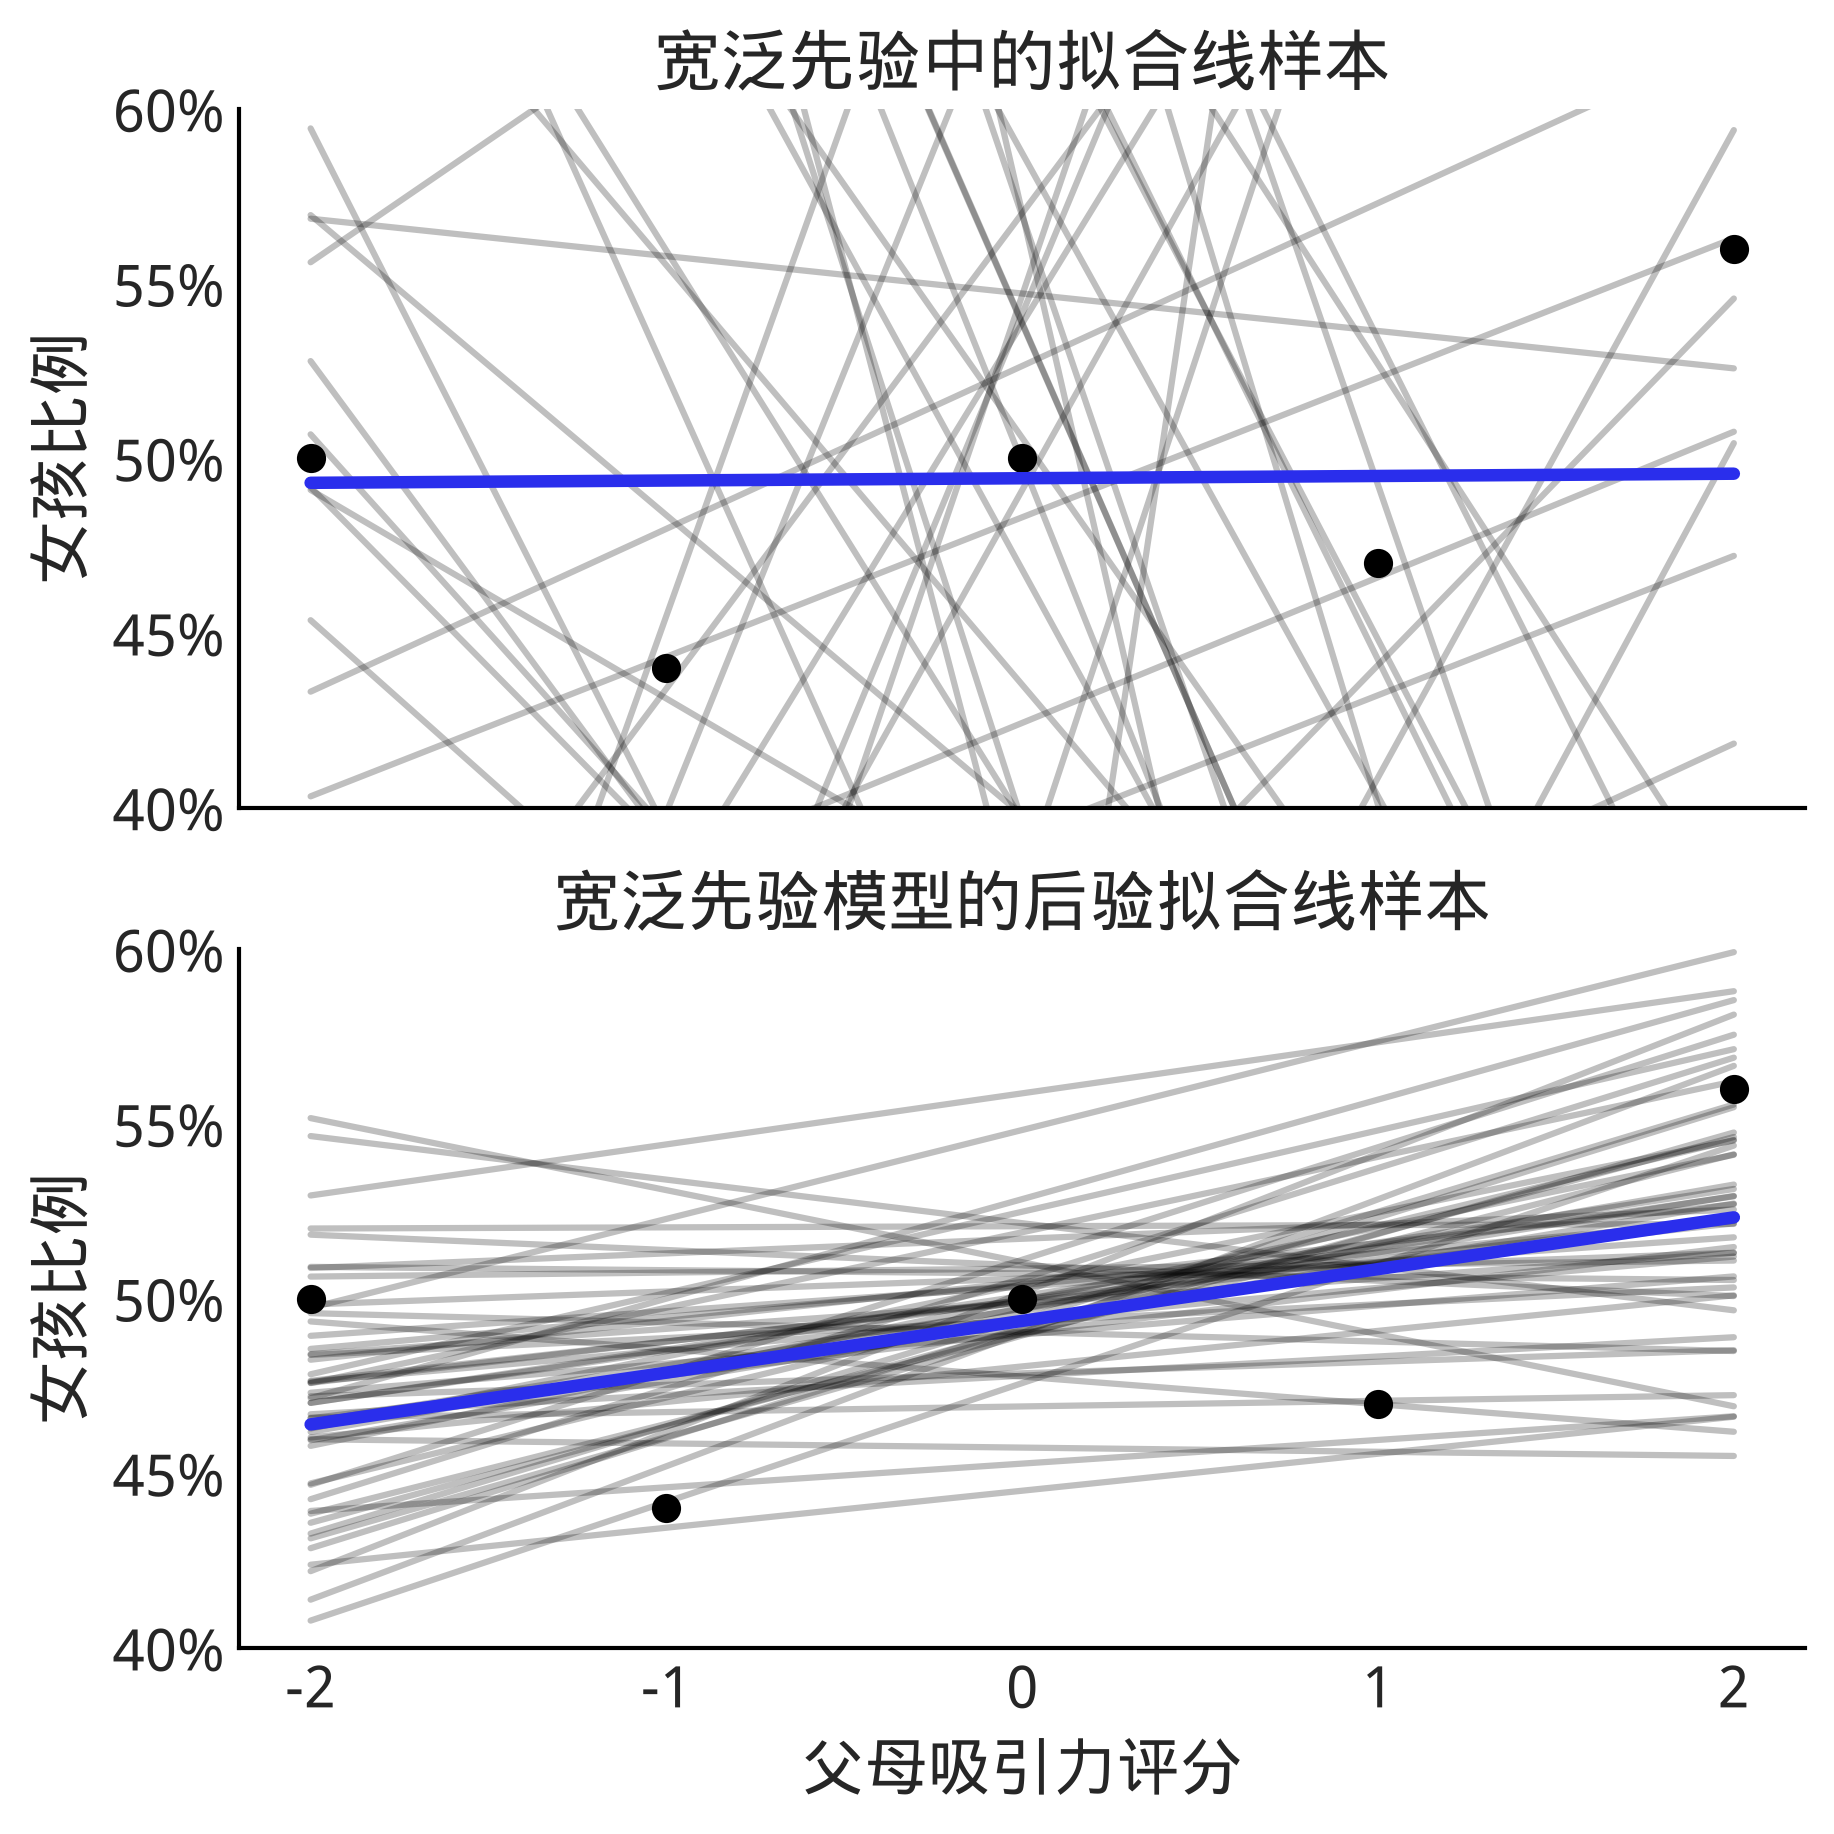

In [79]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
num_samples = 50
prior_subset = az.extract(
    idata_uninformative_prior_sex_ratio,
    group="prior",
    num_samples=num_samples,
    rng=RANDOM_SEED,
)
posterior_subset = az.extract(
    idata_uninformative_prior_sex_ratio,
    group="posterior",
    num_samples=num_samples,
    rng=RANDOM_SEED,
)

prior_lines = (
    prior_subset["β_0"].values[:, None]
    + prior_subset["β_1"].values[:, None] * x[None, :]
)
posterior_lines = (
    posterior_subset["β_0"].values[:, None]
    + posterior_subset["β_1"].values[:, None] * x[None, :]
)
axes[0].plot(x, prior_lines.T, c="black", alpha=0.25)
axes[1].plot(x, posterior_lines.T, c="black", alpha=0.25)

prior_b0 = idata_uninformative_prior_sex_ratio.prior["β_0"].mean().item()
prior_b1 = idata_uninformative_prior_sex_ratio.prior["β_1"].mean().item()
posterior_b0 = idata_uninformative_prior_sex_ratio.posterior["β_0"].mean().item()
posterior_b1 = idata_uninformative_prior_sex_ratio.posterior["β_1"].mean().item()
axes[0].plot(x, prior_b0 + prior_b1 * x, c="C4", linewidth=3)
axes[1].plot(x, posterior_b0 + posterior_b1 * x, c="C4", linewidth=3)

for ax in axes:
    ax.scatter(x, y)
    ax.set_xticks(x)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.set_ylim(40, 60)
    ax.set_ylabel("女孩比例")
axes[0].set_title("宽泛先验中的拟合线样本")
axes[1].set_title("宽泛先验模型的后验拟合线样本")
axes[1].set_xlabel("父母吸引力评分")

**图 3.24（锚点 `fig:PosteriorUninformativeLinearRegression`）** 宽泛先验模型的先验与后验拟合线。上、下两幅图分别从正确的 prior 与 posterior 组抽样。

从数学角度看,这个结果是"成立"的。但从我们的常识、以及本研究之外对出生性别比的一般了解来看,
这个结果相当可疑。已有研究测得,自然出生性别比大约是每 105 个男孩对应 100 个女孩(范围大致在
103 到 107 之间),换算下来女孩比例约为 48.5%,标准差约为 0.5。而且,即便是那些与人类生物学
关系更密切的因素,对出生性别比的影响也远没有达到这种量级,这就削弱了"外貌吸引力这种主观因素
能有这么大影响"的说法。基于这些信息,两组之间出现 8% 的差异,需要非同寻常的证据支撑才站得
住脚。

我们用更符合这些常识的信息性先验,重新拟合一次模型。画出后验样本后可以看到,系数的集中程度
更高,后验拟合线也落在了考虑现实中合理性别比之后更合理的范围内。

In [80]:
with pm.Model() as model_informative_prior_sex_ratio:
    σ = pm.Exponential("σ", .5)

    # 注意这里换成了信息量更大的先验
    β_1 = pm.Normal("β_1", 0, .5)
    β_0 = pm.Normal("β_0", 48.5, .5)

    μ = pm.Deterministic("μ", β_0 + β_1 * x)
    ratio = pm.Normal("ratio", mu=μ, sigma=σ, observed=y)

    idata_informative_prior_sex_ratio = pm.sample(
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
        random_seed=RANDOM_SEED)
    idata_informative_prior_sex_ratio.extend(pm.sample_prior_predictive(
        draws=PRIOR_SAMPLES, random_seed=RANDOM_SEED))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [σ, β_1, β_0]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 58 seconds.


Sampling: [ratio, β_0, β_1, σ]


In [81]:
az.summary(idata_informative_prior_sex_ratio, var_names=["β_0", "β_1", "σ"], kind="stats")

,mean,sd,hdi_3%,hdi_97%
β_0,48.576,0.476,47.670,49.466
β_1,0.215,0.465,-0.674,1.070
σ,4.069,1.242,2.232,6.389


Text(0.5, 0, '父母吸引力评分')

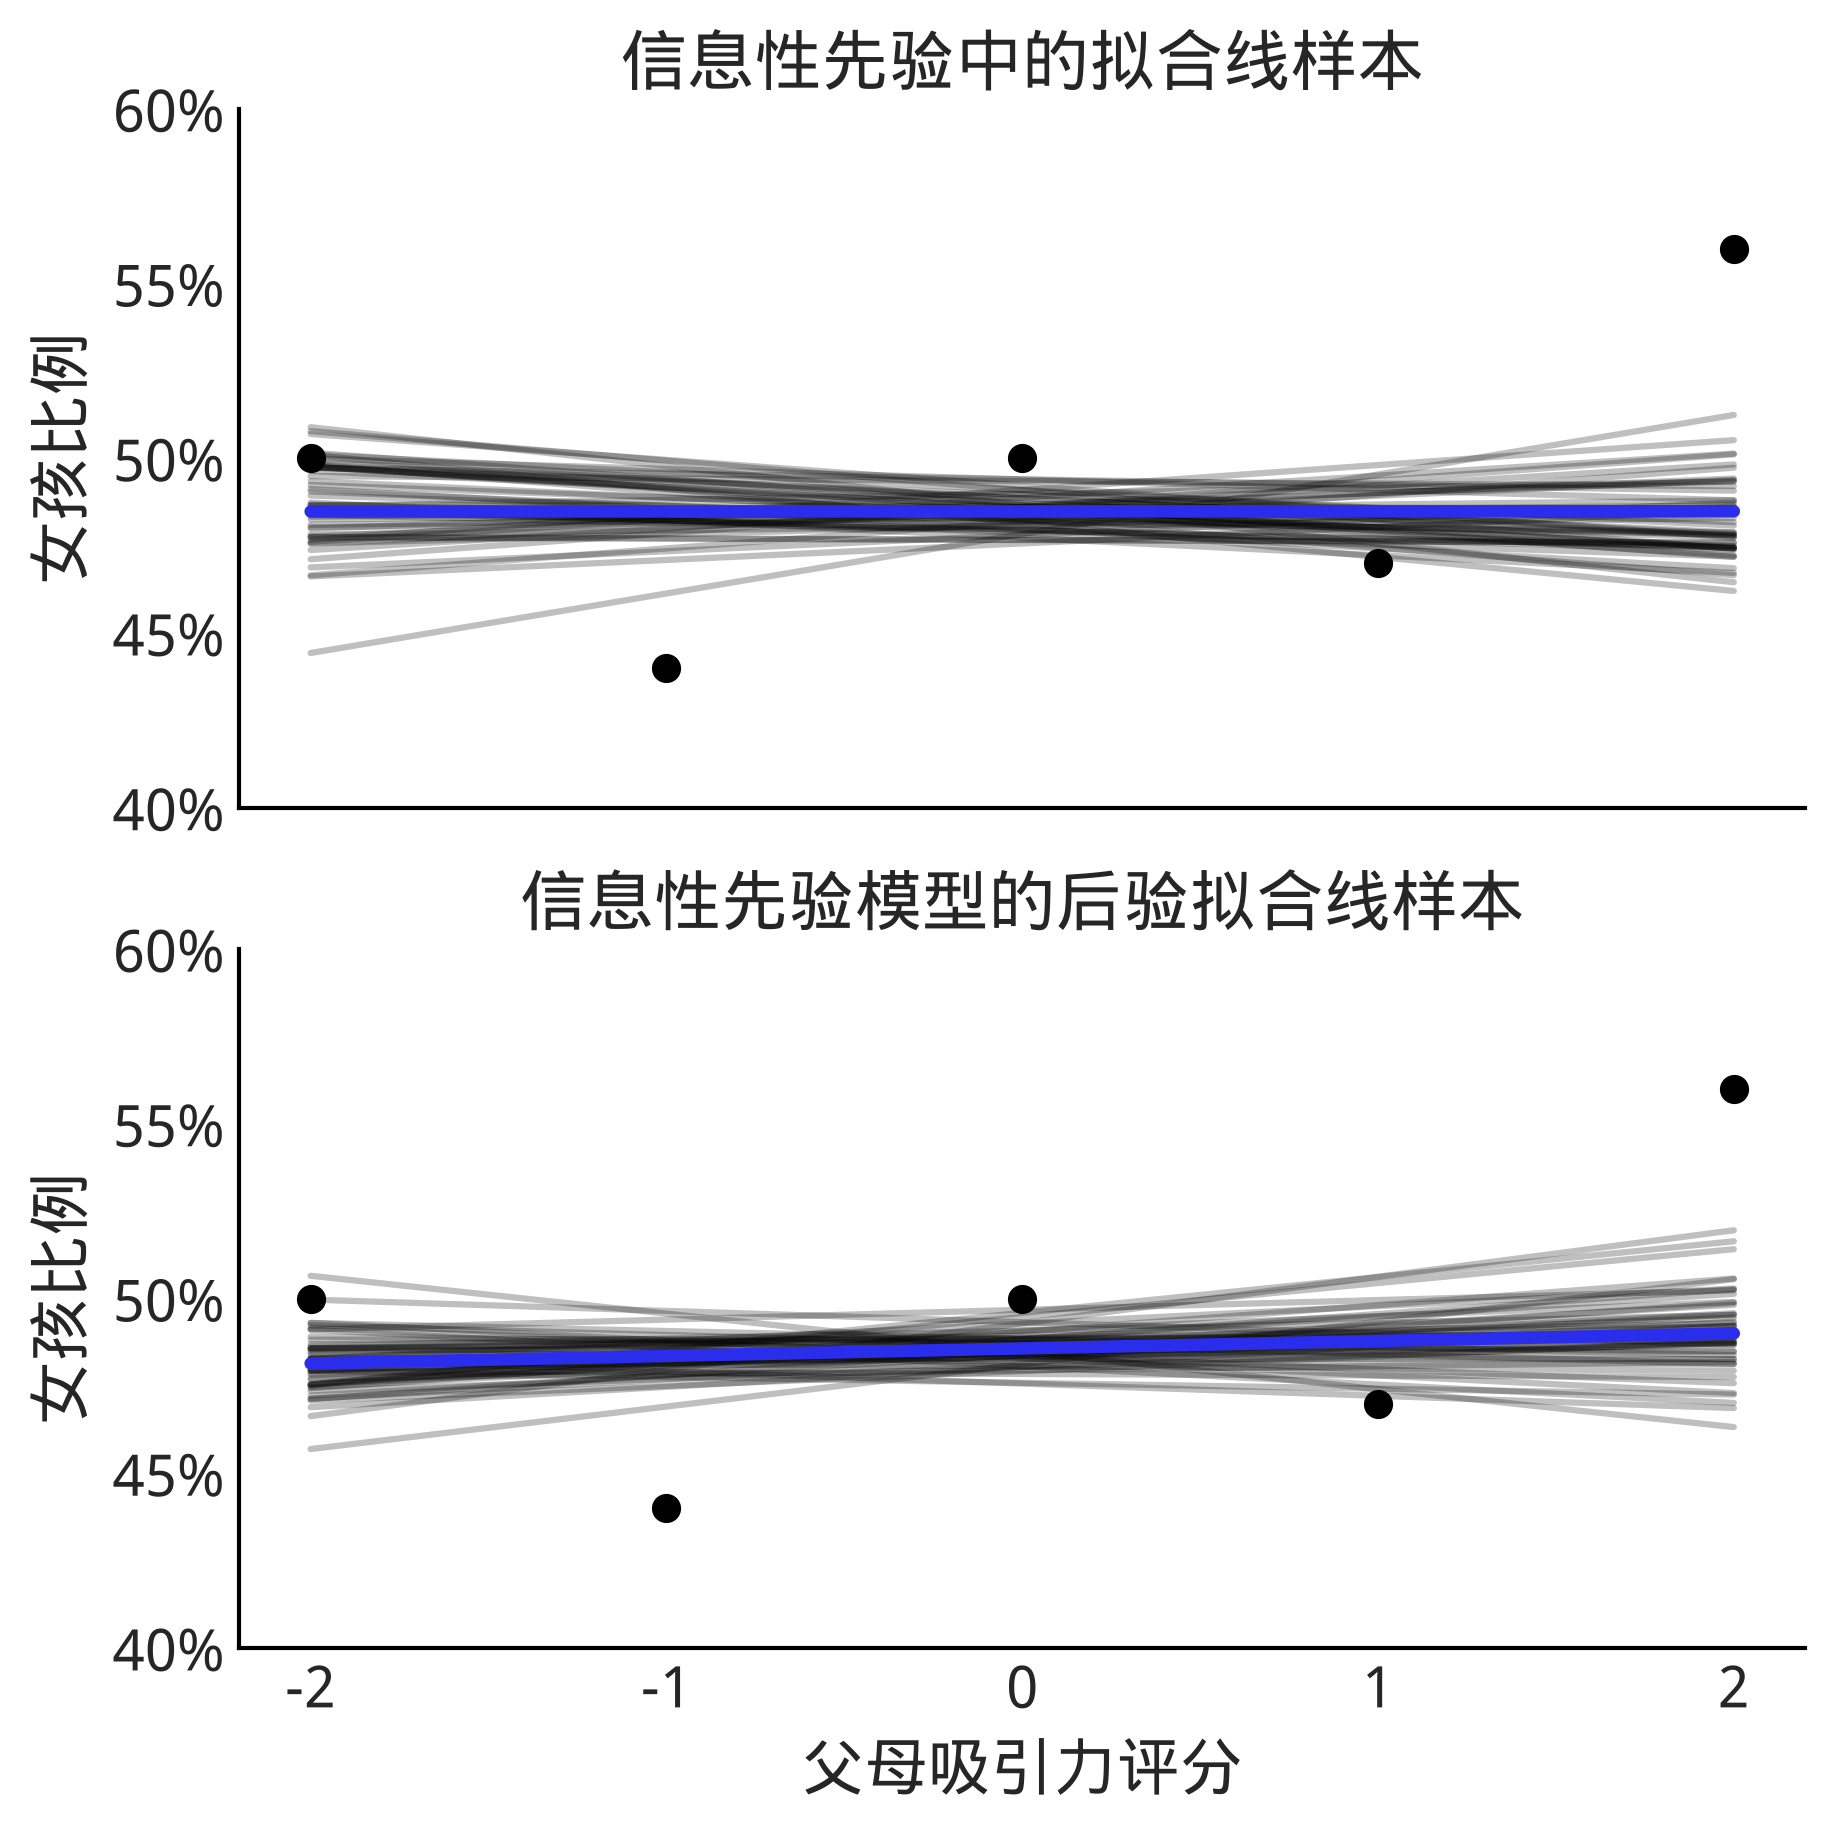

In [82]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
num_samples = 50
prior_subset = az.extract(
    idata_informative_prior_sex_ratio,
    group="prior",
    num_samples=num_samples,
    rng=RANDOM_SEED,
)
posterior_subset = az.extract(
    idata_informative_prior_sex_ratio,
    group="posterior",
    num_samples=num_samples,
    rng=RANDOM_SEED,
)

prior_lines = (
    prior_subset["β_0"].values[:, None]
    + prior_subset["β_1"].values[:, None] * x[None, :]
)
posterior_lines = (
    posterior_subset["β_0"].values[:, None]
    + posterior_subset["β_1"].values[:, None] * x[None, :]
)
axes[0].plot(x, prior_lines.T, c="black", alpha=0.25)
axes[1].plot(x, posterior_lines.T, c="black", alpha=0.25)

prior_b0 = idata_informative_prior_sex_ratio.prior["β_0"].mean().item()
prior_b1 = idata_informative_prior_sex_ratio.prior["β_1"].mean().item()
posterior_b0 = idata_informative_prior_sex_ratio.posterior["β_0"].mean().item()
posterior_b1 = idata_informative_prior_sex_ratio.posterior["β_1"].mean().item()
axes[0].plot(x, prior_b0 + prior_b1 * x, c="C4", linewidth=3)
axes[1].plot(x, posterior_b0 + posterior_b1 * x, c="C4", linewidth=3)

for ax in axes:
    ax.scatter(x, y)
    ax.set_xticks(x)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.set_ylim(40, 60)
    ax.set_ylabel("女孩比例")
axes[0].set_title("信息性先验中的拟合线样本")
axes[1].set_title("信息性先验模型的后验拟合线样本")
axes[1].set_xlabel("父母吸引力评分")

**图 3.25（锚点 `fig:PosteriorInformativeLinearRegression`）** 信息性先验模型的先验与后验拟合线;数据不足时,后验效应仍受到领域先验的明显约束。

这一次我们看到,吸引力对性别的估计影响变得微乎其微——数据中根本没有足够的信息来撼动后验。
正如我们在前面章节所说,先验的选择既是负担也是恩赐。不管你更倾向于哪种看法,重要的是:使用
这个统计工具时,要有一个可解释、有原则依据的选择。

## 习题

> **中文版现代化说明**: 原书习题使用 PyMC3 这一名称。中文版将其统一改为当前的 PyMC,并要求
> 使用本章展示的现代 `InferenceData`、`pm.Data` 和后验预测 API。统计任务与原题保持不变。

### E1

比较是日常生活的一部分。请选出一种你每天都会比较的事物,并回答以下问题:

- 你用什么数值量来进行比较?
- 你如何决定观测值应该怎样分组?例如企鹅模型按物种或性别分组。
- 你会用什么点估计来比较这些组?

### E2

参考单物种模型 `model_adelie_penguin_mass` 及其结果 `idata_adelie_mass`,完成以下任务:

1. 使用 `az.summary(idata_adelie_mass)` 读取 $\mu$ 的蒙特卡洛标准误(MCSE Mean)。比较 MCSE 与
   3707.235、3707.2、3707 这三种报告精度,判断哪些小数位属于虚假精度。不要假定你的后验均值
   必须恰好等于这些示例数字。
2. 分别绘制不同分位数处的 ESS 和 MCSE,并描述图中结果。
3. 使用很少的抽样次数反复拟合模型,直到得到较差的 $\hat R$ 和 ESS。说明这些诊断量为什么变差。
4. 以数值形式报告 50% HDI,并用 `az.plot_posterior` 将它画出来。

### E3

请用自己的话解释回归如何用于以下三类任务:

1. 协变量效应估计;
2. 预测;
3. 反事实分析。

说明三者有什么区别,各自需要哪些步骤,以及分别适合什么场景。你可以沿用企鹅示例,也可以设计
自己的例子。

### E4

本章在鳍肢长度回归模型中用减去样本均值的方式对协变量做了中心化。重新拟合模型,但这次不要
减去均值,而要减去观测到的最小鳍肢长度。把新模型的斜率和截距后验与均值中心化模型比较:
哪些量发生了变化,哪些量保持不变?与均值中心化模型相比,参数解释发生了什么变化?

### E5

把下面两个 PyMC 基元翻译成 TensorFlow Probability(TFP)。假设 PyMC 模型名为 `pymc_model`。

1. `pm.StudentT("x", nu=20, mu=0, sigma=10)`;
2. `pm.sample(chains=2)`。

提示:先用 PyMC 写出完整模型与推断过程,再参考本章代码,在 TFP 中寻找对应的分布和采样器。

### E6

PyMC 与 TFP 对同一分布有时采用不同的参数名。例如,PyMC 的均匀分布写作
`pm.Uniform.dist(lower=..., upper=...)`,而 TFP 写作 `tfd.Uniform(low=..., high=...)`。
查阅当前在线文档,列出下面各分布在两套库中的参数名及其含义,并特别留意参数化是否完全相同:

1. Normal;
2. Poisson;
3. Beta;
4. Binomial;
5. Gumbel。

### E7

贝叶斯多元回归中常见的一种参数化方法是:给截距较宽的先验,给斜率系数更有信息量的先验。
本章的 `model_logistic_penguins_bill_length_mass` 已使用标准化预测变量与适度正则化先验。请先
故意构造一个“原始量纲 + 极宽独立先验”的对照版本,再与正文版本重新拟合比较。标准化与收缩后
推断是否改善?请用发散数、$\hat R$、ESS 和轨迹图支持判断。

### E8

线性回归模型包含两个部分:均值的线性函数和噪声项。参考本章公式,用数学符号分别写出这两个
部分,再用自己的话解释它们各自的作用。特别说明:当数据生成过程或数据收集过程的任何环节含有
随机噪声时,为什么同时保留这两部分很有用?

### E9

令连续协变量 `x = np.linspace(-10, 20, 100)`,并按照
$y = 10 + 2x + \mathcal{N}(0, 5)$ 模拟数据。拟合形如
$b_0 + b_1 X + \sigma$ 的线性模型:似然以及回归系数先验使用正态分布,噪声项使用半 Student-t
先验。检查模型能否恢复生成数据时使用的参数,并同时用后验图和森林图验证结果。

### E10

为本章非中心化鳍肢长度回归模型生成完整诊断,验证正文中的结果是否可信。至少结合一种数值诊断
和一种可视化诊断,并解释它们分别检查了什么问题。

### E11

分别用 Gentoo 和 Chinstrap 企鹅重新拟合非中心化鳍肢长度回归模型。比较两个物种的后验,
并把它们与 Adelie 的后验估计比较。关于其他物种中鳍肢长度与体重的关系,你能得出什么推断?
$\sigma$ 的变化说明鳍肢长度估计体重的能力发生了怎样的变化?

### M12

使用本章 TFP 鳍肢长度、喙长和性别反事实模型,对雌性企鹅进行反事实分析:把鳍肢长度固定为
样本均值,把喙长固定为 20 mm。绘制后验预测样本的核密度估计图。

### M13

在非中心化鳍肢长度回归模型中复制鳍肢长度协变量:新增一个系数 $\beta_2$,让它与
$\beta_1$ 乘以完全相同的协变量,然后重新拟合。ESS 与 $\hat R$ 等诊断量如何评价这个包含重复
系数的模型?结合参数可辨识性解释结果。

### M14

把本章的 PyMC 非中心化鳍肢长度回归模型翻译成 TensorFlow Probability。列出至少三处语法或
建模接口上的差异。

### M15

把本章 TFP 的中心化企鹅预测变量模型翻译成 PyMC。列出至少三处语法或建模接口上的差异。

### M16

用下面的自包含步骤研究逻辑回归维度与先验预测之间的关系:

1. 用 `rng = np.random.default_rng(42)` 生成 $n=200$ 行标准正态协变量,并分别取
   $p\in\{1,5,20,100\}$ 列;每个 $p$ 都重新生成形状为 `(n, p)` 的 $X$。
2. 不需要生成或拟合响应变量。对每个 $p$,先令截距和各斜率独立服从
   $\mathcal N(0, 1)$,抽取至少 2000 组先验系数,计算
   $\eta=\beta_0+X\boldsymbol\beta$ 与 $\operatorname{logistic}(\eta)$。
3. 比较各 $p$ 下概率落在 $[0,0.01]\cup[0.99,1]$ 的比例,并画出先验预测概率分布。
4. 再把斜率先验标准差改为 $1/\sqrt{p}$,重复步骤 2–3。解释为什么独立斜率贡献的方差会随
   $p$ 累积,以及缩放后为何能缓解接近 0 或 1 的极端先验预测。

### H17

把 PyMC 的 `model_logistic_penguins_bill_length_mass` 翻译成 TFP,先用于区分 Adelie 与
Chinstrap 企鹅,再复用同一模型区分 Chinstrap 与 Gentoo 企鹅。比较两次拟合得到的系数:
它们有哪些差异?这些差异与两个分类任务中物种分离程度有何关系?

### H18

企鹅体重模型允许生成负体重。修改似然或参数化,使体重不可能为负。先运行先验预测检验确认修改
有效,再进行 MCMC 采样并绘制后验。后验与原模型相比是否发生明显变化?结合先验预测合理性、
计算便利性和后验结果,说明你会选择哪一个模型以及理由。

### H19

Palmer Penguins 数据集还包含岛屿、喙深等观测变量。分两步把它们加入 Adelie 企鹅的线性
回归模型:先加入喙深,再加入岛屿协变量。这些变量是否使体重估计更精确?请结合参数后验和模型
比较工具论证答案,并说明类别变量的编码方式。

### H20

与 H19 类似,考察在企鹅逻辑回归中加入喙深或岛屿协变量,是否能更准确地区分 Adelie 与 Gentoo
企鹅。使用本章介绍的数值和可视化工具判断额外协变量是否有帮助,并讨论样本内拟合改善与真正预测
能力之间的区别。

## 脚注

[^1]: 更多信息可参阅 TensorFlow 官方教程与文档,例如
    <https://www.tensorflow.org/probability/examples/JointDistributionAutoBatched_A_Gentle_Tutorial>
    与
    <https://www.tensorflow.org/probability/examples/Modeling_with_JointDistribution>。

[^2]: `tfd.Sample` 和 `tfd.Independent` 都是"元分布构造器"——以其他分布为输入、返回一个新
    分布。TFP 中还有其他用途不同的元分布,比如 `tfd.Mixture`、`tfd.TransformedDistribution`
    和 `tfd.JointDistribution`。更全面的 `tfp.distributions` 介绍见
    <https://www.tensorflow.org/probability/examples/TensorFlow_Distributions_Tutorial>。

[^3]: 参见 <https://mc-stan.org/docs/2_23/reference-manual/hmc-algorithm-parameters.html#automatic-parameter-tuning>。

[^4]: 如果想要和原模型完全一致,也可以在 Bambi 里显式指定先验(本文未展示)。但就我们的目的
    而言,这里两个模型已经"足够接近"。

[^5]: 也可以用不同方式解析设计矩阵,让某一列代表两个类别之间的对比。

[^6]: 也许是因为收集更多数据代价高昂、困难重重,甚至根本不可能。

[^7]: 除非是像热带雨林这样的大型系统,植物的存在确实会对气候产生影响——大自然有时候确实很难
    用简单的陈述说清楚。

[^8]: 传统上人们把 $\phi$ 这样的函数应用在等式左边,称之为连接函数(link function)。我们
    则倾向于把它应用在等式右边,为了避免混淆,称之为反连接函数。

[^9]: 传统的广义线性模型文献通常要求观测值的似然属于指数族分布,但贝叶斯方法并不受此限制,
    只要似然能用期望值参数化,原则上都可以使用。

[^10]: 这里的"每单位"指的是吸引力评分每变化一档。